# Antarctic SMB Reconstruction — RACMO2.4p1 (ANT11), EnSRF with ensemble uncertainty

**SMB-only** reconstruction (temperature removed). The EnSRF posterior ensemble spread is
propagated into every product: per-cell 1σ fields, regional series with error bars, 10-yr
rolling means with bands, and sea-level mitigation with a two-component uncertainty
(ensemble spread + 19th-century baseline sampling error).

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression

## 1. Paths

In [36]:
data_dir = os.path.expanduser("~/DataFiles")

# New RACMO2.4p1 ANT11 files (1979-2025)
racmo_smb_file = data_dir + "/smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_t2m_file = data_dir + "/tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"

# IMBIE basin mask (ANT27 grid) + an ANT27 RACMO file as its grid reference
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"
ant11_mask_file = data_dir + "/ANT11_masks.nc"     # native ANT11 geometry (van Dalum 2025)
ant27_ref_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"

# Ice-core proxies
accum_data_file   = data_dir + "/AccumCoresData.csv"
water_data_file   = data_dir + "/WaterCoresData.csv"
accum_coords_file = data_dir + "/AccumCoresCoords.csv"
water_coords_file = data_dir + "/WaterCoresCoords.csv"

## 2. Load RACMO ANT11 priors (annual)

In [37]:
# Annual SMB (kg m-2 yr-1): sum monthly smbgl per year
smb_ds = xr.open_dataset(racmo_smb_file)
smb_ann = (smb_ds["smbgl"].squeeze("height")
           .groupby("time.year").sum("time").sel(year=slice(1979, 2025)))

# Annual 2-m/near-surface temperature (K): mean of monthly tas per year
t2m_ds = xr.open_dataset(racmo_t2m_file)
t2m_ann = (t2m_ds["tas"].squeeze("height")
           .groupby("time.year").mean("time").sel(year=slice(1979, 2025)))

lat_racmo = smb_ann["lat"].values      # (591, 726)
lon_racmo = smb_ann["lon"].values
NY, NX = lat_racmo.shape
years_obs = smb_ann["year"].values     # 1979-2025
print("ANT11 grid:", (NY, NX), " SMB", smb_ann.shape, " T2m", t2m_ann.shape,
      " years", int(years_obs.min()), "-", int(years_obs.max()))

ANT11 grid: (591, 726)  SMB (47, 591, 726)  T2m (47, 591, 726)  years 1979 - 2025


## 3. Native ANT11 cell area & grounded-ice mask (regional grouping from ANT27 IMBIE)

In [38]:
# --- Native ANT11 geometry: cell area + grounded-ice mask (van Dalum et al. 2025) ---
mask_ds = xr.open_dataset(ant11_mask_file)
cell_area_m2 = mask_ds["Area"].values * 1e6            # native cell area (km2 -> m2)
ice_sheet    = mask_ds["Icesheet_Only"].values == 1     # grounded ice sheet

def to_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

# Regional (WAIS/EAIS/AP) grouping: assign each native grounded cell to the nearest
# ANT27 IMBIE *grounded* basin, so the split matches the original notebook's definitions
# while ice extent and cell area stay native ANT11.
ref27 = xr.open_dataset(ant27_ref_file)["smb"].squeeze("height")
lat27, lon27 = ref27["lat"].values, ref27["lon"].values
gi = xr.open_dataset(racmo_mask_file)["GroundedIce"].values
gi = np.where(np.isfinite(gi), gi, 0).astype(int)
_gm = gi > 0
_, _idx = cKDTree(to_xyz(lat27[_gm].ravel(), lon27[_gm].ravel())).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
basin_mask = np.where(ice_sheet.ravel(), gi[_gm].ravel()[_idx], 0).reshape(NY, NX)

basin_flat  = basin_mask.reshape(-1)
valid_cells = basin_flat > 0
basin_ids   = basin_flat[valid_cells].astype(int)
basin_ids_unique = np.unique(basin_ids)

ais_mask  = basin_mask > 0
wais_mask = np.isin(basin_mask, [3, 7, 8, 9, 10])
eais_mask = np.isin(basin_mask, [1, 2, 11, 12, 13, 14, 15, 16, 17, 18])
ap_mask   = np.isin(basin_mask, [4, 5, 6])
masks = {"AIS": ais_mask, "WAIS": wais_mask, "EAIS": eais_mask, "AP": ap_mask}

print("Grounded area: %.2f Mkm2   grounded cells: %d" % ((cell_area_m2*ais_mask).sum()/1e12, int(valid_cells.sum())))

Grounded area: 13.84 Mkm2   grounded cells: 113482


In [39]:
def basin_sums_Gt(field3d, years):
    """Sum a (nyears, NY, NX) field over IMBIE basins -> DataFrame (Gt yr-1)."""
    mass = field3d * cell_area_m2
    df = pd.DataFrame(index=list(np.asarray(years)), columns=basin_ids_unique, dtype=float)
    for t, yr in enumerate(np.asarray(years)):
        flat = mass[t].reshape(-1)[valid_cells]
        s = pd.DataFrame({"basin": basin_ids, "m": flat}).groupby("basin")["m"].sum() / 1e12
        df.loc[yr, s.index] = s.values
    return df

def weighted_avg_series(cube3d, mask2d, weights2d=cell_area_m2):
    """Area-weighted, NaN-safe spatial mean over a region, per time step."""
    out = np.full(cube3d.shape[0], np.nan)
    w_all = weights2d[mask2d]
    for i in range(cube3d.shape[0]):
        layer = cube3d[i][mask2d]; v = np.isfinite(layer)
        if v.any():
            out[i] = np.average(layer[v], weights=w_all[v])
    return out

def basin_mean_series(field3d, years, mask2d):
    """Area-weighted basin-mean series as a year-indexed pandas Series."""
    return pd.Series(weighted_avg_series(field3d, mask2d), index=np.asarray(years))

## 4. Observed RACMO basin series (1979–2025)

In [40]:
# SMB basin totals (Gt/yr), year-indexed
smb_basin_obs = basin_sums_Gt(smb_ann.values, years_obs)
ais_rac  = smb_basin_obs.sum(axis=1).astype(float)
wais_rac = smb_basin_obs[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_obs[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_obs[[4,5,6]].sum(axis=1).astype(float)
print("RACMO AIS SMB 1979-2020 mean: %.0f Gt/yr" % ais_rac.loc[1979:2020].mean())

RACMO AIS SMB 1979-2020 mean: 2536 Gt/yr


## 5. Ice-core proxies

In [41]:
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)

def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    m = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][m].to_numpy()[::-1].astype(float)   # oldest first
    return arr.T if transpose else arr

N_CAL = 42
CAL_YEARS = slice(1979, 2020)          # ice-core / RACMO overlap
recon_years = np.arange(1801, 2001)    # reconstruction period

accum_cores_cal  = extract_cores(accum_data_raw, 1979, 2020)                 # (84, 42)
water_cores_cal  = extract_cores(water_data_raw, 1979, 2020)                 # (80, 42)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False) # (200, 84)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False) # (200, 80)

accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)
core_lats  = accum_coords.iloc[:, 2].values
core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360
water_lats = water_coords.iloc[:, 2].values
water_lons = (water_coords.iloc[:, 3].values + 360) % 360
print("accum cores:", accum_cores_full.shape[1], " water cores:", water_cores_full.shape[1])

accum cores: 84  water cores: 80


## 6. Proxy system models (PSMs) & observation error

- **Accumulation cores** → bias-corrected model SMB at the site (`y_e_accum`).
- **Water-isotope cores** → linear isotope PSM δ = a·T + b from model T2m (`y_e_water`).

`R` for each proxy is the residual variance of its calibration regression. These are
combined two ways: for the SMB state (accum + water) and the T2m state (water + accum).

In [42]:
def nearest_ij(lat2d, lon2d, tlat, tlon):
    lon360 = (lon2d + 360) % 360
    d2 = (lat2d - tlat)**2 + (lon360 - (tlon + 360) % 360)**2
    return np.unravel_index(np.argmin(d2), d2.shape)

smb_cal = smb_ann.sel(year=CAL_YEARS).values     # (42, NY, NX)
t2m_cal = t2m_ann.sel(year=CAL_YEARS).values     # needed only for the water-isotope PSM

# --- Accumulation-core PSM: bias-corrected model SMB ---
accum_pts = np.zeros((84, N_CAL)); R_accum = np.zeros(84)
for i in range(84):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]; obs = accum_cores_cal[i, :]
    accum_pts[i, :] = smb_pt
    v = np.isfinite(obs) & np.isfinite(smb_pt)
    reg = LinearRegression().fit(smb_pt[v].reshape(-1, 1), obs[v].reshape(-1, 1))
    R_accum[i] = np.var(obs[v].reshape(-1, 1) - reg.predict(smb_pt[v].reshape(-1, 1)), ddof=1)
_valid = np.isfinite(accum_cores_cal) & np.isfinite(accum_pts)
_off = (np.nanmean(np.where(_valid, accum_cores_cal, np.nan), axis=1)
        - np.nanmean(np.where(_valid, accum_pts, np.nan), axis=1))
y_e_accum = accum_pts + _off[:, None]            # (84, 42)

# --- Water-isotope-core PSM: delta = a*T + b (constrains SMB via T2m-SMB ensemble covariance) ---
y_e_water = np.zeros((80, N_CAL)); R_water = np.zeros(80)
for i in range(80):
    j, k = nearest_ij(lat_racmo, lon_racmo, water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]; obs = water_cores_cal[i, :]
    v = np.isfinite(obs) & np.isfinite(t_pt)
    reg = LinearRegression().fit(t_pt[v].reshape(-1, 1), obs[v].reshape(-1, 1))
    y_e_water[i, :] = t_pt * reg.coef_[0][0] + reg.intercept_[0]
    R_water[i] = np.var(obs[v].reshape(-1, 1) - reg.predict(t_pt[v].reshape(-1, 1)), ddof=1)

# --- SMB proxy set: accum (0-83) then water (84-163) ---
y_e_smb    = np.vstack([y_e_accum, y_e_water])
R_smb_diag = np.concatenate([R_accum, R_water])
proxy_smb  = np.hstack([accum_cores_full, water_cores_full])     # (200, 164)
print("PSMs ready. y_e_smb", y_e_smb.shape)

PSMs ready. y_e_smb (164, 42)


## 7. Spatial EnSRF

In [43]:
def run_ensrf_spatial(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy):
    """EnSRF over 200 years assimilating n_proxy sequential obs/year (mean + per-cell std)."""
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), dtype=np.float32); post_std = np.zeros((200, Ns), dtype=np.float32)
    for i in range(200):
        X_mean = prior_cells.mean(axis=0); X_dev = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]): continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0: continue
            y_dev = y_e[j, :] - y_mean
            K = ((X_dev.T @ y_dev) / (N_CAL - 1)) / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i, :] = X_mean; post_std[i, :] = X_dev.std(axis=0, ddof=1)
    return post_mean, post_std

def run_ensrf_spatial_unc(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy, integ):
    """As run_ensrf_spatial, plus the full posterior ENSEMBLE of integrated (region) quantities.
    integ: (n_reg, Ns) integration rows — cell area (Gt) for a sum, or area/area_sum for a
    weighted mean. Returns post_mean, post_std, reg_ens (200, N_CAL, n_reg)."""
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), np.float32); post_std = np.zeros((200, Ns), np.float32)
    reg_ens = np.zeros((200, N_CAL, integ.shape[0]))
    for i in range(200):
        X_mean = prior_cells.mean(axis=0); X_dev = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]): continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0: continue
            y_dev = y_e[j, :] - y_mean
            K = ((X_dev.T @ y_dev) / (N_CAL - 1)) / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i] = X_mean; post_std[i] = X_dev.std(axis=0, ddof=1)
        reg_ens[i] = (integ @ (X_mean[None, :] + X_dev).T).T    # (N_CAL, n_reg): ensemble of integrals
    return post_mean, post_std, reg_ens

## 8. Reconstructions (RACMO prior)

Both use all 164 proxies (84 accumulation + 80 water isotope). Note: on the ANT11 grid the
state vector is ~429k cells, so each run is heavier than ANT27 — expect a few minutes.

In [44]:
# --- SMB reconstruction with uncertainty (grounded cells only) ---
# Regional integration matrices over the grounded state (SMB: area-weighted SUM -> Gt/yr)
_va = cell_area_m2.reshape(-1)[valid_cells]                      # m^2 per grounded cell
_regions = {"AIS": basin_ids > 0, "WAIS": np.isin(basin_ids, [3,7,8,9,10]),
            "EAIS": np.isin(basin_ids, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(basin_ids, [4,5,6])}
region_names = ["AIS", "WAIS", "EAIS", "AP"]
A_smb = np.vstack([np.where(_regions[r], _va, 0) / 1e12 for r in region_names])   # sum -> Gt/yr

smb_cells = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running SMB EnSRF with uncertainty (%d grounded cells) ..." % smb_cells.shape[1])
smb_post_v, smb_std_v, smb_reg_ens = run_ensrf_spatial_unc(smb_cells, y_e_smb, R_smb_diag, proxy_smb, 164, A_smb)
racmo_smb_recon     = np.full((200, NY*NX), np.nan, np.float32); racmo_smb_recon[:, valid_cells]     = smb_post_v
racmo_smb_recon_std = np.full((200, NY*NX), np.nan, np.float32); racmo_smb_recon_std[:, valid_cells] = smb_std_v
racmo_smb_recon     = racmo_smb_recon.reshape(200, NY, NX)
racmo_smb_recon_std = racmo_smb_recon_std.reshape(200, NY, NX)
print("SMB done. AIS 1-sigma (time-mean): %.1f Gt/yr" % smb_reg_ens[:, :, 0].std(axis=1, ddof=1).mean())

Running SMB EnSRF with uncertainty (113482 grounded cells) ...
SMB done. AIS 1-sigma (time-mean): 63.3 Gt/yr


## 9. Basin-mean reconstruction series

In [45]:
# Regional SMB series: posterior mean and 1-sigma from the integrated ensemble
smb_reg_mean = smb_reg_ens.mean(axis=1); smb_reg_std = smb_reg_ens.std(axis=1, ddof=1)   # (200, 4)
ais_rac_recon, wais_rac_recon, eais_rac_recon, ap_rac_recon = (smb_reg_mean[:, k] for k in range(4))
ais_rac_std,  wais_rac_std,  eais_rac_std,  ap_rac_std  = (smb_reg_std[:, k]  for k in range(4))
smb_std_by_region = {"AIS": ais_rac_std, "WAIS": wais_rac_std, "EAIS": eais_rac_std, "AP": ap_rac_std}
smb_basin_recon = basin_sums_Gt(racmo_smb_recon, recon_years)     # per-basin mean field (for maps)
print("Basin series ready. AIS SMB %.0f +/- %.0f Gt/yr" % (ais_rac_recon.mean(), ais_rac_std.mean()))

Basin series ready. AIS SMB 2378 +/- 63 Gt/yr


### 9b. Reconstruction uncertainty (posterior ensemble spread)

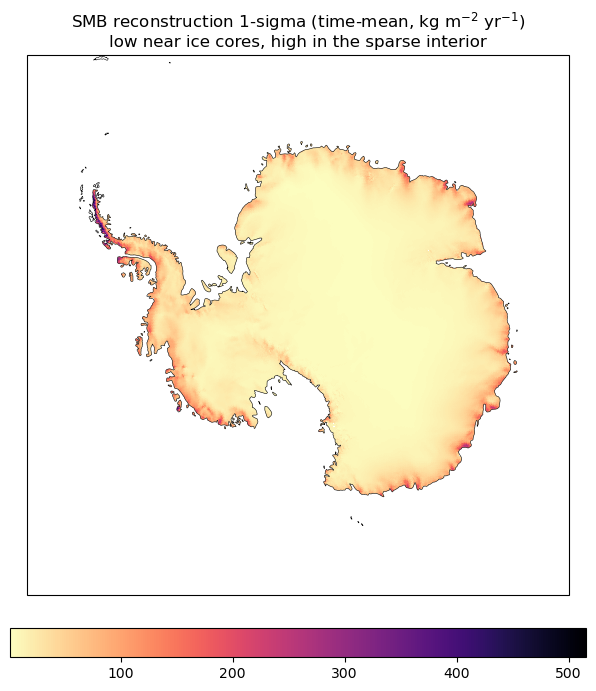

In [46]:
# --- SMB reconstruction uncertainty map (posterior 1-sigma, time-mean) ---
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
im = ax.pcolormesh(lon_racmo, lat_racmo, racmo_smb_recon_std.mean(0), transform=ccrs.PlateCarree(),
                   cmap="magma_r", zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
ax.set_title("SMB reconstruction 1-sigma (time-mean, kg m$^{-2}$ yr$^{-1}$)\nlow near ice cores, high in the sparse interior")
fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8); plt.tight_layout(); plt.show()

## 10. Trend maps

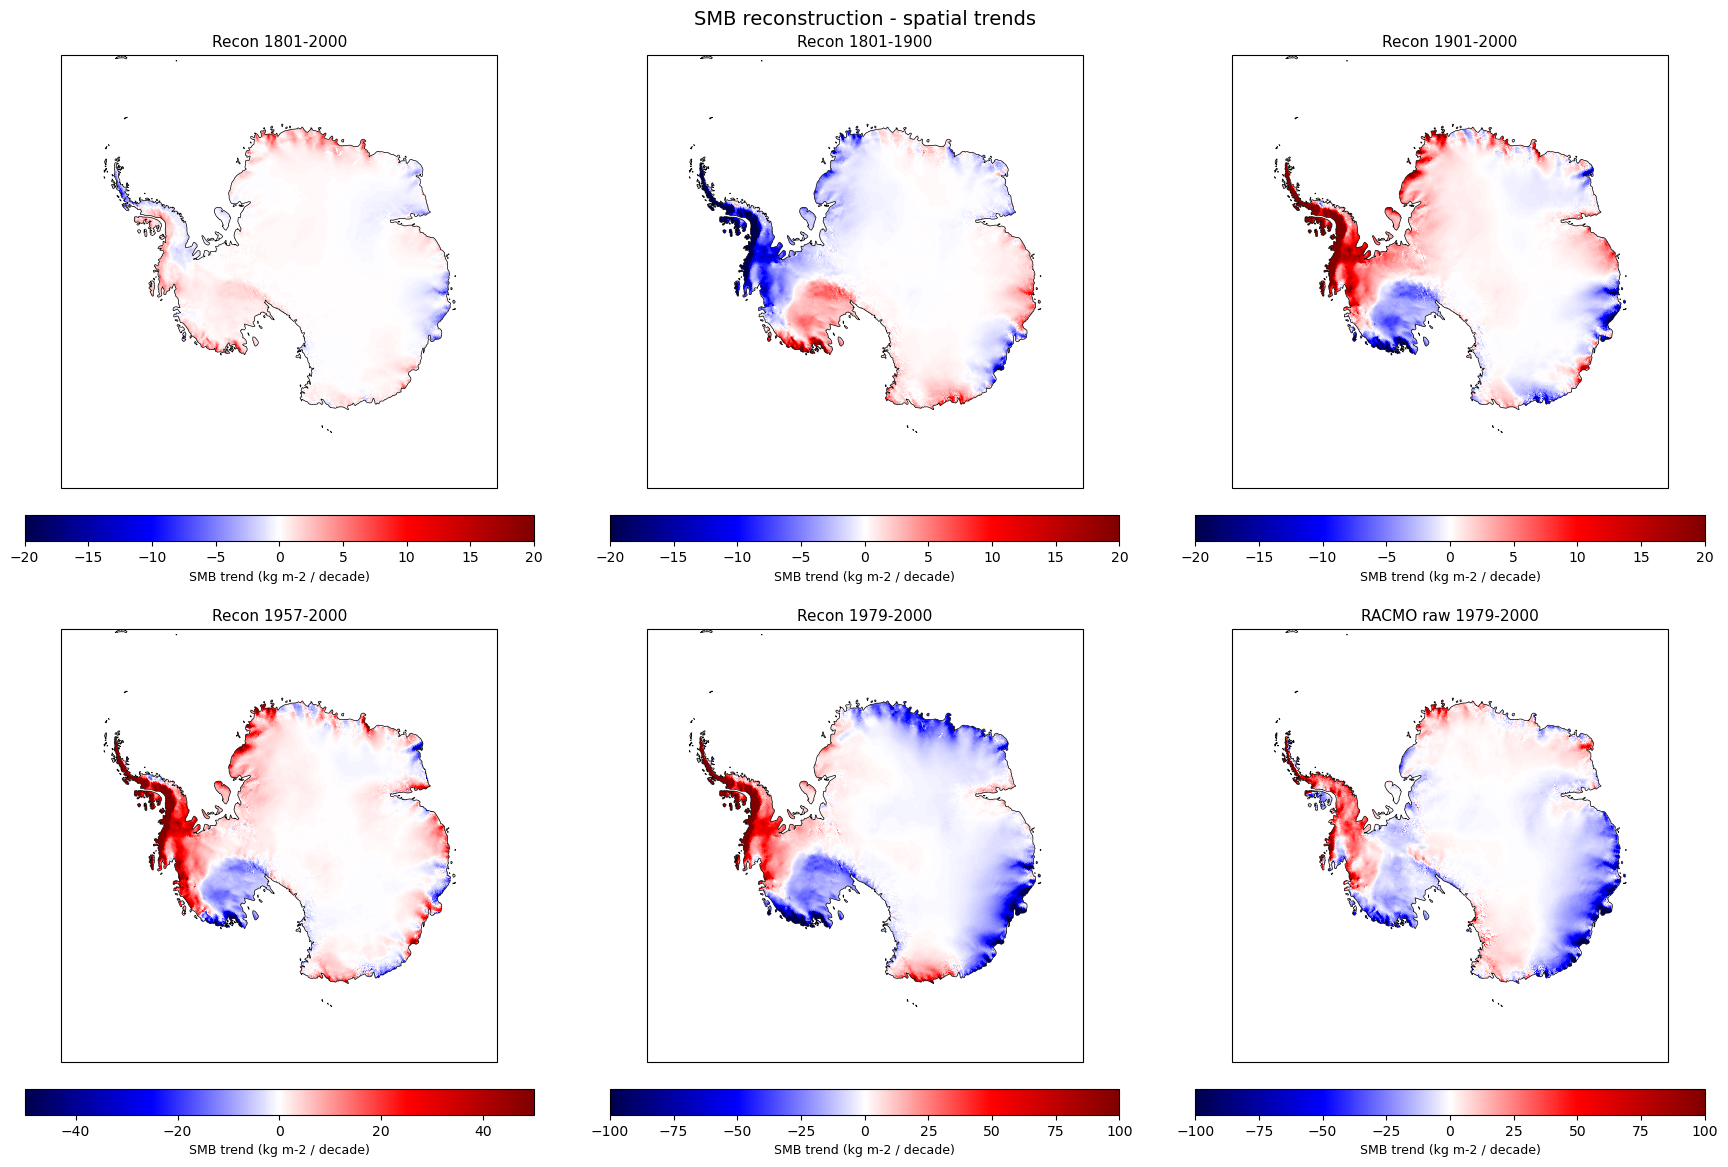

In [47]:
def spatial_trend(cube_3d, yr_start, yr_end, yr_offset=1801):
    i0, i1 = yr_start - yr_offset, yr_end - yr_offset
    sub = cube_3d[i0:i1 + 1]
    t = np.arange(sub.shape[0], dtype=float)
    X = np.vstack([t, np.ones_like(t)]).T
    beta, _, _, _ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return (beta[0].reshape(sub.shape[1], sub.shape[2]) * 10)   # per decade

def polar_map(data_2d, title, cbar_label, vmin, vmax, cmap="RdBu_r"):
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, data_2d, transform=ccrs.PlateCarree(),
                       vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8).set_label(cbar_label)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=10); plt.tight_layout(); plt.show()

def six_panel(recon_cube, raw_da, cbar_label, cmap, vmaxes, suptitle):
    periods = [("Recon 1801-2000", recon_cube, 1801, 2000, vmaxes[0], 1801),
               ("Recon 1801-1900", recon_cube, 1801, 1900, vmaxes[1], 1801),
               ("Recon 1901-2000", recon_cube, 1901, 2000, vmaxes[2], 1801),
               ("Recon 1957-2000", recon_cube, 1957, 2000, vmaxes[3], 1801),
               ("Recon 1979-2000", recon_cube, 1979, 2000, vmaxes[4], 1801),
               ("RACMO raw 1979-2000", raw_da.sel(year=slice(1979, 2000)).values, 1979, 2000, vmaxes[5], 1979)]
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, (title, cube, y0, y1, vmax, off) in zip(axes.ravel(), periods):
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                           transform=ccrs.PlateCarree(), vmin=-vmax, vmax=vmax, cmap=cmap, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(title, fontsize=11, pad=6)
        plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.85).set_label(cbar_label, fontsize=9)
    fig.suptitle(suptitle, fontsize=14); fig.tight_layout(); plt.show()

six_panel(racmo_smb_recon, smb_ann, "SMB trend (kg m-2 / decade)", "seismic",
          [20, 20, 20, 50, 100, 100], "SMB reconstruction - spatial trends")


## 11. Reconstruction + observed extension to 2025

In [48]:
ext_years = np.concatenate([recon_years, np.arange(2001, 2026)])   # 1801-2025
trend_periods = [(1801, 1900, "navy", "1801-1900"), (1801, 2000, "red", "1801-2000"),
                 (1901, 2000, "orange", "1901-2000"), (1979, 2000, "purple", "1979-2000 (recon)"),
                 (1979, 2025, "brown", "1979-2025"), (2000, 2025, "black", "2000-2025")]
obs_years_1979_2000 = np.arange(1979, 2001)

def _extend(recon_ts, obs_full):
    return np.concatenate([recon_ts, np.asarray(obs_full)[22:]])

def ext_grid(pairs, std_by_region, ylabel, unit, scale, sup):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
    for ax, (region, recon_ts, obs_full) in zip(axes.ravel(), pairs):
        recon_std = std_by_region[region]
        ts = _extend(recon_ts, obs_full); weights = []
        ax.plot(recon_years, ts[:200], color="steelblue", lw=1.0, alpha=0.9,
                label=f"{region} reconstruction"); weights.append("normal")
        ax.fill_between(recon_years, ts[:200] - recon_std, ts[:200] + recon_std,
                        color="steelblue", alpha=0.2, label="reconstruction +/-1sigma"); weights.append("normal")
        ax.plot(np.arange(2001, 2026), ts[200:], color="darkorange", lw=1.5,
                label=f"{region} obs (2001-2025)"); weights.append("normal")
        ax.axvline(2000, color="gray", lw=0.8, ls=":")
        for (y1, y2, col, lbl) in trend_periods:
            idx = (ext_years >= y1) & (ext_years <= y2)
            if idx.sum() < 3: continue
            sl, ic, r, p, _ = stats.linregress(ext_years[idx].astype(float), ts[idx])
            ax.plot(ext_years[idx], sl*ext_years[idx]+ic, "--", color=col, lw=1.8, alpha=0.5,
                    label=f"{lbl}: {sl*scale:+.2f} {unit}")
            weights.append("bold" if p < 0.05 else "normal")
        obs_22 = np.asarray(obs_full)[:22]; v = np.isfinite(obs_22)
        if v.sum() > 2:
            sl, ic, r, p, _ = stats.linregress(obs_years_1979_2000[v].astype(float), obs_22[v])
            ax.plot(obs_years_1979_2000, sl*obs_years_1979_2000+ic, ":", color="purple", lw=2.0,
                    alpha=0.5, label=f"1979-2000 (raw obs): {sl*scale:+.2f} {unit}")
            weights.append("bold" if p < 0.05 else "normal")
        ax.set_title(f"{region} - RACMO prior"); ax.set_ylabel(ylabel); ax.grid(alpha=0.4)
        leg = ax.legend(fontsize=7)
        for txt, wt in zip(leg.get_texts(), weights): txt.set_fontweight(wt)
    for ax in axes[-1, :]: ax.set_xlabel("Year")
    fig.suptitle(sup, fontsize=13); fig.tight_layout(); plt.show()

smb_pairs = [("AIS", ais_rac_recon, ais_rac), ("WAIS", wais_rac_recon, wais_rac),
             ("EAIS", eais_rac_recon, eais_rac), ("AP", ap_rac_recon, ap_rac)]


### 10-year rolling means (1801–2025)

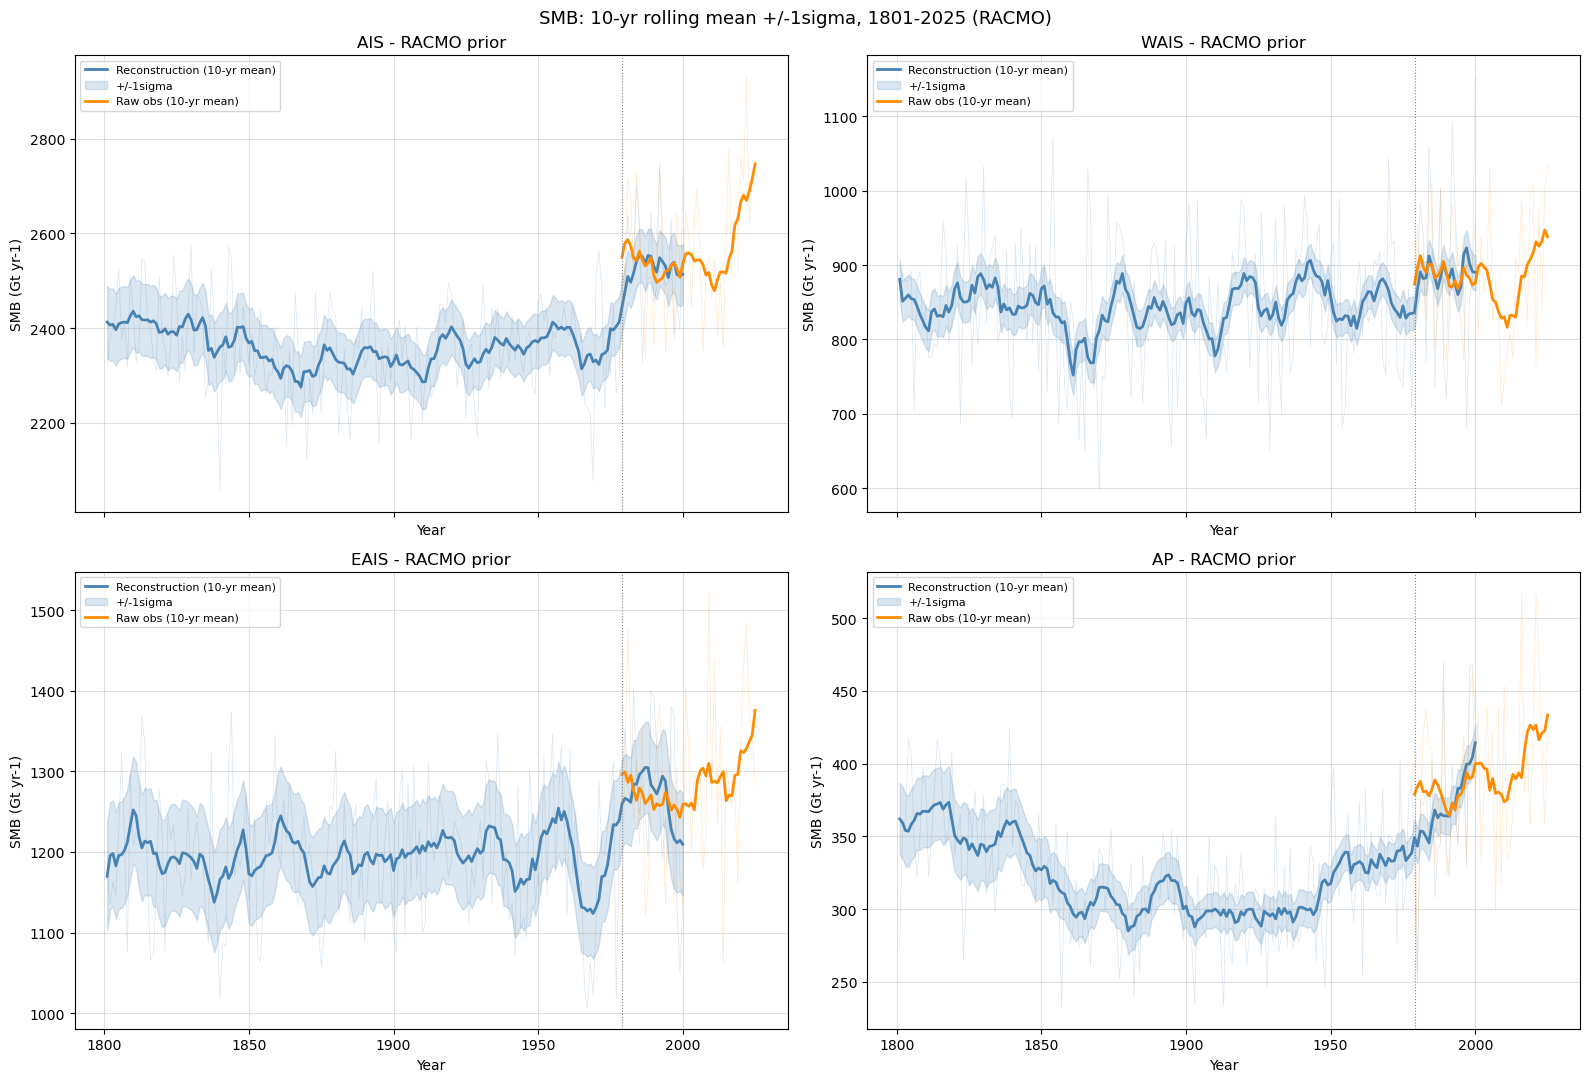

In [49]:
def rolling_mean(ts, window=10):
    return pd.Series(ts).rolling(window, center=True, min_periods=1).mean().values

obs_years_plot = np.arange(1979, 2026)
def rolling_grid(pairs, std_by_region, ylabel, sup):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
    for ax, (region, recon_ts, obs_full) in zip(axes.ravel(), pairs):
        obs_ts = np.asarray(obs_full)
        rm = rolling_mean(recon_ts); band = rolling_mean(std_by_region[region])
        ax.plot(recon_years, recon_ts, color="steelblue", lw=0.5, alpha=0.2)
        ax.plot(recon_years, rm, color="steelblue", lw=2.0, label="Reconstruction (10-yr mean)")
        ax.fill_between(recon_years, rm - band, rm + band, color="steelblue", alpha=0.2, label="+/-1sigma")
        ax.plot(obs_years_plot, obs_ts, color="darkorange", lw=0.5, alpha=0.2)
        ax.plot(obs_years_plot, rolling_mean(obs_ts), color="darkorange", lw=2.0, label="Raw obs (10-yr mean)")
        ax.axvline(1979, color="gray", lw=0.8, ls=":")
        ax.set_title(f"{region} - RACMO prior"); ax.set_ylabel(ylabel); ax.set_xlabel("Year")
        ax.legend(fontsize=8); ax.grid(alpha=0.4)
    fig.suptitle(sup, fontsize=13); fig.tight_layout(); plt.show()

rolling_grid(smb_pairs, smb_std_by_region, "SMB (Gt yr-1)",
             "SMB: 10-yr rolling mean +/-1sigma, 1801-2025 (RACMO)")

## 12. Sea-level mitigation (to 2025)

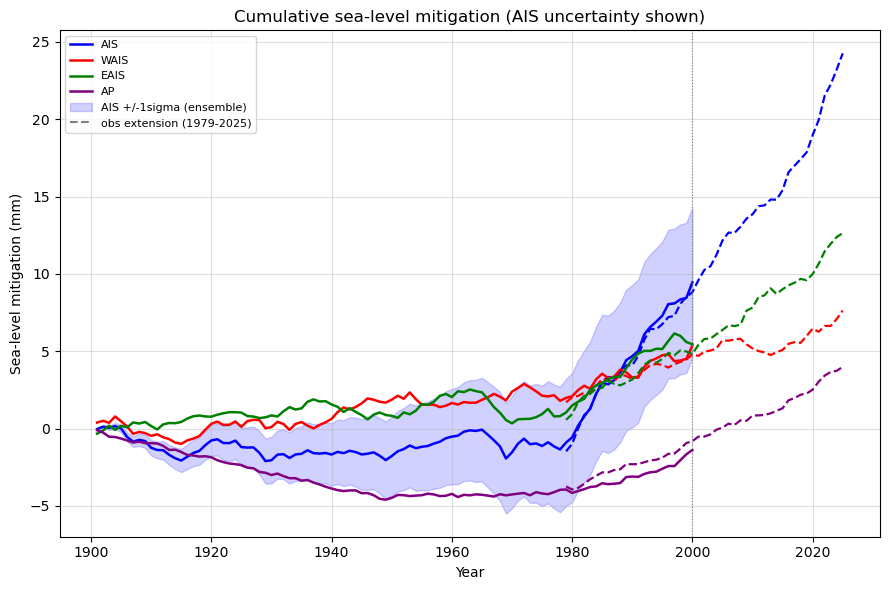

In [64]:
def sea_level_mitigation(ts, baseline=slice(0, 100)):
    return np.cumsum(ts - np.mean(ts[baseline])) / 361.8

def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    base = np.mean(recon_ts[baseline]); cum_to_1978 = np.sum(recon_ts[:178] - base) / 361.8
    return cum_to_1978 + np.cumsum((np.asarray(obs_ts) - base) / 361.8)

# --- AIS uncertainty: ensemble-propagated ONLY (per-member sample-mean baseline) ---
# Each member anomalizes vs its own 1801-1900 mean, so the baseline-mean uncertainty is already
# included AND the band correctly pinches to ~0 at the baseline period, growing away from it.
k = 0
ens = smb_reg_ens[:, :, k]                                      # (200, N_CAL)
slm_members = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])])
slm_std = slm_members.std(0, ddof=1)                           # ensemble 1-sigma (mm)
slm_ais = sea_level_mitigation(ais_rac_recon)

cent_years = np.arange(1901, 2001)
fig, ax = plt.subplots(figsize=(9, 6))
for recon_ts, obs_ts, name, col in [
        (ais_rac_recon, ais_rac, "AIS", "blue"), (wais_rac_recon, wais_rac, "WAIS", "red"),
        (eais_rac_recon, eais_rac, "EAIS", "green"), (ap_rac_recon, ap_rac, "AP", "purple")]:
    ax.plot(cent_years, sea_level_mitigation(recon_ts)[100:], color=col, lw=1.8, label=name)
    ax.plot(years_obs, extend_slm(recon_ts, obs_ts), color=col, lw=1.6, ls="--")
ax.fill_between(cent_years, (slm_ais - slm_std)[100:], (slm_ais + slm_std)[100:],
                color="blue", alpha=0.18, label="AIS +/-1sigma (ensemble)")
ax.plot([], [], color="gray", lw=1.5, ls="--", label="obs extension (1979-2025)")
ax.axvline(2000, color="gray", lw=0.8, ls=":")
ax.set_title("Cumulative sea-level mitigation (AIS uncertainty shown)")
ax.set_xlabel("Year"); ax.set_ylabel("Sea-level mitigation (mm)")
ax.legend(fontsize=8); ax.grid(alpha=0.4); plt.tight_layout(); plt.show()


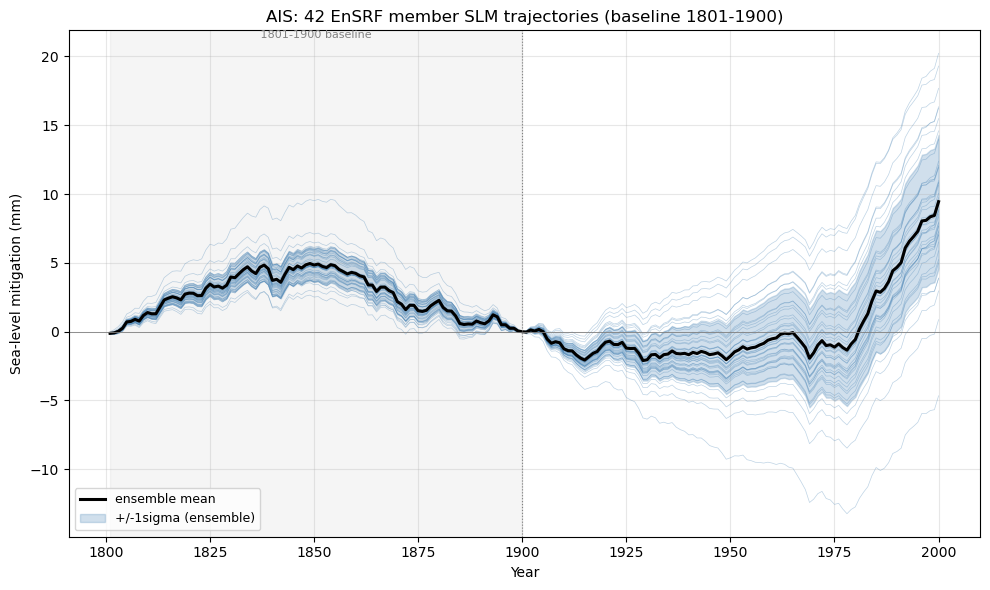

In [79]:
# --- All 42 EnSRF-member sea-level-mitigation trajectories (AIS) ---
k = 0                                              # 0=AIS, 1=WAIS, 2=EAIS, 3=AP
region = ["AIS", "WAIS", "EAIS", "AP"][k]
ens = smb_reg_ens[:, :, k]                         # (200 years, 42 members)
slm_members = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])])  # (42, 200)
slm_mean = slm_members.mean(0); slm_std = slm_members.std(0, ddof=1)

fig, ax = plt.subplots(figsize=(10, 6))
for m in range(slm_members.shape[0]):
    ax.plot(recon_years, slm_members[m], color="steelblue", lw=0.5, alpha=0.35)
ax.plot(recon_years, slm_mean, color="black", lw=2.2, label="ensemble mean")
ax.fill_between(recon_years, slm_mean - slm_std, slm_mean + slm_std,
                color="steelblue", alpha=0.25, label="+/-1sigma (ensemble)")
ax.axvspan(1801, 1900, color="gray", alpha=0.08)                       # baseline period
ax.axvline(1900, color="gray", lw=0.8, ls=":")
ax.axhline(0, color="gray", lw=0.6)
ax.text(1850, ax.get_ylim()[1], " 1801-1900 baseline", va="top", ha="center", fontsize=8, color="gray")
ax.set_xlabel("Year"); ax.set_ylabel("Sea-level mitigation (mm)")
ax.set_title(f"{region}: {slm_members.shape[0]} EnSRF member SLM trajectories (baseline 1801-1900)")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


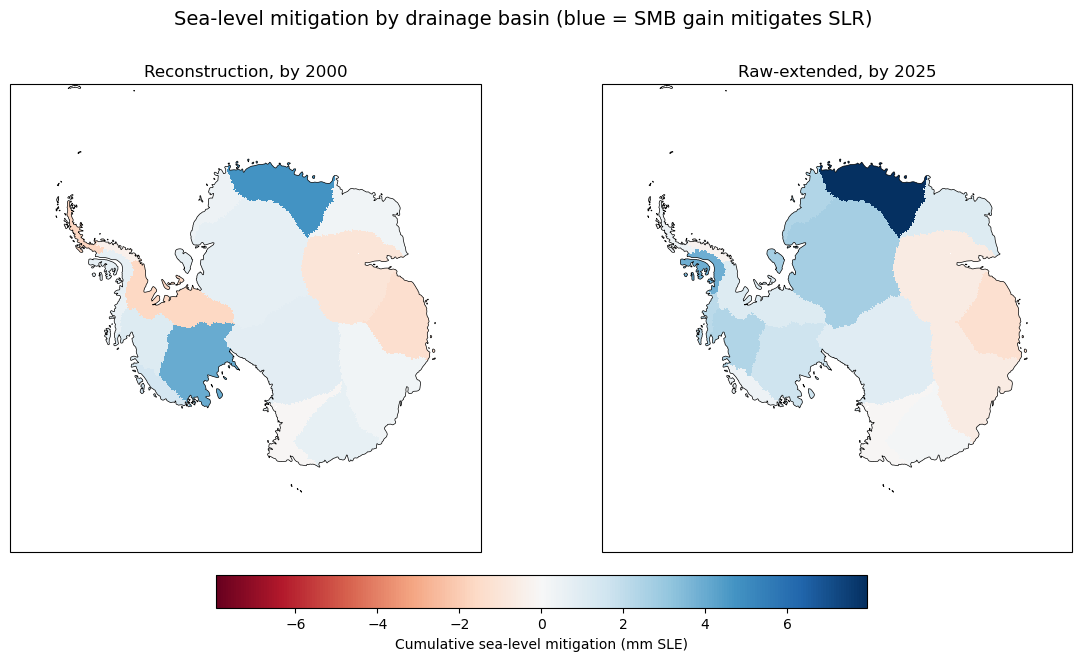

In [ ]:
# --- Sea-level mitigation by drainage basin: recon->2000 and raw-extended->2025 ---
def basin_total(field3d, years, bid):
    mk = basin_mask == bid
    return np.array([np.nansum(np.where(mk, field3d[t] * cell_area_m2, 0)) / 1e12
                     for t in range(field3d.shape[0])])

def sea_level_mitigation(ts, baseline=slice(0, 100)):
    return np.cumsum(ts - np.mean(ts[baseline])) / 361.8          # Gt anomaly -> mm SLE

def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    base = np.mean(recon_ts[baseline])
    cum_to_1978 = np.sum(recon_ts[:178] - base) / 361.8           # running total to end of 1978
    return cum_to_1978 + np.cumsum((np.asarray(obs_ts) - base) / 361.8)

slm2000, slm2025 = {}, {}
for bid in basin_ids_unique:
    rc = basin_total(racmo_smb_recon, recon_years, bid)           # 1801-2000
    ob = basin_total(smb_ann.values,  years_obs,   bid)           # 1979-2025 (raw RACMO)
    slm2000[bid] = sea_level_mitigation(rc)[-1]                   # cumulative to 2000
    slm2025[bid] = extend_slm(rc, ob)[-1]                         # cumulative to 2025

def paint(d):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in d.items():
        f[basin_mask == bid] = v
    return f

vmax = np.nanmax(np.abs(list(slm2000.values()) + list(slm2025.values())))
fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (d, title) in zip(axes, [(slm2000, "Reconstruction, by 2000"),
                                  (slm2025, "Raw-extended, by 2025")]):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(d), transform=ccrs.PlateCarree(),
                       vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.6)
cb.set_label("Cumulative sea-level mitigation (mm SLE)")
fig.suptitle("Sea-level mitigation by drainage basin (blue = SMB gain mitigates SLR)", fontsize=14)
plt.show()


## 15. Independent validation vs MERRA-2

MERRA-2 (`M2TMNXFLX`: `PRECTOT`, `TLML`) as an independent reference. Regridded onto the
ANT11 grid with scipy `RegularGridInterpolator` (bilinear; no xesmf). MERRA-2 begins 1980,
so the 1979–2000 skill window uses 1980–2000; comparisons are year-aligned.

In [52]:
import glob
from scipy.interpolate import RegularGridInterpolator

merra_dir = os.path.expanduser("~/DataFiles/M2TMNXFLX")
mfiles = sorted(f for f in glob.glob(f"{merra_dir}/*") if f.endswith((".nc4", ".dap.nc4")))
print(f"{len(mfiles)} MERRA-2 files")
merra_ds = xr.concat([xr.open_dataset(f) for f in mfiles], dim="time")

secs = merra_ds["time"].dt.days_in_month * 86400.0
merra_acc = ((merra_ds["PRECTOT"] * secs).groupby("time.year").sum("time")
             .sel(year=slice(1979, 2025)))          # kg m-2 yr-1 (precip ~ SMB)
merra_years = merra_acc["year"].values

def regrid_to_ant11(da):
    mlat = da["lat"].values; mlon = da["lon"].values; vals = da.values
    if mlat[0] > mlat[-1]: mlat = mlat[::-1]; vals = vals[:, ::-1, :]
    if mlon[0] > mlon[-1]: mlon = mlon[::-1]; vals = vals[:, :, ::-1]
    pts = np.stack([lat_racmo.ravel(), np.clip(lon_racmo.ravel(), mlon.min(), mlon.max())], -1)
    out = np.empty((vals.shape[0], NY, NX), dtype=float)
    for t in range(vals.shape[0]):
        out[t] = RegularGridInterpolator((mlat, mlon), vals[t], bounds_error=False, fill_value=np.nan)(pts).reshape(NY, NX)
    return xr.DataArray(out, dims=("year", "rlat", "rlon"), coords={"year": da["year"].values})

merra_ann = regrid_to_ant11(merra_acc)              # SMB/precip on ANT11
print("MERRA-2 on ANT11:", merra_ann.shape, "years", int(merra_years.min()), "-", int(merra_years.max()))
merra_basin = basin_sums_Gt(merra_ann.values, merra_years)
smb_merra = {"AIS":  merra_basin.sum(axis=1).astype(float),
             "WAIS": merra_basin[[3,7,8,9,10]].sum(axis=1).astype(float),
             "EAIS": merra_basin[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float),
             "AP":   merra_basin[[4,5,6]].sum(axis=1).astype(float)}

516 MERRA-2 files
MERRA-2 on ANT11: (43, 591, 726) years 1980 - 2022


### Basin skill tables — correlation & anomaly-based CE (RACMO / MERRA-2)

In [53]:
ov_years = np.arange(1979, 2001)
recon_smb = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
smb_obs = {"RACMO":  {r: pd.Series(np.array(v), index=years_obs) for r, v in
                      zip(["AIS","WAIS","EAIS","AP"], [ais_rac, wais_rac, eais_rac, ap_rac])},
           "MERRA2": smb_merra}

def _yrs(recon_full, obs):
    rs = pd.Series(recon_full, index=recon_years)
    ys = [y for y in ov_years if y in obs.index and np.isfinite(obs.loc[y]) and np.isfinite(rs.loc[y])]
    return rs, ys
def yr_corr(recon_full, obs):
    rs, ys = _yrs(recon_full, obs)
    return np.corrcoef(rs.loc[ys], obs.loc[ys])[0, 1] if len(ys) >= 3 else np.nan
def yr_ce_anom(recon_full, obs):
    rs, ys = _yrs(recon_full, obs)
    if len(ys) < 3: return np.nan
    o = obs.loc[ys].values; p = rs.loc[ys].values
    oa = o - o.mean(); pa = p - p.mean(); den = np.sum(oa**2)
    return 1.0 - np.sum((oa - pa)**2) / den if den > 0 else np.nan

for metric_name, fn in [("Correlation (Pearson r)", yr_corr), ("CE (anomaly-based)", yr_ce_anom)]:
    print("=" * 56); print(f"SMB - {metric_name} (1979-2000)".center(56)); print("=" * 56)
    print(f"{'Region':<8}{'vs RACMO':>20}{'vs MERRA-2':>20}")
    for r in ["AIS", "WAIS", "EAIS", "AP"]:
        vals = [fn(recon_smb[r], smb_obs[src][r]) for src in ["RACMO", "MERRA2"]]
        print(f"{r:<8}" + "".join(f"{v:>20.3f}" for v in vals))
    print()

       SMB - Correlation (Pearson r) (1979-2000)        
Region              vs RACMO          vs MERRA-2
AIS                    0.519               0.505
WAIS                   0.654               0.575
EAIS                   0.231               0.226
AP                     0.810               0.839

          SMB - CE (anomaly-based) (1979-2000)          
Region              vs RACMO          vs MERRA-2
AIS                    0.141               0.206
WAIS                  -0.369              -0.427
EAIS                  -0.453              -0.305
AP                     0.576               0.629



### Spatial correlation & CE maps (RACMO / MERRA-2)

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_68427/2368247989.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_68427/2368247989.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)


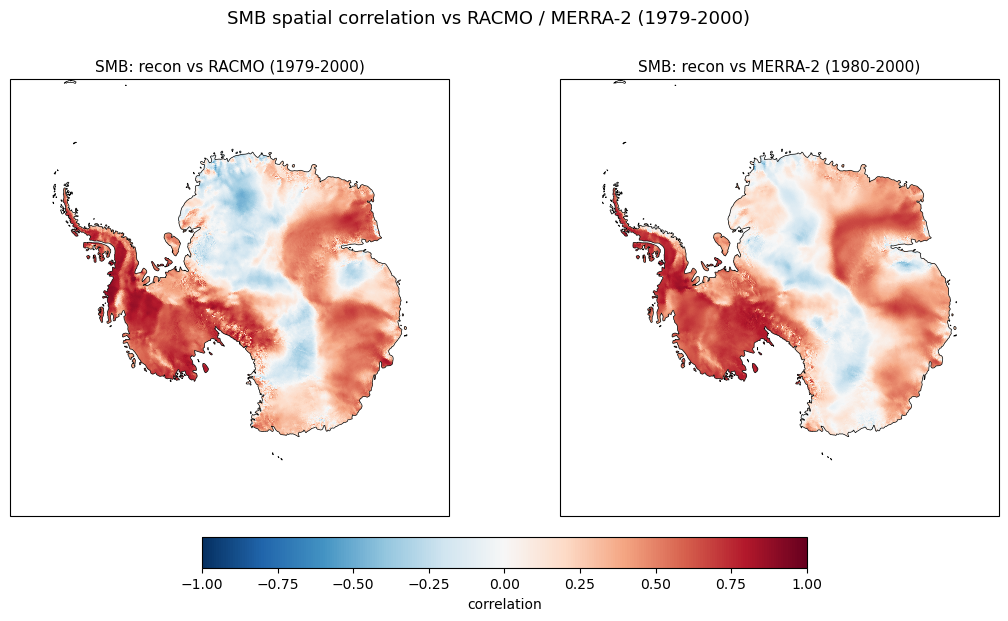

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_68427/2368247989.py:6: RuntimeWarning: Mean of empty slice
  oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_68427/2368247989.py:6: RuntimeWarning: Mean of empty slice
  oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)


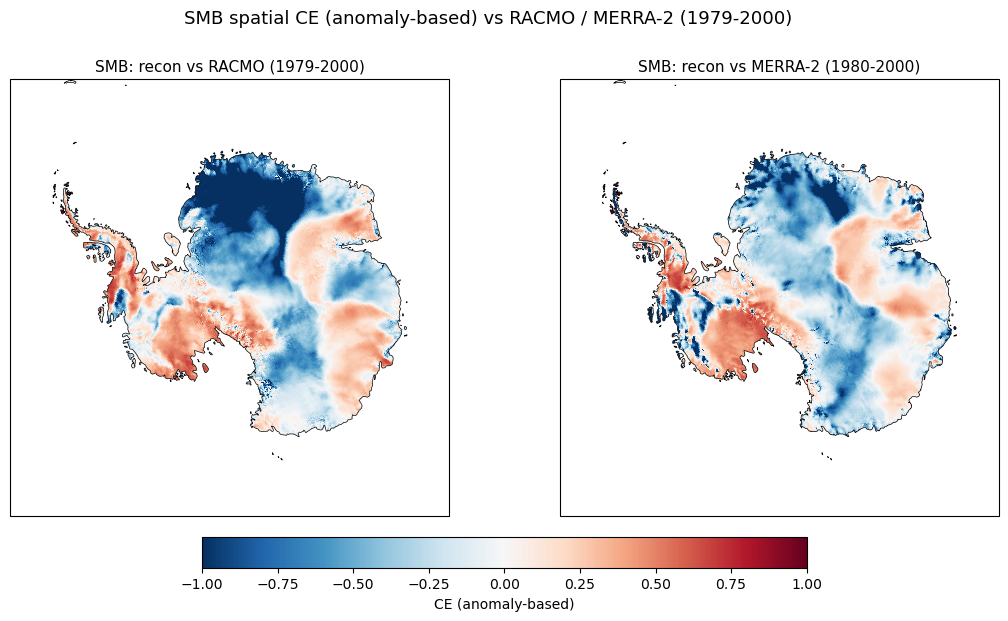

In [54]:
def spatial_corr(rec, obs):
    ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
    num = np.nansum(ra*oa, axis=0); den = np.sqrt(np.nansum(ra**2, axis=0)*np.nansum(oa**2, axis=0))
    with np.errstate(invalid="ignore"): return np.where(den > 0, num/den, np.nan)
def spatial_ce(rec, obs):
    oa = obs - np.nanmean(obs, axis=0); pa = rec - np.nanmean(rec, axis=0)
    num = np.nansum((oa-pa)**2, axis=0); den = np.nansum(oa**2, axis=0)
    with np.errstate(invalid="ignore"): return np.where(den > 0, 1.0 - num/den, np.nan)
def _align(recon_cube, obs_da, y0=1979, y1=2000):
    yrs = [y for y in range(y0, y1+1) if y in obs_da["year"].values]
    return recon_cube[[y-1801 for y in yrs]], obs_da.sel(year=yrs).values, (yrs[0], yrs[-1])

fields = {"RACMO": smb_ann, "MERRA-2": merra_ann}
for metric_name, fn in [("correlation", spatial_corr), ("CE (anomaly-based)", spatial_ce)]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    im = None
    for ax, src in zip(axes, ["RACMO", "MERRA-2"]):
        rec, obs, (ya, yb) = _align(racmo_smb_recon, fields[src])
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, fn(rec, obs), transform=ccrs.PlateCarree(),
                           vmin=-1, vmax=1, cmap="RdBu_r", zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(f"SMB: recon vs {src} ({ya}-{yb})", fontsize=11)
    cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.6); cb.set_label(metric_name)
    fig.suptitle(f"SMB spatial {metric_name} vs RACMO / MERRA-2 (1979-2000)", fontsize=13); plt.show()

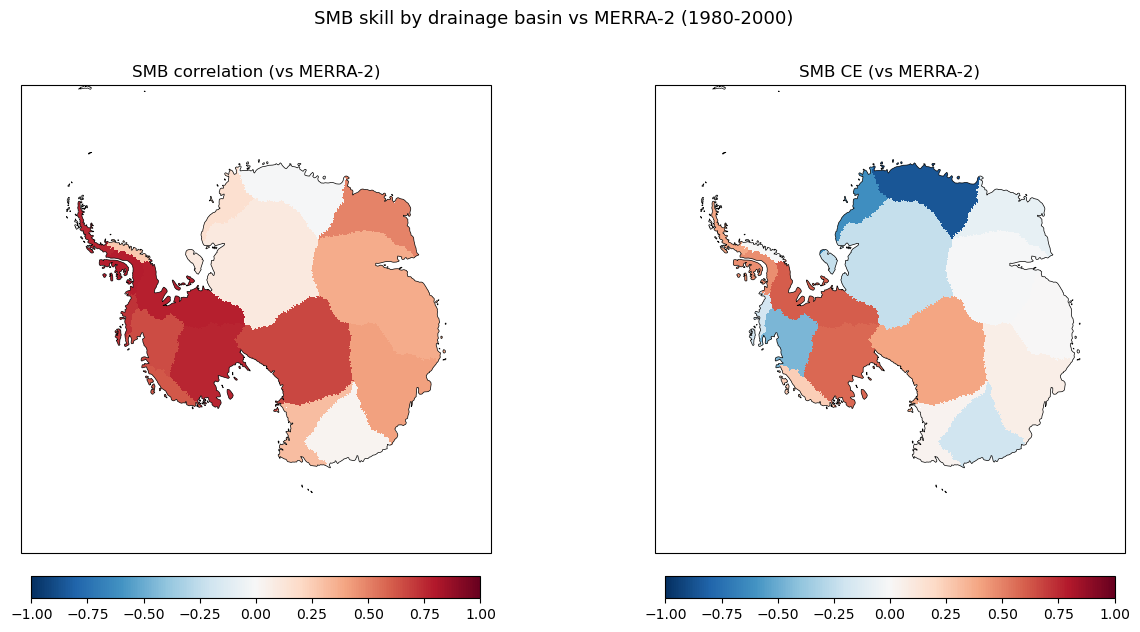

In [55]:
# --- SMB skill by drainage basin: anomaly correlation & CE vs MERRA-2 (1980-2000) ---
ov = [y for y in range(1980, 2001) if y in merra_years]
def basin_series(field3d, years, bid):
    mk = basin_mask == bid
    return pd.Series([np.nansum(np.where(mk, field3d[t]*cell_area_m2, 0))/1e12 for t in range(field3d.shape[0])],
                     index=np.asarray(years))
def basin_skill(recon3d, obs3d, recon_yrs, obs_yrs):
    out = {}
    for bid in basin_ids_unique:
        a = basin_series(recon3d, recon_yrs, bid).reindex(ov).values
        b = basin_series(obs3d, obs_yrs, bid).reindex(ov).values
        v = np.isfinite(a) & np.isfinite(b)
        if v.sum() < 3: out[bid] = (np.nan, np.nan); continue
        aa = a[v]-a[v].mean(); bb = b[v]-b[v].mean()
        out[bid] = (np.corrcoef(aa, bb)[0,1], 1.0 - np.sum((bb-aa)**2)/np.sum(bb**2))
    return out
def paint(sk, which):
    f = np.full(basin_mask.shape, np.nan)
    for bid, vals in sk.items(): f[basin_mask == bid] = vals[which]
    return f
smb_sk = basin_skill(racmo_smb_recon, merra_ann.values, recon_years, merra_years)
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, which) in zip(axes, [("SMB correlation", 0), ("SMB CE", 1)]):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(smb_sk, which), transform=ccrs.PlateCarree(),
                       vmin=-1, vmax=1, cmap="RdBu_r", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
    ax.set_title(f"{title} (vs MERRA-2)", fontsize=12)
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85)
fig.suptitle("SMB skill by drainage basin vs MERRA-2 (1980-2000)", fontsize=13); plt.show()

## 14. Save outputs

In [56]:
out_dir = os.path.expanduser("~/DataFiles/recon_ANT11_unc")
os.makedirs(out_dir, exist_ok=True)
np.savez_compressed(f"{out_dir}/recon_fields.npz",
                    racmo_smb_recon=racmo_smb_recon, racmo_smb_recon_std=racmo_smb_recon_std,
                    smb_reg_ens=smb_reg_ens, region_names=np.array(region_names),
                    lat=lat_racmo, lon=lon_racmo, recon_years=recon_years,
                    basin_mask=basin_mask, cell_area_m2=cell_area_m2)
pd.DataFrame({"year": recon_years, "AIS": ais_rac_recon, "AIS_std": ais_rac_std,
              "WAIS": wais_rac_recon, "WAIS_std": wais_rac_std, "EAIS": eais_rac_recon, "EAIS_std": eais_rac_std,
              "AP": ap_rac_recon, "AP_std": ap_rac_std}).to_csv(f"{out_dir}/smb_basin_recon.csv", index=False)
print("Saved (SMB with uncertainty) to", out_dir)

Saved (SMB with uncertainty) to /Users/advik/DataFiles/recon_ANT11_unc


Region  SMB base base 1sig    GRACE      SMB     dyn  (base 1801-1900)
AIS         2361      68.4   -114.7    200.1  -314.8
WAIS         839      25.7   -158.3     27.3  -185.6
EAIS        1192      62.5     68.5    104.1   -35.7
AP           330      19.7    -24.8     68.7   -93.5


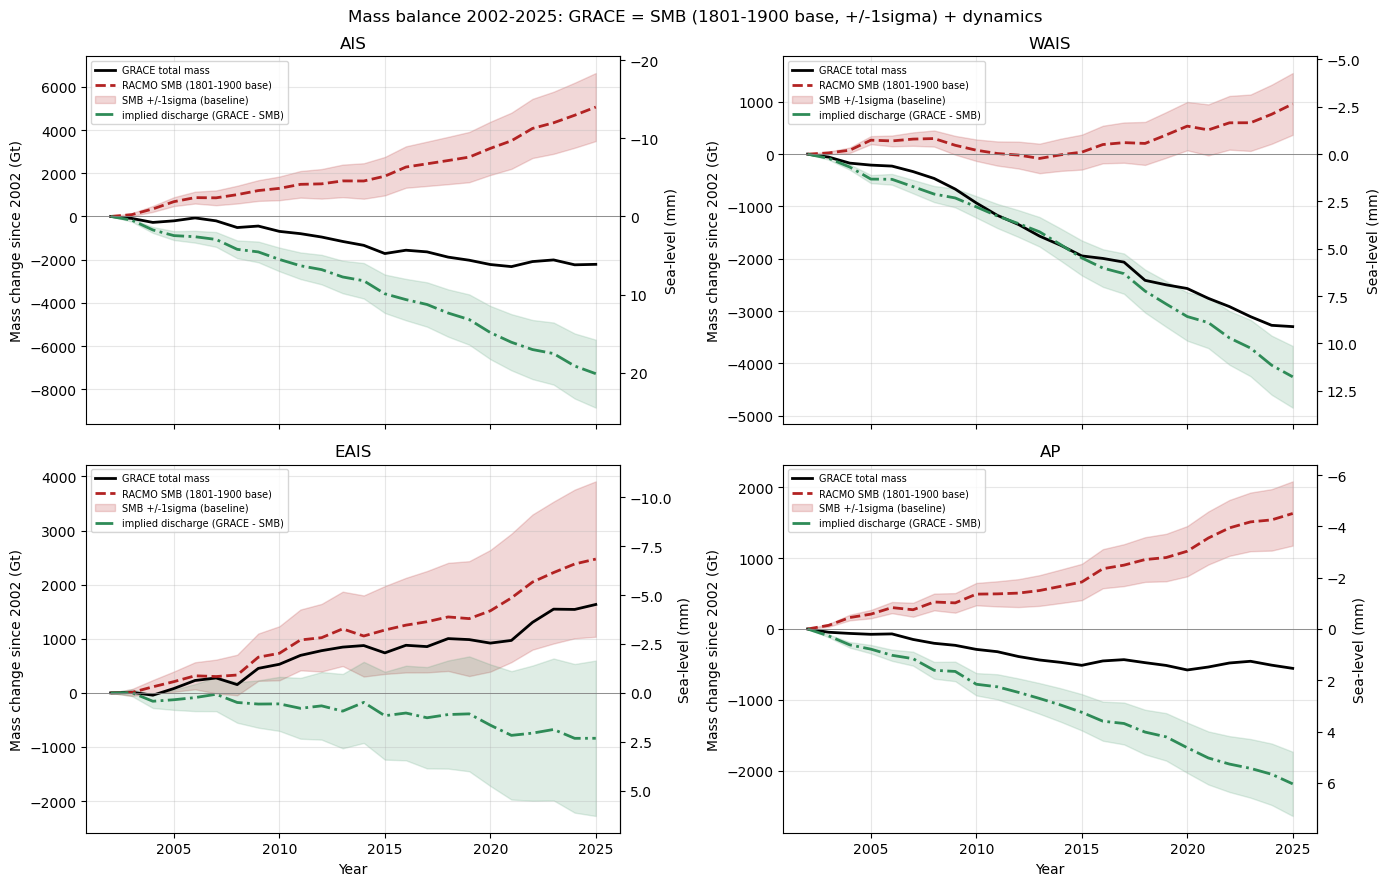

In [70]:
# --- Cumulative mass 2002-2025: GRACE total = RACMO SMB (baseline) + implied dynamics, with baseline error ---
BASELINE = (1801, 1900)          # <-- change as needed
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gid = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(to_xyz(glat2d.ravel(), glon2d.ravel()))
near = np.where(d * 6371.0 < 150, gid[ii], 0).reshape(glat2d.shape)
grace_masks = {"AIS": near > 0, "WAIS": np.isin(near, [3,7,8,9,10]),
               "EAIS": np.isin(near, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()

recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
raw_series   = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
region_idx   = {"AIS": 0, "WAIS": 1, "EAIS": 2, "AP": 3}
def combined_smb(r):
    rec = pd.Series(recon_series[r], index=recon_years)
    return pd.concat([rec.loc[:1978], raw_series[r].loc[1979:]])
def baseline_error(r):
    """1-sigma of the baseline mean = ensemble spread of the reconstructed 1801-1900 mean.
    (Raw-era baselines have no ensemble -> 0, since raw RACMO carries no posterior spread.)"""
    k = region_idx[r]
    yb = [y for y in range(BASELINE[0], BASELINE[1] + 1) if y <= 2000]
    if not yb:
        return 0.0
    return smb_reg_ens[[y - 1801 for y in yb], :, k].mean(axis=0).std(ddof=1)

yrs = np.arange(2002, 2026); GT_PER_MM = 361.8
def zeroed(s): return s.reindex(yrs) - s.reindex(yrs).loc[2002]
def trend(s):
    y = s.reindex(yrs).values; x = yrs.astype(float); v = np.isfinite(y)
    return np.polyfit(x[v], y[v], 1)[0] if v.sum() > 2 else np.nan

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'Region':<6}{'SMB base':>10}{'base 1sig':>10}{'GRACE':>9}{'SMB':>9}{'dyn':>8}  (base {BASELINE[0]}-{BASELINE[1]})")
for ax, r in zip(axes.ravel(), ["AIS", "WAIS", "EAIS", "AP"]):
    comb = combined_smb(r); base = comb.loc[BASELINE[0]:BASELINE[1]].mean()
    sig_base = baseline_error(r)
    g   = zeroed(grace_annual(grace_masks[r]))
    c   = zeroed((comb - base).loc[2002:2025].cumsum())
    dyn = g - c
    n_acc = np.arange(len(yrs))                       # baseline error grows with years accumulated
    c_err = n_acc * sig_base                          # 1-sigma on cumulative SMB from baseline (Gt)
    ax.plot(yrs, g.values,   color="black",     lw=2,          label="GRACE total mass")
    ax.plot(yrs, c.values,   color="firebrick", lw=2, ls="--", label=f"RACMO SMB ({BASELINE[0]}-{BASELINE[1]} base)")
    ax.fill_between(yrs, c.values - c_err, c.values + c_err, color="firebrick", alpha=0.18,
                    label="SMB +/-1sigma (baseline)")
    ax.plot(yrs, dyn.values, color="seagreen",  lw=2, ls="-.", label="implied discharge (GRACE - SMB)")
    ax.fill_between(yrs, dyn.values - c_err, dyn.values + c_err, color="seagreen", alpha=0.15)
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(r); ax.set_ylabel("Mass change since 2002 (Gt)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    secax = ax.secondary_yaxis("right", functions=(lambda m: -m/GT_PER_MM, lambda s: -s*GT_PER_MM))
    secax.set_ylabel("Sea-level (mm)")
    print(f"{r:<6}{base:>10.0f}{sig_base:>10.1f}{trend(g):>9.1f}{trend(c):>9.1f}{trend(dyn):>8.1f}")
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.suptitle(f"Mass balance 2002-2025: GRACE = SMB ({BASELINE[0]}-{BASELINE[1]} base, +/-1sigma) + dynamics", fontsize=12)
fig.tight_layout(); plt.show()


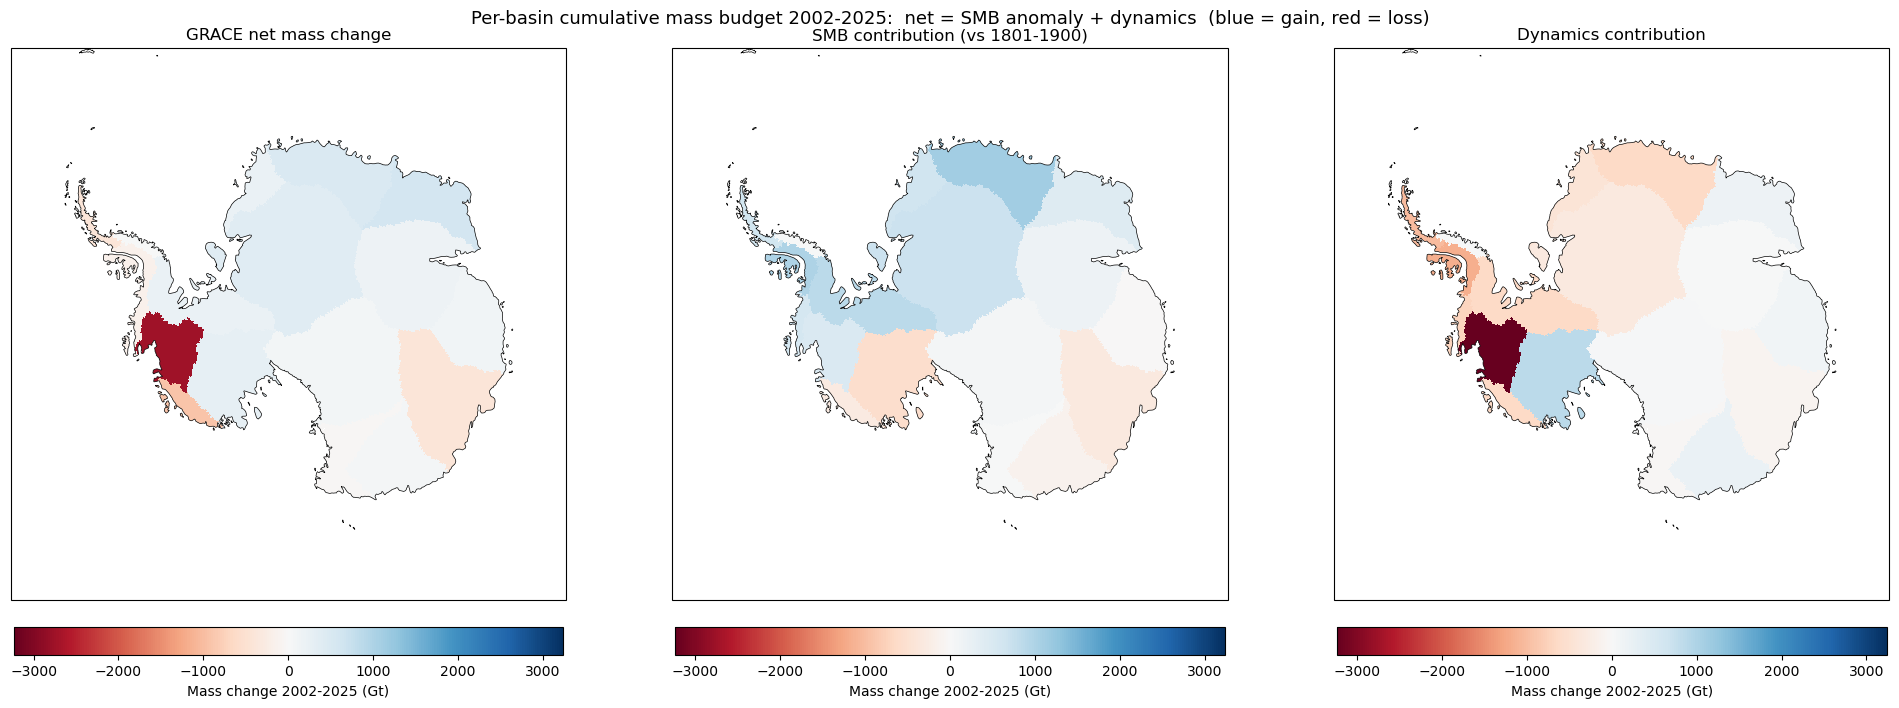

In [58]:
# --- Per-basin cumulative mass change 2002-2025 (Gt): GRACE net = SMB contribution + dynamics ---
BASELINE = (1801, 1900)          # <-- e.g. (1995, 2010) for a raw-RACMO-only baseline
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gidf = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(
            to_xyz(glat2d.ravel(), glon2d.ravel()))
near_basin = np.where(d * 6371.0 < 150, gidf[ii], 0).reshape(glat2d.shape)
gyear = pd.DatetimeIndex(grace["time"].values).year

y0, y1 = 2002, 2025
dM_grace, dM_smb, dM_dyn = {}, {}, {}
for bid in basin_ids_unique:
    gmask = near_basin == bid
    if gmask.sum() == 0:
        dM_grace[bid] = np.nan
    else:
        m = np.array([np.nansum(np.where(gmask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
        gm = pd.Series(m, index=gyear).groupby(level=0).mean()
        dM_grace[bid] = gm.get(y1, np.nan) - gm.get(y0, np.nan)
    rmask = basin_mask == bid
    smb = pd.Series([np.nansum(np.where(rmask, smb_ann.values[t]*cell_area_m2, 0)) / 1e12
                     for t in range(len(years_obs))], index=years_obs)                  # raw 1979-2025
    comb = pd.concat([smb_basin_recon[bid].loc[:1978], smb.loc[1979:]])                 # recon+raw combined
    base = comb.loc[BASELINE[0]:BASELINE[1]].mean()                                     # baseline over chosen period
    dM_smb[bid] = (smb.loc[y0:y1] - base).sum()
    dM_dyn[bid] = dM_grace[bid] - dM_smb[bid]

def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items():
        f[basin_mask == bid] = v
    return f

vmax = np.nanmax(np.abs(list(dM_grace.values()) + list(dM_smb.values()) + list(dM_dyn.values())))
panels = [("GRACE net mass change", dM_grace),
          (f"SMB contribution (vs {BASELINE[0]}-{BASELINE[1]})", dM_smb),
          ("Dynamics contribution", dM_dyn)]
fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, dct) in zip(axes, panels):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(dct), transform=ccrs.PlateCarree(),
                       vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label("Mass change 2002-2025 (Gt)")
fig.suptitle("Per-basin cumulative mass budget 2002-2025:  net = SMB anomaly + dynamics  (blue = gain, red = loss)",
             fontsize=13)
plt.tight_layout(); plt.show()


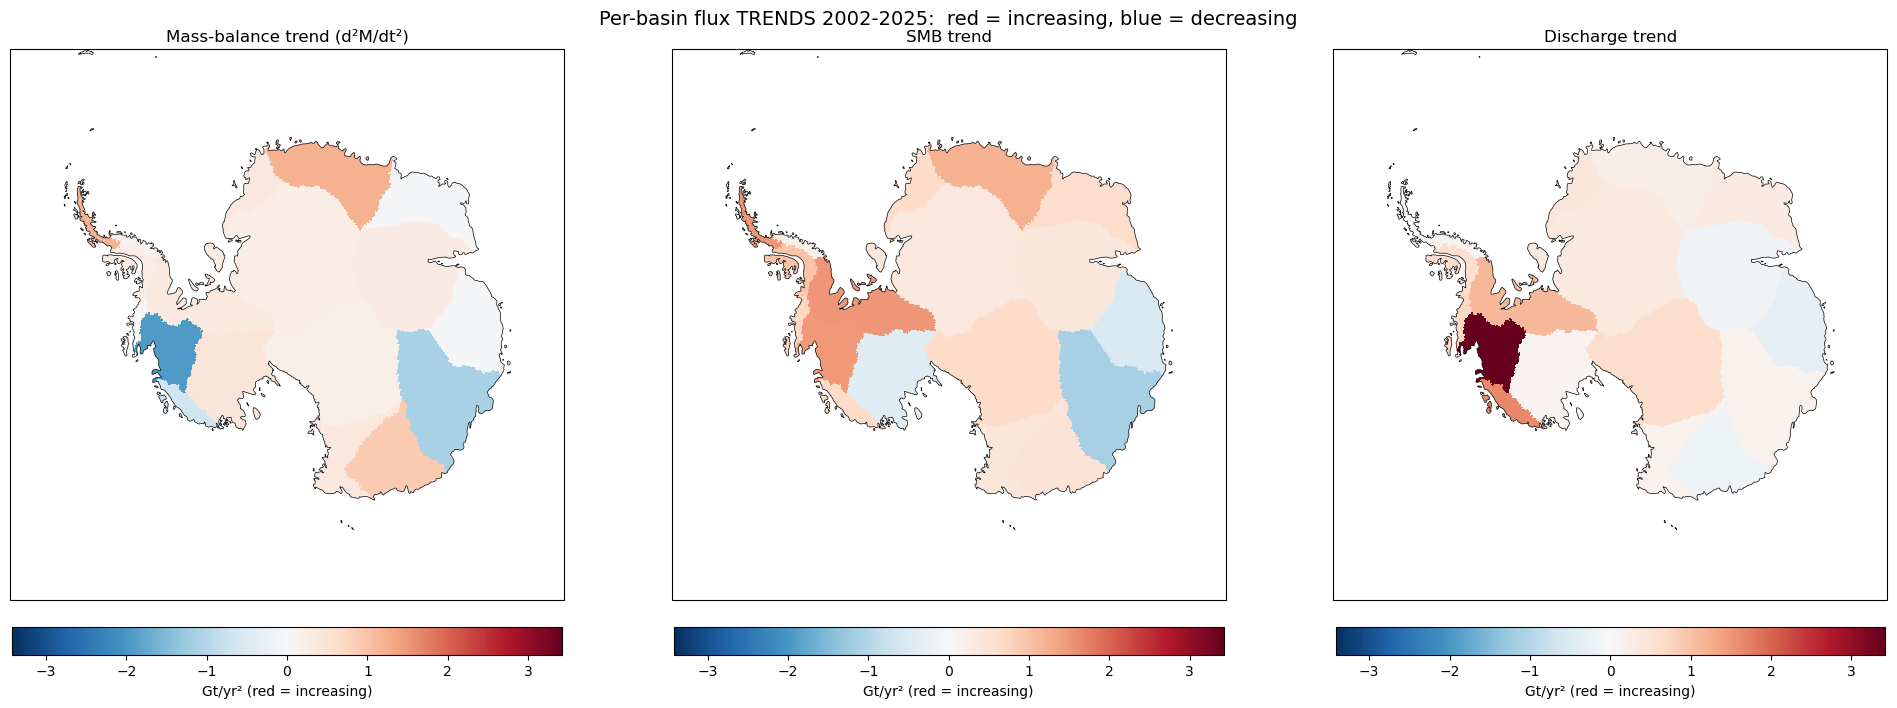

In [59]:
# --- 3-panel per-basin TREND maps: is SMB / discharge / mass balance increasing? (2003-2025) ---
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gid = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(
            to_xyz(glat2d.ravel(), glon2d.ravel()))
near_basin = np.where(d * 6371.0 < 150, gid[ii], 0).reshape(glat2d.shape)
gyear = pd.DatetimeIndex(grace["time"].values).year
yrs = np.arange(2002, 2026)

def tr(s):
    y = s.reindex(yrs).values; x = yrs.astype(float); v = np.isfinite(y)
    return np.polyfit(x[v], y[v], 1)[0] if v.sum() > 2 else np.nan

mb_acc, smb_tr, d_tr = {}, {}, {}
for bid in basin_ids_unique:
    gmask = near_basin == bid
    rmask = basin_mask == bid
    smb = pd.Series([np.nansum(np.where(rmask, smb_ann.values[t]*cell_area_m2, 0)) / 1e12
                     for t in range(len(years_obs))], index=years_obs)
    if gmask.sum() == 0:
        mb_acc[bid] = smb_tr[bid] = d_tr[bid] = np.nan
        continue
    m = np.array([np.nansum(np.where(gmask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    gm = pd.Series(m, index=gyear).groupby(level=0).mean()
    dMdt = pd.Series(gm.reindex(yrs).values - gm.reindex(yrs - 1).values, index=yrs)   # mass balance
    D = smb.reindex(yrs) - dMdt                                                          # discharge
    smb_tr[bid] = tr(smb)          # d(SMB)/dt
    mb_acc[bid] = tr(dMdt)         # d(mass balance)/dt  (mass acceleration)
    d_tr[bid]   = tr(D)            # d(discharge)/dt

def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items():
        f[basin_mask == bid] = v
    return f

vmax = np.nanmax(np.abs(list(mb_acc.values()) + list(smb_tr.values()) + list(d_tr.values())))
panels = [("Mass-balance trend (d²M/dt²)", mb_acc),
          ("SMB trend",                    smb_tr),
          ("Discharge trend",              d_tr)]

fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (title, dct) in zip(axes, panels):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(dct), transform=ccrs.PlateCarree(),
                       vmin=-vmax, vmax=vmax, cmap="RdBu_r", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label("Gt/yr² (red = increasing)")
fig.suptitle("Per-basin flux TRENDS 2002-2025:  red = increasing, blue = decreasing", fontsize=14)
plt.tight_layout(); plt.show()


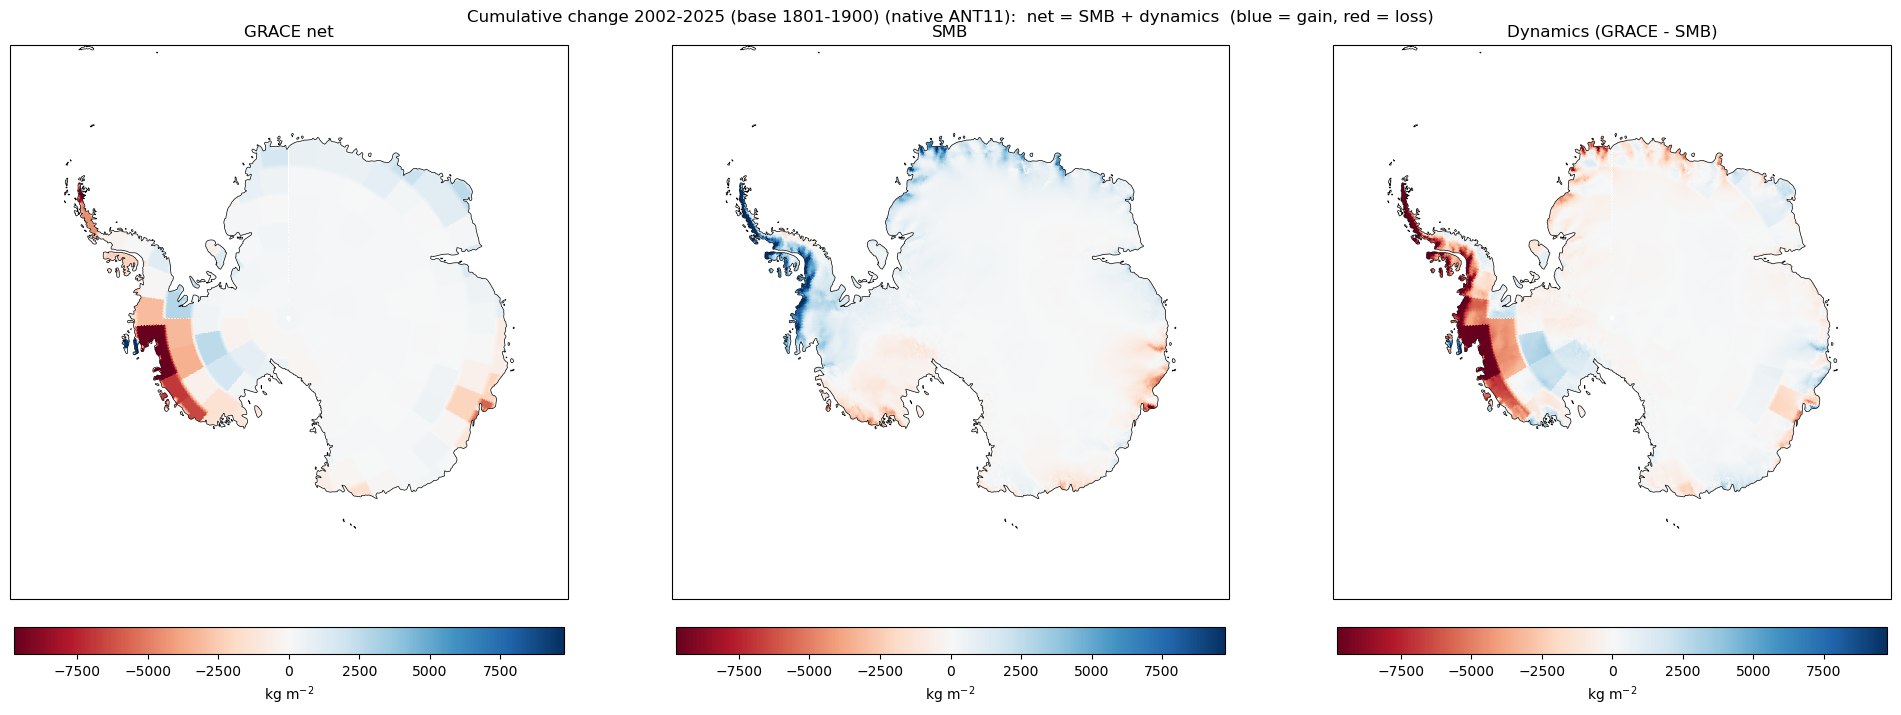

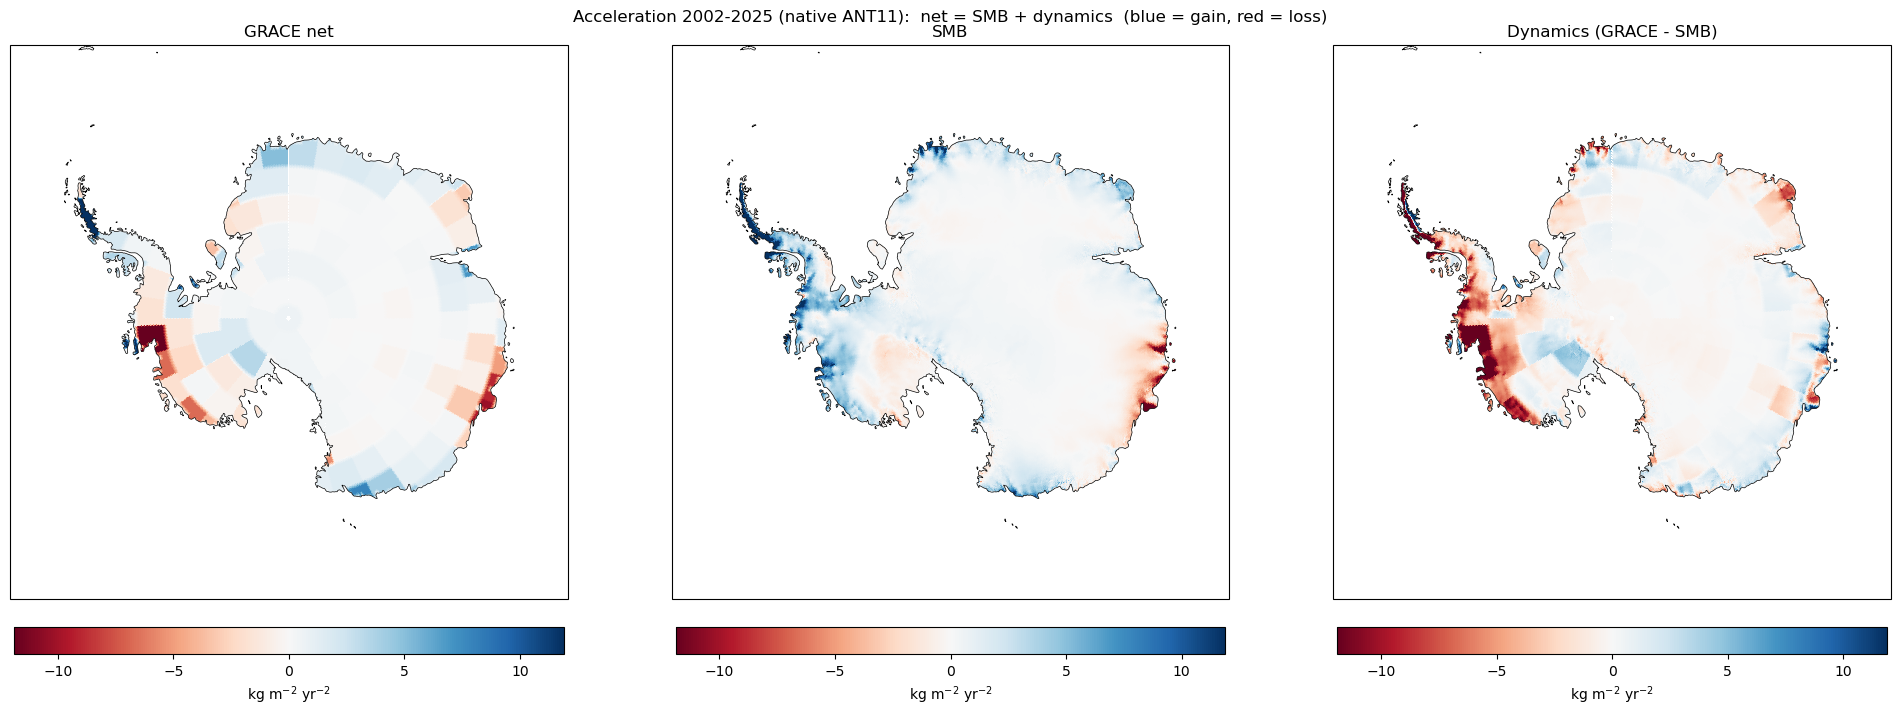

In [60]:
# --- Native-res mass budget 2002-2025: cumulative change (kg/m2) + acceleration (kg/m2/yr2) ---
BASELINE = (1801, 1900)          # <-- adjustable
from scipy.interpolate import RegularGridInterpolator
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values
gyear = pd.DatetimeIndex(grace["time"].values).year
ann = {int(y): np.nanmean(gsub.values[gyear == y], axis=0) for y in np.unique(gyear)}
def regrid_grace(field2d):
    lon_q = (lon_racmo + 360) % 360
    rgi = RegularGridInterpolator((glat, glon), field2d, bounds_error=False, fill_value=np.nan)
    return rgi(np.stack([lat_racmo.ravel(), lon_q.ravel()], -1)).reshape(NY, NX)
def cell_trend(stack, years):
    A = np.vstack([years.astype(float), np.ones(len(years))]).T
    Y = stack.reshape(len(years), -1); ok = np.isfinite(Y).all(0)
    sl = np.full(Y.shape[1], np.nan); sl[ok] = np.linalg.lstsq(A, Y[:, ok], rcond=None)[0][0]
    return sl.reshape(stack.shape[1:])

# Per-cell baseline over BASELINE, from combined series (recon <=1978, raw >=1979)
def cell_baseline_mean(b0, b1):
    parts, w = [], []
    if b0 <= 1978:
        r1 = min(b1, 1978); parts.append(racmo_smb_recon[b0-1801:r1-1801+1].sum(0)); w.append(r1 - b0 + 1)
    if b1 >= 1979:
        r0 = max(b0, 1979); sel = smb_ann.sel(year=slice(r0, b1)); parts.append(sel.sum("year").values); w.append(sel.sizes["year"])
    return sum(parts) / sum(w)
baseline = cell_baseline_mean(*BASELINE)

grace_net = np.where(ice_sheet, regrid_grace((ann[2025] - ann[2002]) * 10), np.nan)
smb_sel   = smb_ann.sel(year=slice(2002, 2025)); n = smb_sel.sizes["year"]
smb_net   = np.where(ice_sheet, smb_sel.sum("year").values - n * baseline, np.nan)
dyn_net   = grace_net - smb_net

smb_acc = np.where(ice_sheet, cell_trend(smb_ann.sel(year=slice(2002, 2025)).values, np.arange(2002, 2026)), np.nan)
yg = np.arange(2003, 2026)
dmdt = np.array([ann[y] - ann[y - 1] for y in yg]) * 10
mb_acc = np.where(ice_sheet, regrid_grace(cell_trend(dmdt, yg)), np.nan)
dyn_acc = mb_acc - smb_acc

for row_title, g, s, dd, unit in [
        (f"Cumulative change 2002-2025 (base {BASELINE[0]}-{BASELINE[1]})", grace_net, smb_net, dyn_net, "kg m$^{-2}$"),
        ("Acceleration 2002-2025", mb_acc, smb_acc, dyn_acc, "kg m$^{-2}$ yr$^{-2}$")]:
    vmax = np.nanpercentile(np.abs(np.concatenate([g[ice_sheet], s[ice_sheet], dd[ice_sheet]])), 99)
    labs = ["GRACE net", "SMB", "Dynamics (GRACE - SMB)"] if unit.endswith("$^{-2}$") \
           else ["Mass-balance accel.", "SMB accel.", "Dynamics accel."]
    fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, title, fld in zip(axes, labs, [g, s, dd]):
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, fld, transform=ccrs.PlateCarree(),
                           vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(title, fontsize=12, pad=6)
        fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label(unit)
    fig.suptitle(f"{row_title} (native ANT11):  net = SMB + dynamics  (blue = gain, red = loss)", fontsize=12)
    plt.tight_layout(); plt.show()


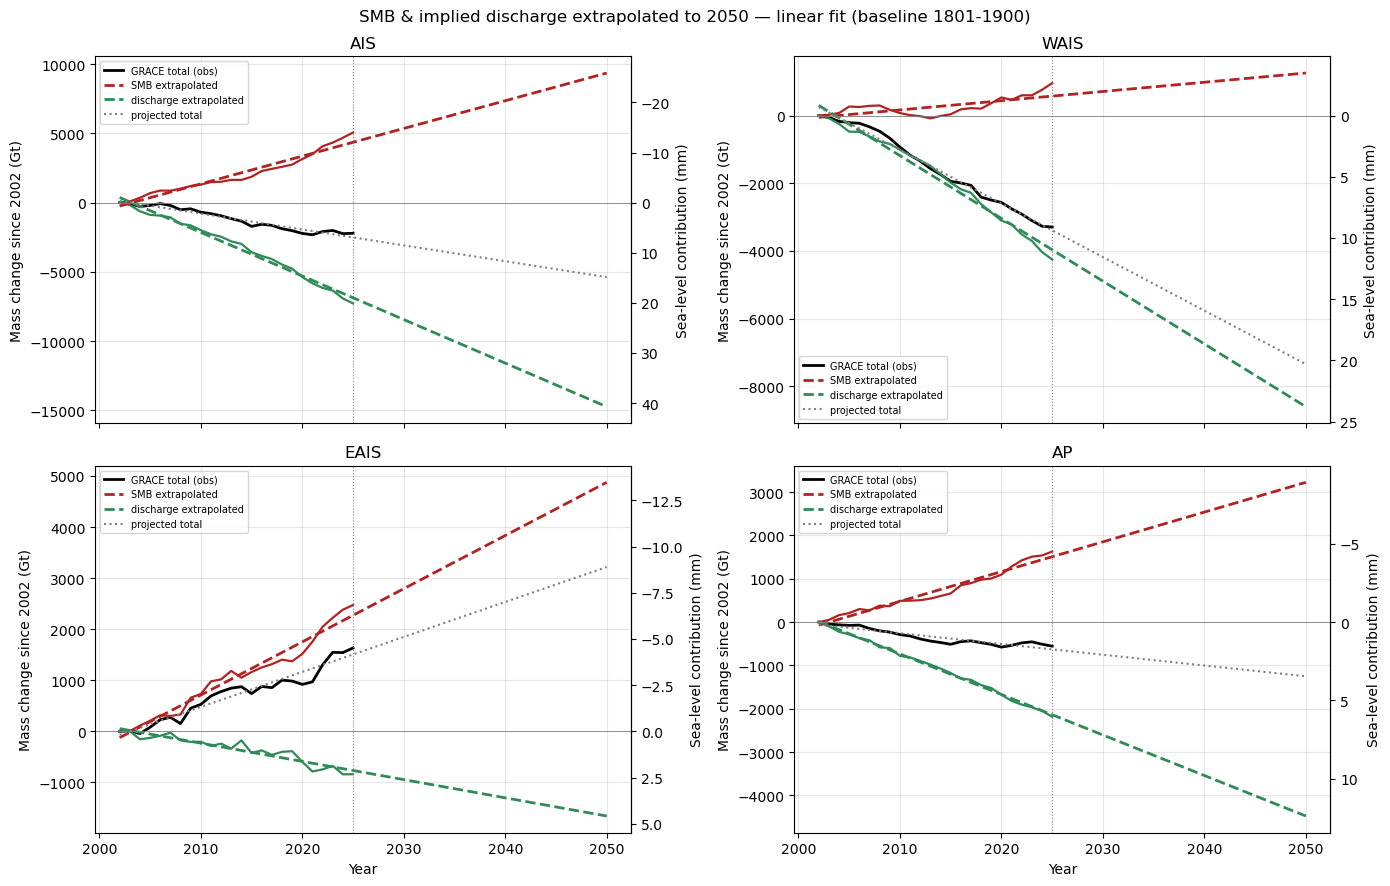

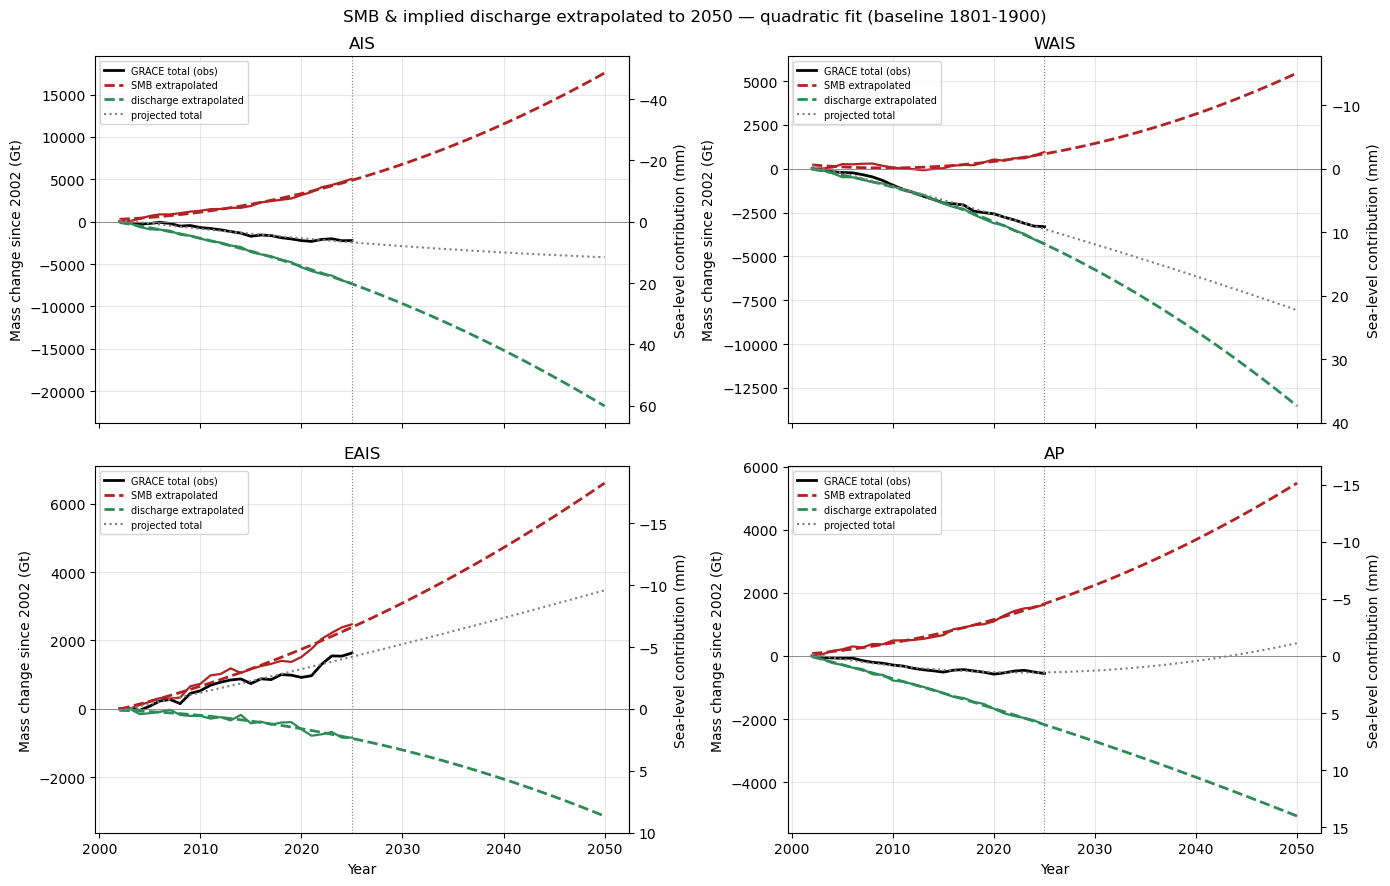

In [61]:
# --- Extrapolate SMB (red) and implied discharge (green): linear and quadratic versions ---
TARGET_YEAR = 2050
BASELINE = (1801, 1900)          # <-- adjustable
grace = xr.open_dataset(os.path.expanduser(
    "~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60))
glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5) *
         (np.sin(np.deg2rad(glat+0.25)) - np.sin(np.deg2rad(glat-0.25))))[:, None] * np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat)
gidf = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(
            to_xyz(glat2d.ravel(), glon2d.ravel()))
near = np.where(d * 6371.0 < 150, gidf[ii], 0).reshape(glat2d.shape)
grace_masks = {"AIS": near > 0, "WAIS": np.isin(near, [3,7,8,9,10]),
               "EAIS": np.isin(near, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()

recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
raw_series   = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
def baseline_mean(r):
    comb = pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
    return comb.loc[BASELINE[0]:BASELINE[1]].mean()

hist = np.arange(2002, 2026); fut = np.arange(2002, TARGET_YEAR + 1)
GT_PER_MM = 361.8
t = (hist - 2002).astype(float); tf = (fut - 2002).astype(float)
def proj(y, deg):
    v = np.isfinite(y); return np.polyval(np.polyfit(t[v], y[v], deg), tf)

for DEG, name in [(1, "linear"), (2, "quadratic")]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    for ax, r in zip(axes.ravel(), ["AIS", "WAIS", "EAIS", "AP"]):
        g = grace_annual(grace_masks[r]).reindex(hist)
        black = (g - g.loc[2002]).values
        rc = (raw_series[r] - baseline_mean(r)).loc[2002:2025].cumsum()
        red = (rc - rc.loc[2002]).reindex(hist).values
        green = black - red
        red_ext, green_ext = proj(red, DEG), proj(green, DEG)
        ax.plot(hist, black, "k-", lw=2, label="GRACE total (obs)")
        ax.plot(hist, red,   color="firebrick", lw=1.6)
        ax.plot(hist, green, color="seagreen",  lw=1.6)
        ax.plot(fut, red_ext,   "--", color="firebrick", lw=2, label="SMB extrapolated")
        ax.plot(fut, green_ext, "--", color="seagreen",  lw=2, label="discharge extrapolated")
        ax.plot(fut, red_ext + green_ext, ":", color="gray", lw=1.5, label="projected total")
        ax.axvline(2025, color="gray", lw=0.8, ls=":"); ax.axhline(0, color="gray", lw=0.6)
        ax.set_title(r); ax.set_ylabel("Mass change since 2002 (Gt)")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
        secax = ax.secondary_yaxis("right", functions=(lambda m: -m / GT_PER_MM, lambda s: -s * GT_PER_MM))
        secax.set_ylabel("Sea-level contribution (mm)")
    for ax in axes[-1, :]:
        ax.set_xlabel("Year")
    fig.suptitle(f"SMB & implied discharge extrapolated to {TARGET_YEAR} \u2014 {name} fit (baseline {BASELINE[0]}-{BASELINE[1]})",
                 fontsize=12)
    fig.tight_layout(); plt.show()


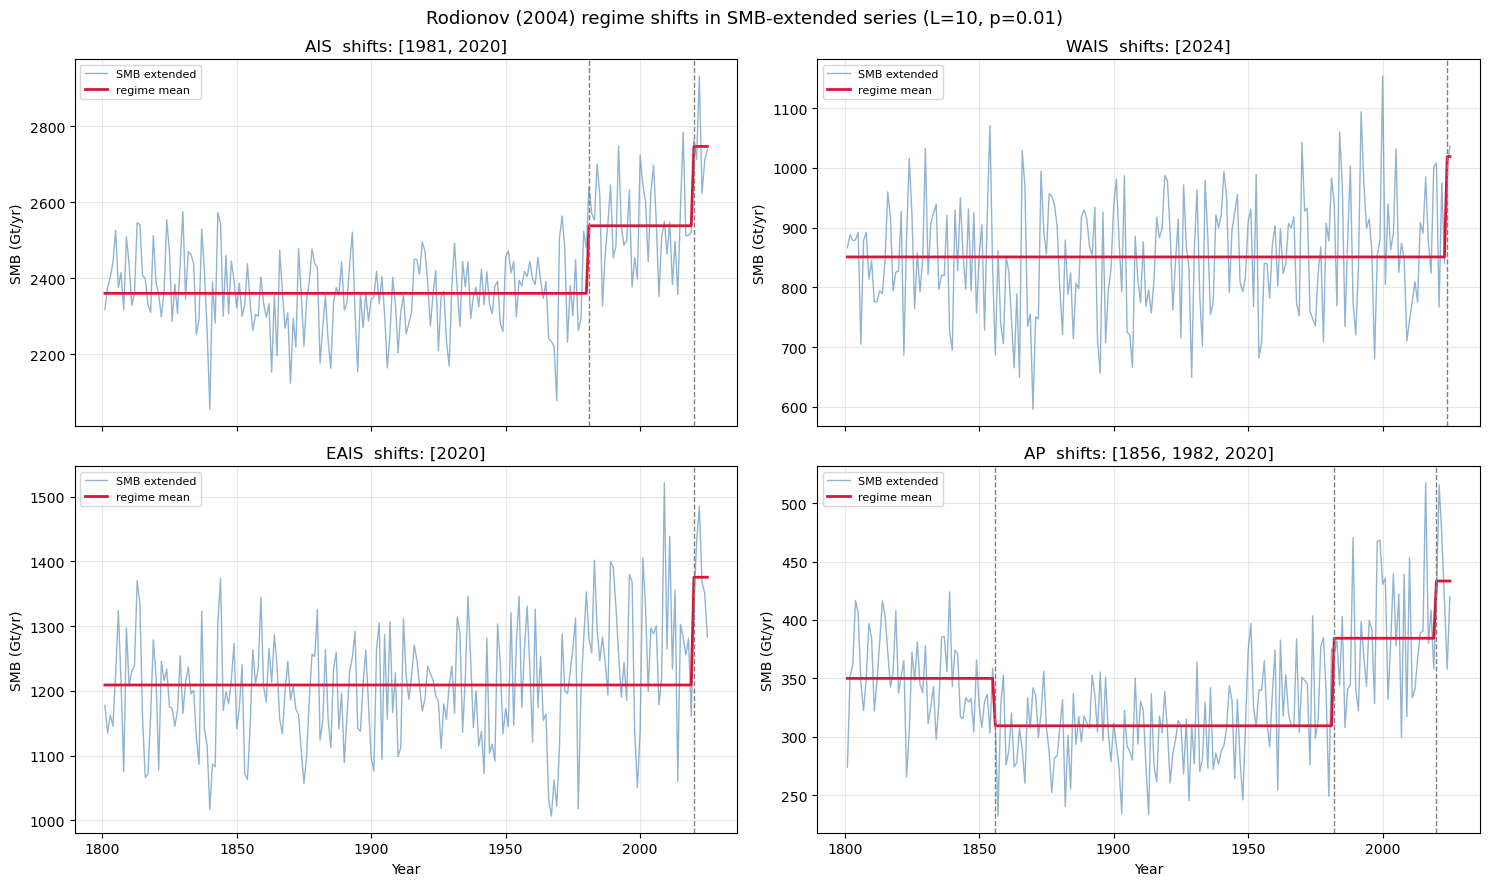

In [112]:
from scipy.stats import t as t_test

def rodionov_regimes(data, l, p):
    """Rodionov (2004) STARS regime-shift detection. Returns (shift_indices, rsi)."""
    data = np.asarray(data, float); n = len(data)
    regime_shift_indices = []; rsi = np.zeros(n)
    t_stat  = np.abs(t_test.ppf(p, (2*l - 2)))
    avg_var = np.mean([np.var(data[i:(i+l)]) for i in range(n - l)])
    diff    = t_stat * np.sqrt(2 * avg_var / l)
    r1 = np.mean(data[:l]); r1_lower = r1 - diff; r1_upper = r1 + diff
    i = l + 1
    while i < n:
        if data[i] < r1_lower or data[i] > r1_upper:
            j = i
            test_r2 = r1_lower if data[i] < r1_lower else r1_upper
            for k in range(j + 1, min(j + l, n)):
                if   data[j] > r1: rsi[j] += (data[k] - test_r2) / (avg_var * l)
                elif data[j] < r1: rsi[j] += (test_r2 - data[k]) / (avg_var * l)
                if rsi[j] < 0: rsi[j] = 0; break
            if rsi[j] > 0:
                regime_shift_indices.append(j)
                r1 = np.mean(data[j:min(j + l, n)]); r1_lower = r1 - diff; r1_upper = r1 + diff
            i = j + 1
        else:
            r1 = ((l - 1) * r1 + data[i]) / l
        i += 1
    return regime_shift_indices, rsi

# --- Apply to SMB-extended series (reconstruction 1801-2000 + raw obs 2001-2025) ---
L, P = 10, 0.01                                        # min regime length; significance
ext_years = np.concatenate([recon_years, np.arange(2001, 2026)])     # 1801-2025
smb_ext = {"AIS":  np.concatenate([ais_rac_recon,  np.array(ais_rac)[22:]]),
           "WAIS": np.concatenate([wais_rac_recon, np.array(wais_rac)[22:]]),
           "EAIS": np.concatenate([eais_rac_recon, np.array(eais_rac)[22:]]),
           "AP":   np.concatenate([ap_rac_recon,   np.array(ap_rac)[22:]])}

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for ax, r in zip(axes.ravel(), ["AIS", "WAIS", "EAIS", "AP"]):
    ts = smb_ext[r]
    shifts, rsi = rodionov_regimes(ts, L, P)
    bounds = [0] + list(shifts) + [len(ts)]
    reg_mean = np.concatenate([np.full(b - a, ts[a:b].mean()) for a, b in zip(bounds[:-1], bounds[1:])])
    ax.plot(ext_years, ts, color="steelblue", lw=1, alpha=0.6, label="SMB extended")
    ax.plot(ext_years, reg_mean, color="crimson", lw=2, label="regime mean")
    for s in shifts:
        ax.axvline(ext_years[s], color="gray", ls="--", lw=1)
    ax.set_title(f"{r}  shifts: {[int(ext_years[s]) for s in shifts]}")
    ax.set_ylabel("SMB (Gt/yr)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
for ax in axes[-1, :]:
    ax.set_xlabel("Year")
fig.suptitle(f"Rodionov (2004) regime shifts in SMB-extended series (L={L}, p={P})", fontsize=13)
fig.tight_layout(); plt.show()


Detecting first regime shift >= 1980 over 113482 grounded cells (a few minutes) ...


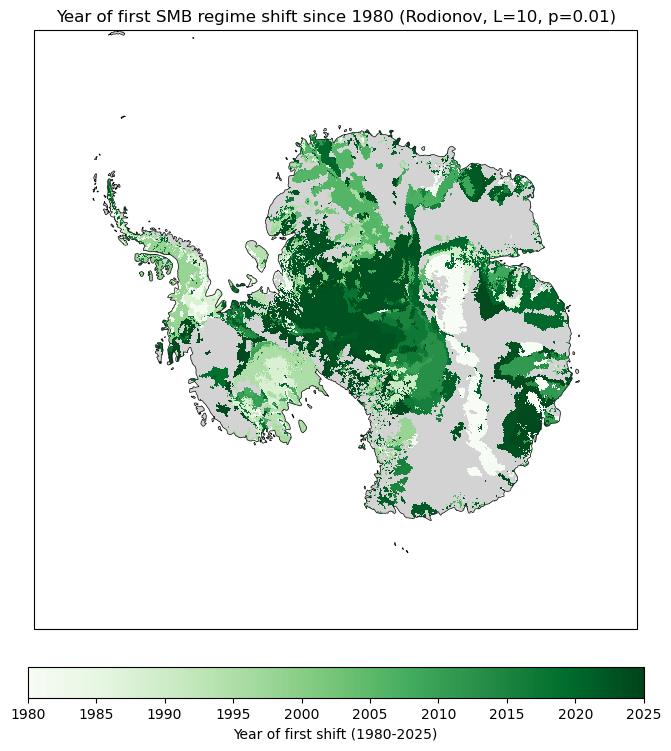

Grounded cells with a shift since 1980: 58.8%


In [107]:
from scipy.stats import t as t_test

def first_shift_from(x, l, p, years, start_year=1980):
    """Year of the first regime shift at year >= start_year (any century); NaN if none."""
    n = len(x)
    if n < 2*l or not np.all(np.isfinite(x)): return np.nan
    t_stat = np.abs(t_test.ppf(p, 2*l - 2))
    c1 = np.cumsum(np.insert(x, 0, 0.0)); c2 = np.cumsum(np.insert(x*x, 0, 0.0))
    s = c1[l:] - c1[:-l]; ss = c2[l:] - c2[:-l]
    wvar = ss/l - (s/l)**2
    avg_var = wvar[:-1].mean() if len(wvar) > 1 else wvar.mean()
    if not np.isfinite(avg_var) or avg_var <= 0: return np.nan
    diff = t_stat * np.sqrt(2*avg_var/l)
    r1 = x[:l].mean(); lo = r1 - diff; hi = r1 + diff
    i = l + 1
    while i < n:
        if x[i] < lo or x[i] > hi:
            j = i; test_r2 = lo if x[i] < lo else hi; rsi = 0.0; up = x[j] > r1
            for k in range(j + 1, min(j + l, n)):
                rsi += (x[k] - test_r2)/(avg_var*l) if up else (test_r2 - x[k])/(avg_var*l)
                if rsi < 0: rsi = 0.0; break
            if rsi > 0:
                Y = years[j]
                if Y >= start_year:
                    return Y                              # first shift at/after start_year (any year)
                r1 = x[j:min(j + l, n)].mean(); lo = r1 - diff; hi = r1 + diff
            i = j + 1
        else:
            r1 = ((l - 1)*r1 + x[i]) / l
        i += 1
    return np.nan

# --- Per-cell detection on the extended series (1801-2025 = reconstruction + raw RACMO) ---
L, P, START_YEAR = 10, 0.01, 1980
smb_ext_cube = np.concatenate([racmo_smb_recon, smb_ann.sel(year=slice(2001, 2025)).values], axis=0)  # (225, NY, NX)
years_ext = np.concatenate([recon_years, np.arange(2001, 2026)])

first_shift = np.full((NY, NX), np.nan)
gj, gk = np.where(ice_sheet)
print("Detecting first regime shift >= %d over %d grounded cells (a few minutes) ..." % (START_YEAR, len(gj)))
for j, k in zip(gj, gk):
    first_shift[j, k] = first_shift_from(smb_ext_cube[:, j, k], L, P, years_ext, START_YEAR)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, first_shift, transform=ccrs.PlateCarree(),
                   cmap="Greens", vmin=START_YEAR, vmax=2025, zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
ax.set_title(f"Year of first SMB regime shift since {START_YEAR} (Rodionov, L={L}, p={P})")
fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8).set_label(f"Year of first shift ({START_YEAR}-2025)")
plt.tight_layout(); plt.show()
print("Grounded cells with a shift since %d: %.1f%%" % (START_YEAR, 100 * np.isfinite(first_shift[ice_sheet]).mean()))


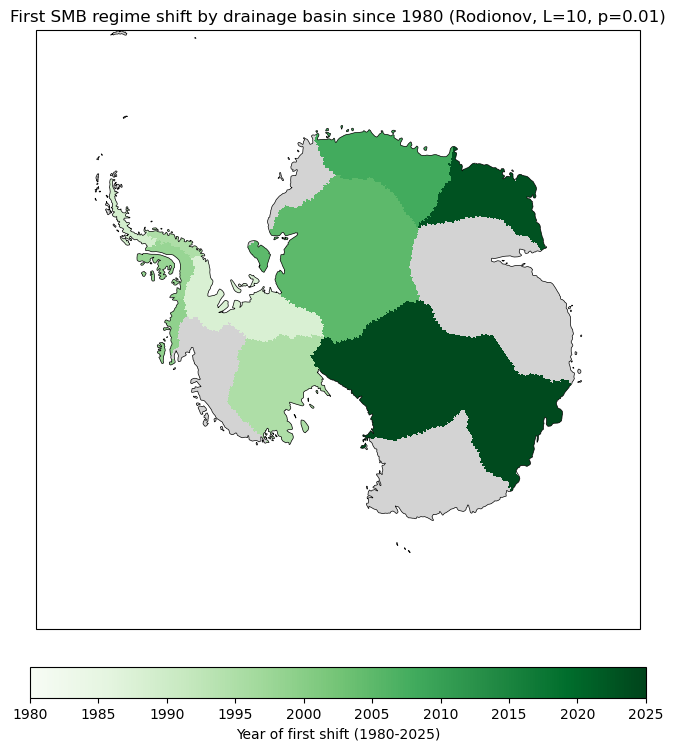

  basin  1: nan
  basin  2: 2005
  basin  3: 1988
  basin  4: 1995
  basin  5: 1989
  basin  6: 1998
  basin  7: 1999
  basin  8: nan
  basin  9: nan
  basin 10: 1995
  basin 11: 2024
  basin 12: nan
  basin 13: nan
  basin 14: 2024
  basin 15: nan
  basin 16: nan
  basin 17: 2023
  basin 18: 2008


In [115]:
L, P, START_YEAR = 10, 0.01, 1980
years_ext = np.concatenate([recon_years, np.arange(2001, 2026)])

first_shift_basin = {}
for bid in basin_ids_unique:
    ts = np.concatenate([smb_basin_recon[bid].values,                 # 1801-2000 reconstruction
                         smb_basin_obs[bid].loc[2001:2025].values])   # 2001-2025 raw RACMO
    first_shift_basin[bid] = first_shift_from(ts, L, P, years_ext, START_YEAR)

def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items():
        f[basin_mask == bid] = v
    return f

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, paint(first_shift_basin), transform=ccrs.PlateCarree(),
                   cmap="Greens", vmin=START_YEAR, vmax=2025, zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
ax.set_title(f"First SMB regime shift by drainage basin since {START_YEAR} (Rodionov, L={L}, p={P})")
fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8).set_label(f"Year of first shift ({START_YEAR}-2025)")
plt.tight_layout(); plt.show()
for bid in basin_ids_unique:
    print(f"  basin {int(bid):2d}: {first_shift_basin[bid]}")


In [119]:
# ============================================================================
# GGM (Generalized Gauss-Markov) noise model for SMB trend detection
# Franzke (2010, J. Climate) surrogate-trend test  +  King & Watson (2020) GGM
#
# GGM = white noise passed through the fractional filter (1 - (1-phi) L)^(-kappa/2)
#   kappa : spectral index  (0 = white, 1 = flicker, 2 = random walk)
#   phi   : 0<phi<=1, low-frequency corner (phi->1 = white, phi->0 = pure power law)
#   sigma_w : innovation (white-noise driving) standard deviation
# ============================================================================
import numpy as np
from scipy.optimize import minimize
from scipy import stats

def _ggm_psi(kappa, phi, K):
    """MA (impulse-response) coefficients of (1 - (1-phi) L)^(-kappa/2), length K."""
    d = 0.5 * kappa
    a = 1.0 - phi
    psi = np.empty(K)
    psi[0] = 1.0
    for k in range(1, K):
        psi[k] = psi[k-1] * (d + k - 1.0) / k * a
    return psi

def _ggm_acf(kappa, phi, n, K=None):
    """Normalised autocovariance r(0..n-1) for unit innovation variance."""
    if K is None:
        # geometric tail ~ (1-phi)^k; keep enough terms, cap for pure power-law
        K = int(min(20000, max(2000, 30 * n if phi > 0.02 else 20000)))
    psi = _ggm_psi(kappa, phi, K + n)
    return np.array([np.dot(psi[:K], psi[h:h+K]) for h in range(n)])

def _toeplitz(r):
    n = len(r); idx = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :])
    return r[idx]

def ggm_fit(x, kappa0=1.0, phi0=0.1, bounds=((0.0, 4.0), (1e-4, 1.0))):
    """Exact Gaussian MLE of GGM (sigma_w profiled out). x = mean-removed series."""
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    def negll(theta):
        kappa, phi = theta
        r = _ggm_acf(kappa, phi, n)
        R = _toeplitz(r)
        try:
            L = np.linalg.cholesky(R)
        except np.linalg.LinAlgError:
            return 1e12
        z = np.linalg.solve(L, x)
        s2 = (z @ z) / n                                    # profiled innovation var
        logdet = 2.0 * np.log(np.diag(L)).sum()
        return 0.5 * (n * np.log(2*np.pi*s2) + logdet + n)  # concentrated -logL
    res = minimize(negll, [kappa0, phi0], method="L-BFGS-B", bounds=bounds)
    kappa, phi = res.x
    r = _ggm_acf(kappa, phi, n); L = np.linalg.cholesky(_toeplitz(r))
    z = np.linalg.solve(L, x); sigma_w = np.sqrt((z @ z) / n)
    return dict(kappa=kappa, phi=phi, sigma_w=sigma_w, negll=res.fun, n=n)

def ggm_simulate_trends(fit, W, N=20000, rng=None):
    """N OLS slopes (per year) of W-length exact-GGM realisations from a fit dict."""
    rng = np.random.default_rng() if rng is None else rng
    r = _ggm_acf(fit["kappa"], fit["phi"], W) * fit["sigma_w"]**2
    L = np.linalg.cholesky(_toeplitz(r))
    X = L @ rng.standard_normal((W, N))                     # (W, N) exact GGM columns
    t = np.arange(W, dtype=float); t -= t.mean()
    return (t @ X) / (t @ t)                                # OLS slope of each column

def ar1_fit(x):
    """Cheap AR(1) benchmark null (Franzke's comparison model)."""
    x = np.asarray(x, float); x = x - x.mean()
    rho = np.clip(np.corrcoef(x[:-1], x[1:])[0, 1], -0.99, 0.99)
    sig = np.std(x, ddof=1) * np.sqrt(1 - rho**2)
    return dict(rho=rho, sigma=sig, mean0=True)

def ar1_simulate_trends(fit, W, N=20000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    e = fit["sigma"] * rng.standard_normal((W + 200, N)); y = np.empty_like(e)
    y[0] = e[0]
    for i in range(1, len(e)): y[i] = fit["rho"]*y[i-1] + e[i]
    y = y[200:]; t = np.arange(W, dtype=float); t -= t.mean()
    return (t @ y) / (t @ t)

def ols_trend(y):
    y = np.asarray(y, float); m = np.isfinite(y)
    return stats.linregress(np.arange(len(y))[m], y[m]).slope


Region  kappa   phi     sigma_w(Gt/yr)   AR1 rho
AIS     0.00   1.000        102.2      +0.18
WAIS    0.00   1.000         93.4      +0.11
EAIS    0.00   1.000         74.5      +0.26
AP      0.63   0.013         34.5      +0.43


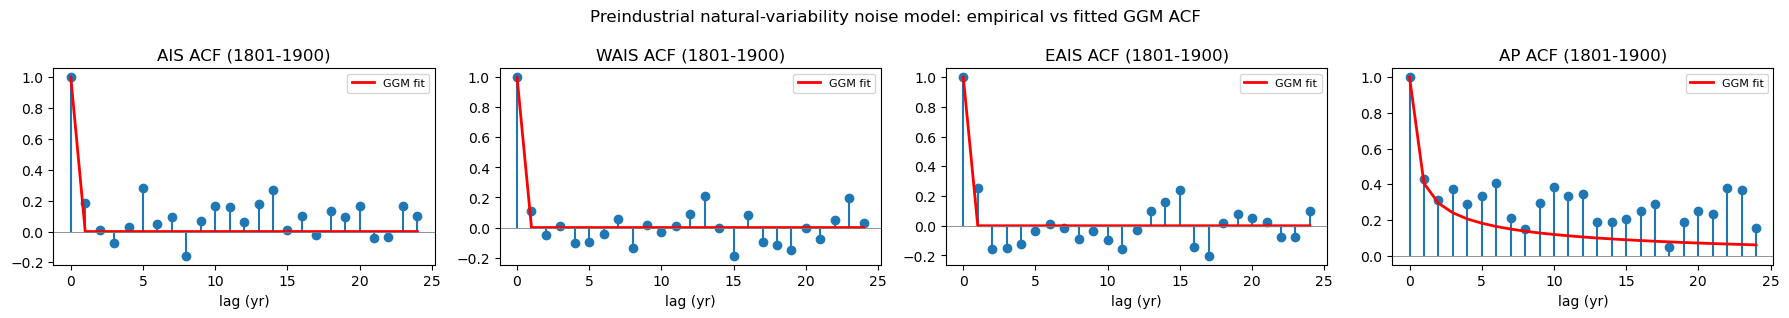

In [120]:
# --- Fit GGM to each region's preindustrial (1801-1900) natural variability ---
PI = slice(0, 100)                                   # recon_years index 1801..1900
regions = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon,
           "EAIS": eais_rac_recon, "AP": ap_rac_recon}

ggm_fits, ar1_fits = {}, {}
print("Region  kappa   phi     sigma_w(Gt/yr)   AR1 rho")
for r, ts in regions.items():
    x = np.asarray(ts)[PI]
    g = ggm_fit(x); a = ar1_fit(x)
    ggm_fits[r], ar1_fits[r] = g, a
    print(f"{r:5s}  {g['kappa']:5.2f}  {g['phi']:6.3f}  {g['sigma_w']:11.1f}      {a['rho']:+.2f}")

# Diagnostic: empirical vs fitted GGM autocorrelation on 1801-1900
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
for ax, r in zip(axes, regions):
    x = np.asarray(regions[r])[PI]; x = x - x.mean(); n = len(x)
    emp = np.array([1.0] + [np.corrcoef(x[:-h], x[h:])[0, 1] for h in range(1, 25)])
    fit = ggm_fits[r]; mod = _ggm_acf(fit["kappa"], fit["phi"], 25); mod /= mod[0]
    ax.stem(range(25), emp, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    ax.plot(range(25), mod, "r-", lw=2, label="GGM fit")
    ax.axhline(0, color="gray", lw=0.6); ax.set_title(f"{r} ACF (1801-1900)")
    ax.set_xlabel("lag (yr)"); ax.legend(fontsize=8)
fig.suptitle("Preindustrial natural-variability noise model: empirical vs fitted GGM ACF")
fig.tight_layout(); plt.show()


Region Window                    obs trend   GGM p  GGM %ile   AR1 p
--------------------------------------------------------------------------
AIS   1981-2025 (raw RACMO)       +22.88   0.056     97.2%   0.105
AIS   1901-2025 (extended)        +25.16   0.000    100.0%   0.000  <-- exceeds 95% band
AIS   2000-2025 (extended)        +81.17   0.002     99.9%   0.009  <-- exceeds 95% band
WAIS  1981-2025 (raw RACMO)        +3.87   0.715     64.6%   0.745
WAIS  1901-2025 (extended)         +4.26   0.066     96.7%   0.100
WAIS  2000-2025 (extended)        +30.88   0.204     89.6%   0.255
EAIS  1981-2025 (raw RACMO)       +11.26   0.191     90.4%   0.305
EAIS  1901-2025 (extended)         +9.52   0.000    100.0%   0.000  <-- exceeds 95% band
EAIS  2000-2025 (extended)        +30.13   0.121     94.1%   0.220
AP    1981-2025 (raw RACMO)        +7.75   0.341     83.2%   0.267
AP    1901-2025 (extended)        +11.38   0.000    100.0%   0.000  <-- exceeds 95% band
AP    2000-2025 (extended)     

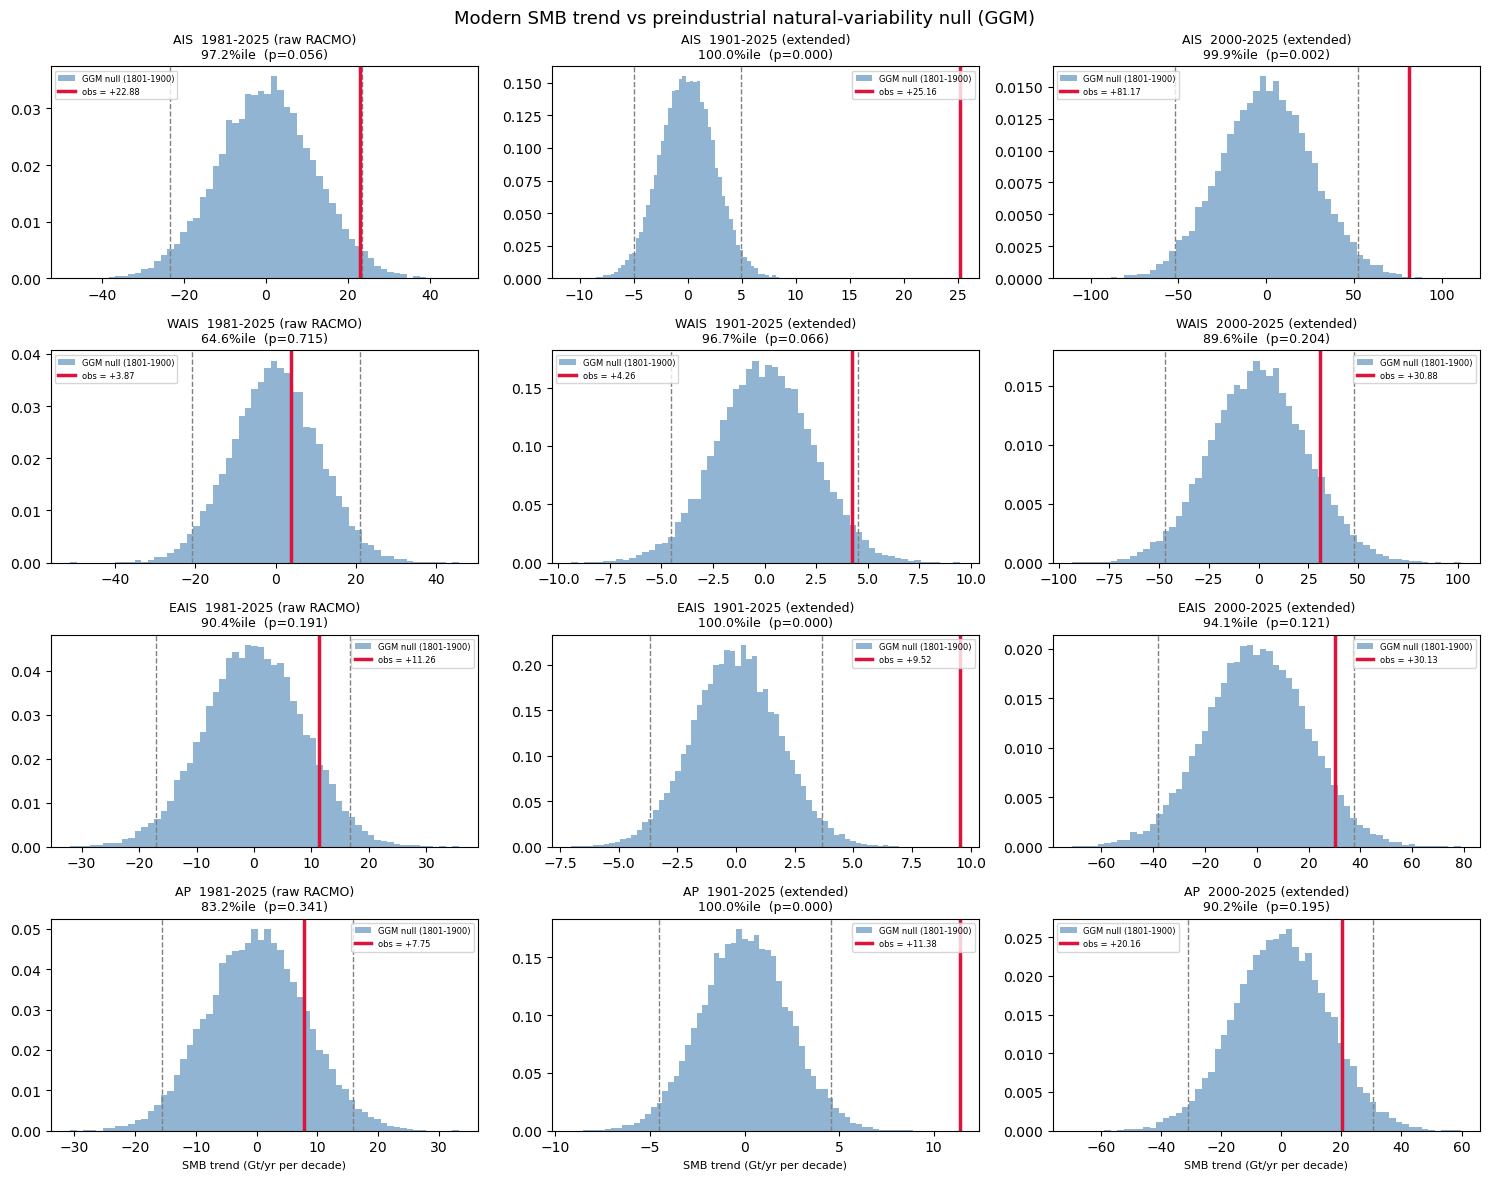

In [122]:
# --- Surrogate-trend detection test (Franzke 2010 style) ---
N_SURR = 20000
rng = np.random.default_rng(0)

# Extended series: recon 1801-1978, then raw RACMO 1979-2025 (split at 1979)
raw_obs = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
ext = {r: np.concatenate([np.asarray(regions[r])[:178],           # 1801-1978 recon
                          raw_obs[r].loc[1979:2025].values])      # 1979-2025 raw
       for r in regions}                                          # 1801-2025 (len 225)
ext_yrs = np.concatenate([recon_years[:178], np.arange(1979, 2026)])

def obs_trend(r, y0, y1, source="ext"):
    if source == "raw":                                     # raw RACMO only
        return ols_trend(raw_obs[r].loc[y0:y1].values)
    m = (ext_yrs >= y0) & (ext_yrs <= y1)
    return ols_trend(ext[r][m])

# windows to test: (label, y0, y1, source)
windows = [("1981-2025 (raw RACMO)", 1981, 2025, "raw"),
           ("1901-2025 (extended)",  1901, 2025, "ext"),
           ("2000-2025 (extended)",  2000, 2025, "ext")]

print(f"{'Region':5s} {'Window':22s} {'obs trend':>12s} {'GGM p':>7s} {'GGM %ile':>9s} {'AR1 p':>7s}")
print("-" * 74)
results = {}
for r in regions:
    for lbl, y0, y1, src in windows:
        W = y1 - y0 + 1
        obs = obs_trend(r, y0, y1, src) * 10                # per decade
        null_ggm = ggm_simulate_trends(ggm_fits[r], W, N_SURR, rng) * 10
        null_ar1 = ar1_simulate_trends(ar1_fits[r], W, N_SURR, rng) * 10
        p_ggm = (np.sum(np.abs(null_ggm) >= abs(obs)) + 1) / (N_SURR + 1)   # two-sided
        p_ar1 = (np.sum(np.abs(null_ar1) >= abs(obs)) + 1) / (N_SURR + 1)
        pct   = 100 * np.mean(null_ggm < obs)               # one-sided percentile
        results[(r, lbl)] = (obs, null_ggm, p_ggm, pct)
        star = "  <-- exceeds 95% band" if pct >= 97.5 or pct <= 2.5 else ""
        print(f"{r:5s} {lbl:22s} {obs:+11.2f}  {p_ggm:6.3f}  {pct:7.1f}%  {p_ar1:6.3f}{star}")

# --- Visualise: null trend distribution vs observed, all regions x all windows ---
fig, axes = plt.subplots(len(regions), len(windows), figsize=(15, 12))
for i, r in enumerate(regions):
    for j, (lbl, y0, y1, src) in enumerate(windows):
        ax = axes[i, j]
        obs, null_ggm, p, pct = results[(r, lbl)]
        ax.hist(null_ggm, bins=60, color="steelblue", alpha=0.6, density=True,
                label="GGM null (1801-1900)")
        for q in (2.5, 97.5):
            ax.axvline(np.percentile(null_ggm, q), color="gray", ls="--", lw=1)
        ax.axvline(obs, color="crimson", lw=2.5, label=f"obs = {obs:+.2f}")
        ax.set_title(f"{r}  {lbl}\n{pct:.1f}%ile  (p={p:.3f})", fontsize=9)
        if i == len(regions) - 1:
            ax.set_xlabel("SMB trend (Gt/yr per decade)", fontsize=8)
        ax.legend(fontsize=6)
fig.suptitle("Modern SMB trend vs preindustrial natural-variability null (GGM)", fontsize=13)
fig.tight_layout(); plt.show()


 basin  kappa   phi    obs(Gt/yr/dec)  sigma_trend  %ile
    1    1.63   0.538       +6.55         5.11    90.0
    2    0.75   0.151       +5.22         5.04    85.0
    3    0.48   0.013      +13.01         8.68    93.3
    4    0.00   1.000       +1.52         0.91    95.3
    5    0.42   0.017      +10.81         6.70    94.7
    6    0.74   0.015       +7.83         9.62    79.2
    7    0.48   0.018       +6.40         5.31    88.6
    8    0.00   1.000      +11.13         9.24    88.6
    9    0.00   1.000       +2.68         7.74    63.5
   10    0.00   1.000       -2.33         9.53    40.3
   11    0.00   1.000       +5.73         3.44    95.2
   12    0.00   1.000       +3.75         1.55    99.2
   13    0.00   1.000       +6.85         4.59    93.2
   14    0.00   1.000      -16.22         8.13     2.3
   15    0.00   1.000       -7.01         7.41    17.2
   16    0.00   1.000       +2.19         2.84    78.0
   17    0.82   0.329      +11.00         5.50    97.7
   18   

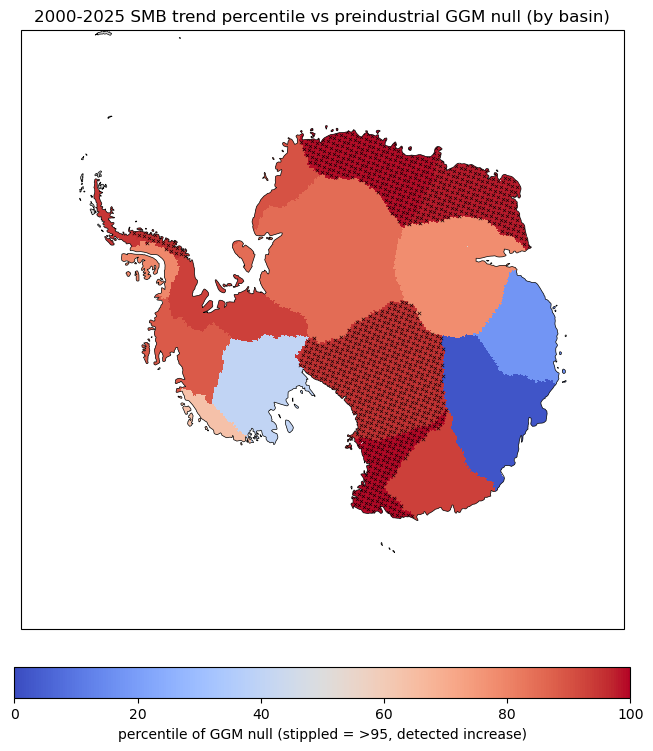

In [135]:
# --- Per-basin GGM detection percentile for the 2000-2025 SMB trend ---
# Exact per basin: fit GGM to 1801-1900 basin total, trend is Gaussian under the null.
from scipy.stats import norm

def ggm_trend_sd(fit, W):
    """SD of the OLS slope (per year) of a W-length GGM realisation."""
    r = _ggm_acf(fit["kappa"], fit["phi"], W) * fit["sigma_w"]**2
    C = _toeplitz(r)
    t = np.arange(W, dtype=float); t -= t.mean()
    return np.sqrt(t @ C @ t) / (t @ t)

W, y0, y1 = 26, 2000, 2025                         # 2000-2025 window (raw RACMO)
basin_fit, basin_pct = {}, {}
print(" basin  kappa   phi    obs(Gt/yr/dec)  sigma_trend  %ile")
for bid in basin_ids_unique:
    pre = smb_basin_recon[bid].values[:100]        # 1801-1900 basin total
    f = ggm_fit(pre); basin_fit[bid] = f
    obs = ols_trend(smb_basin_obs[bid].loc[y0:y1].values)   # 2000-2025 raw trend (per yr)
    sd  = ggm_trend_sd(f, W)
    basin_pct[bid] = 100 * norm.cdf(obs / sd)
    print(f"  {int(bid):3d}   {f['kappa']:5.2f}  {f['phi']:6.3f}   {obs*10:+9.2f}     "
          f"{sd*10:8.2f}   {basin_pct[bid]:5.1f}")

def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items():
        f[basin_mask == bid] = v
    return f

# grounded cells in basins at/above the 95th percentile -> subsampled stipple
det_basins = [b for b in basin_ids_unique if basin_pct[b] >= 95]
det = ice_sheet & np.isin(basin_mask, det_basins)
stride = 5                                          # thin the stipple; lower = denser
sub = np.zeros(det.shape, bool); sub[::stride, ::stride] = True
dj, dk = np.where(det & sub)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, paint(basin_pct), transform=ccrs.PlateCarree(),
                   cmap="coolwarm", vmin=0, vmax=100, zorder=1)
ax.scatter(lon_racmo[dj, dk], lat_racmo[dj, dk], s=6, marker="x", color="k",
           linewidths=0.5, alpha=0.9, transform=ccrs.PlateCarree(), zorder=1.5)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)   # masks stipple over ocean
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
ax.set_title("2000-2025 SMB trend percentile vs preindustrial GGM null (by basin)")
cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cb.set_label("percentile of GGM null (stippled = >95, detected increase)")
plt.tight_layout(); plt.show()


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


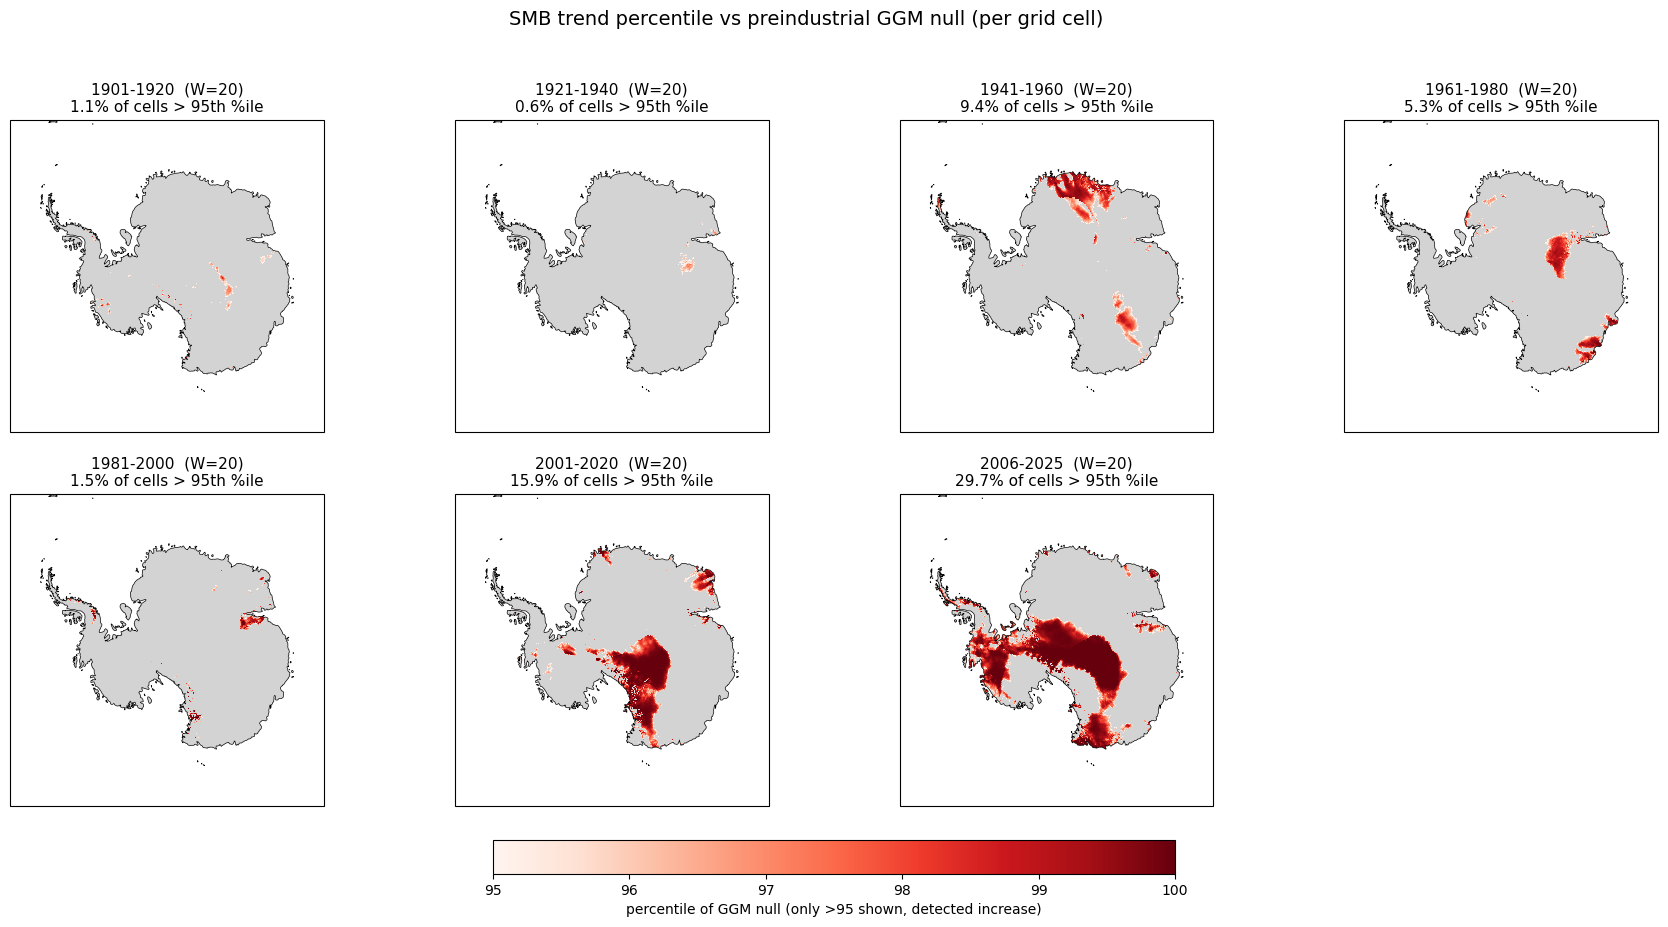

In [162]:
# --- Per-cell GGM detection percentile for consecutive 20-yr SMB trends ---
# Observed trend from the EXTENDED cube (recon 1801-1978 + raw RACMO 1979-2025).
# Null: per-basin GGM colour (basin_fit) x per-cell preindustrial amplitude.
# Only cells >= 95th percentile are shown; everything else is transparent.
periods = [(y, y + 19) for y in range(1901, 2010, 20)] + [(2006, 2025)]

# extended per-cell cube: recon 1801-1978, then raw RACMO 1979-2025
ext_cube = np.concatenate([racmo_smb_recon[:178],
                           smb_ann.sel(year=slice(1979, 2025)).values], axis=0)  # (225,NY,NX)
years_ext = np.concatenate([recon_years[:178], np.arange(1979, 2026)])

# each cell's own preindustrial (1801-1900) reconstruction std (window-independent)
cell_std = np.nanstd(racmo_smb_recon[:100], axis=0, ddof=1)    # (NY, NX)

def pct_map(y0, y1):
    """Per-cell detection percentile of the y0-y1 OLS trend vs the GGM null."""
    m = (years_ext >= y0) & (years_ext <= y1)
    W = int(m.sum())
    t = np.arange(W, dtype=float); t -= t.mean(); tt = t @ t
    Y = ext_cube[m]                                           # (W, NY, NX)
    obs_slope = np.tensordot(t, Y, axes=(0, 0)) / tt          # (NY, NX), per yr
    shape_map = np.full((NY, NX), np.nan)
    for bid in basin_ids_unique:
        f = basin_fit[bid]
        rW = _ggm_acf(f["kappa"], f["phi"], W); C = _toeplitz(rW)
        shape_map[basin_mask == bid] = np.sqrt(t @ C @ t) / tt / np.sqrt(rW[0])
    sigma_trend = cell_std * shape_map
    pct = np.full((NY, NX), np.nan)
    ok = ice_sheet & np.isfinite(obs_slope) & np.isfinite(sigma_trend) & (sigma_trend > 0)
    pct[ok] = 100 * norm.cdf(obs_slope[ok] / sigma_trend[ok])
    return pct, ok

ncols = 4; nrows = int(np.ceil(len(periods) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})
axes = np.atleast_1d(axes).ravel()
im = None
for ax, (y0, y1) in zip(axes, periods):
    pct, ok = pct_map(y0, y1)
    detected = np.ma.masked_where(~(ok & (pct >= 95)), pct)   # transparent below 95

    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, detected, transform=ccrs.PlateCarree(),
                       cmap="Reds", vmin=95, vmax=100, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(f"{y0}-{y1}  (W={y1 - y0 + 1})\n"
                 f"{100 * np.nanmean(pct[ice_sheet] > 95):.1f}% of cells > 95th %ile",
                 fontsize=11)
for ax in axes[len(periods):]:
    ax.axis("off")

cb = fig.colorbar(im, ax=axes.tolist(), orientation="horizontal", pad=0.04, shrink=0.4)
cb.set_label("percentile of GGM null (only >95 shown, detected increase)")
fig.suptitle("SMB trend percentile vs preindustrial GGM null (per grid cell)",
             fontsize=14)
plt.show()


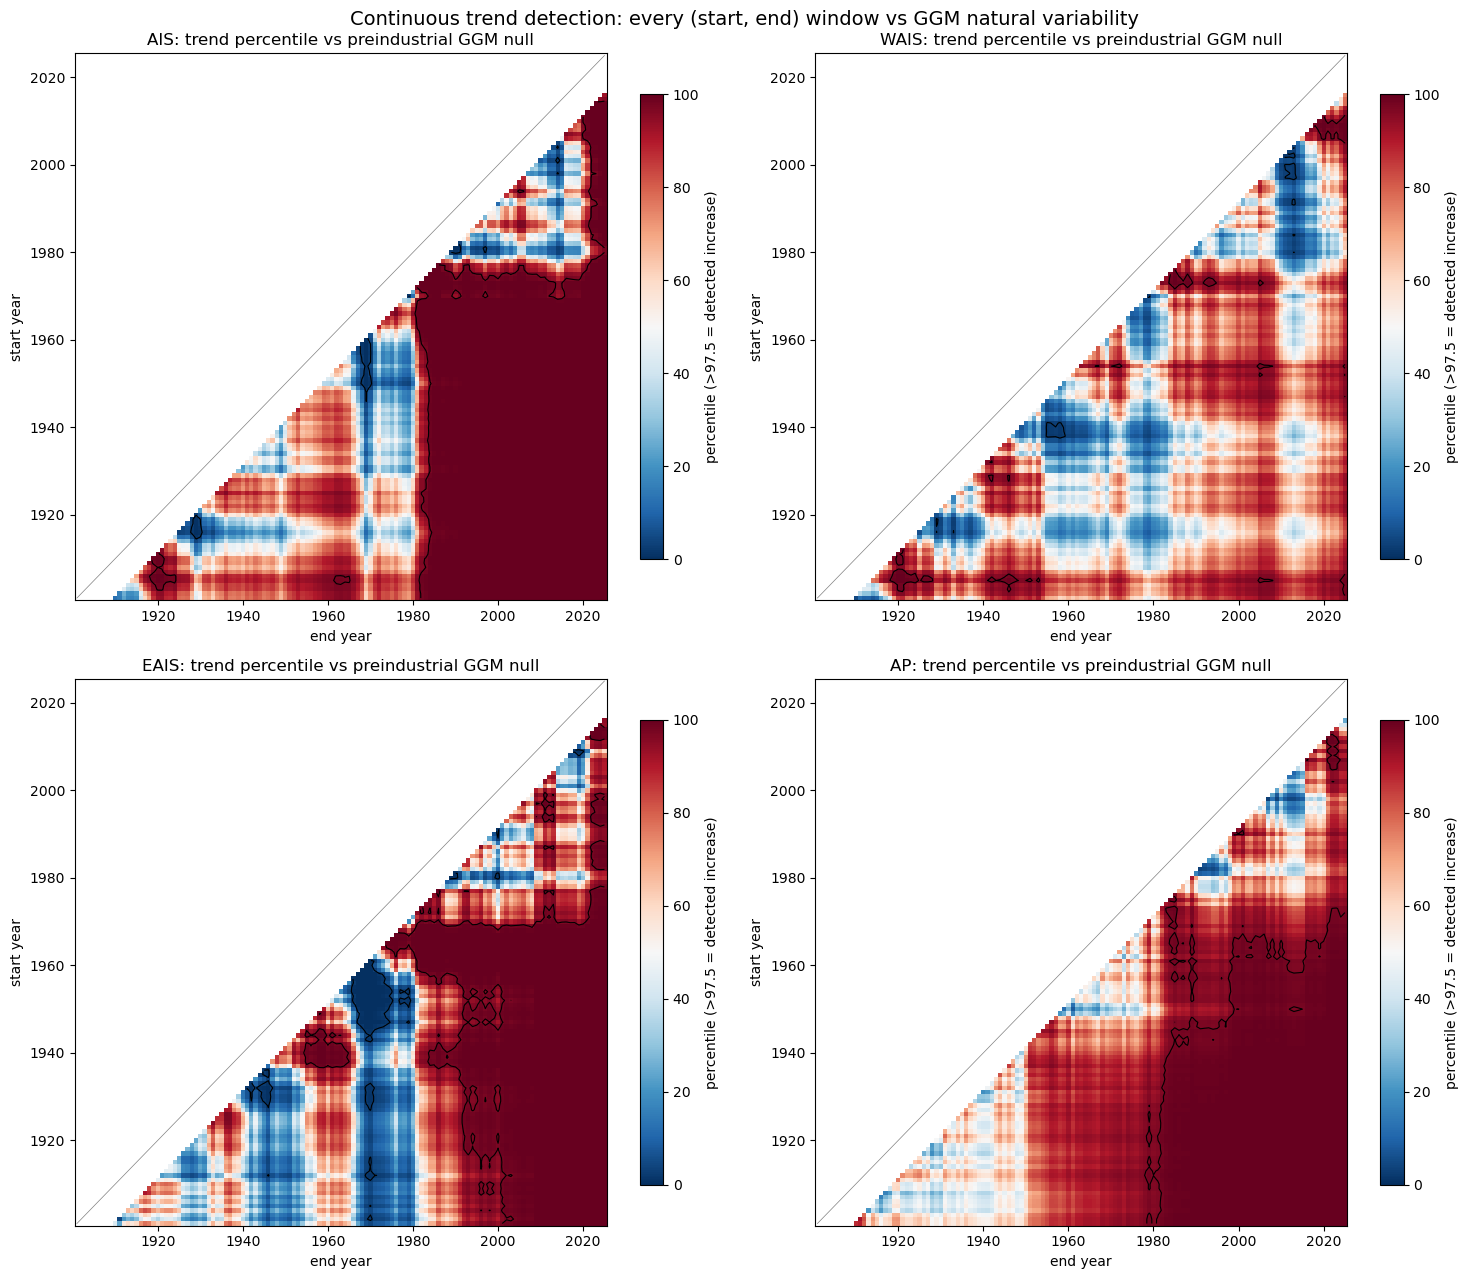

In [163]:
# --- Continuous trend-detection triangle: percentile vs GGM null for ALL (start,end) ---
# Replaces discrete windows. Null = region GGM fit on 1801-1900 (ggm_fits, Cell B).
from scipy.stats import norm

def ggm_trend_sd(fit, W):
    r = _ggm_acf(fit["kappa"], fit["phi"], W) * fit["sigma_w"]**2
    C = _toeplitz(r); t = np.arange(W, dtype=float); t -= t.mean()
    return np.sqrt(t @ C @ t) / (t @ t)

raw_obs = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
regions = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon,
           "EAIS": eais_rac_recon, "AP": ap_rac_recon}

yrs = np.arange(1901, 2026)                                   # epochs to scan
WMIN = 10                                                     # ignore ultra-short trends
def region_ext(r):                                           # extended series 1901-2025
    return np.concatenate([np.asarray(regions[r])[100:178],  # 1901-1978 recon
                           raw_obs[r].loc[1979:2025].values])# 1979-2025 raw

# precompute sigma_trend(W) per region
sd_of = {r: {W: ggm_trend_sd(ggm_fits[r], W) for W in range(WMIN, len(yrs) + 1)}
         for r in regions}

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
for ax, r in zip(axes.ravel(), regions):
    s = region_ext(r)
    P = np.full((len(yrs), len(yrs)), np.nan)                # [start, end]
    for i in range(len(yrs)):
        for j in range(i + WMIN - 1, len(yrs)):
            W = j - i + 1
            t = np.arange(W, dtype=float); t -= t.mean()
            slope = t @ s[i:j+1] / (t @ t)
            P[i, j] = 100 * norm.cdf(slope / sd_of[r][W])
    im = ax.pcolormesh(yrs, yrs, P, cmap="RdBu_r", vmin=0, vmax=100, shading="nearest")
    ax.contour(yrs, yrs, P, levels=[2.5, 97.5], colors="k", linewidths=0.8)
    ax.set_title(f"{r}: trend percentile vs preindustrial GGM null")
    ax.set_xlabel("end year"); ax.set_ylabel("start year")
    ax.plot(yrs, yrs, color="gray", lw=0.5)                  # W=1 diagonal
    fig.colorbar(im, ax=ax, shrink=0.85).set_label("percentile (>97.5 = detected increase)")
fig.suptitle("Continuous trend detection: every (start, end) window vs GGM natural variability",
             fontsize=14)
fig.tight_layout(); plt.show()


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


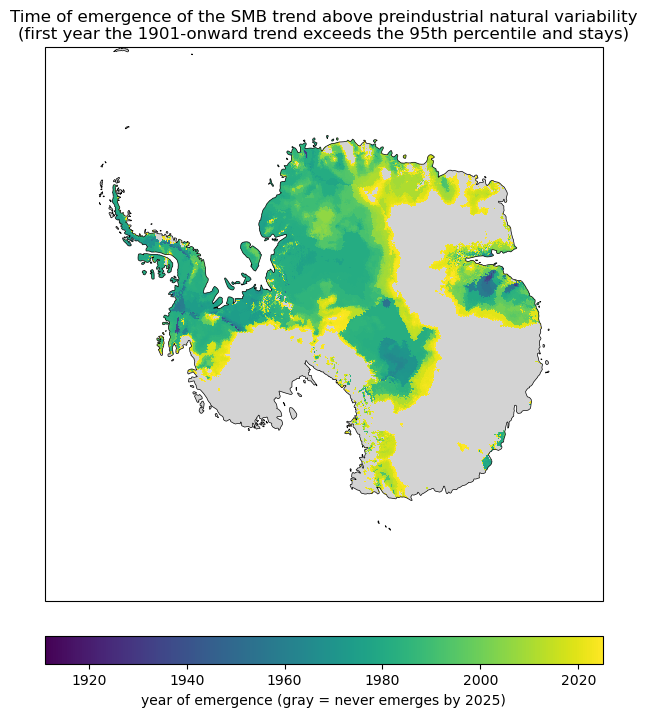

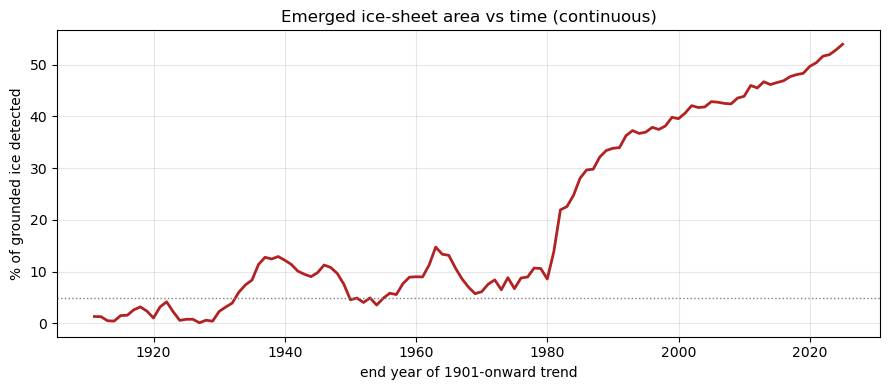

In [164]:
# --- Time of Emergence: first year the trend-since-1901 exceeds the 95th %ile and stays ---
# Continuous replacement for the multi-window panels. Anchored trend 1901->e, e swept yearly.
ext_cube = np.concatenate([racmo_smb_recon[:178],
                           smb_ann.sel(year=slice(1979, 2025)).values], axis=0)   # (225,NY,NX)
years_ext = np.concatenate([recon_years[:178], np.arange(1979, 2026)])
cell_std  = np.nanstd(racmo_smb_recon[:100], axis=0, ddof=1)                       # (NY,NX)

E = np.arange(1911, 2026)                                     # end years (>=10-yr window)
det_stack = np.zeros((len(E), NY, NX), bool)
for n, e in enumerate(E):
    m = (years_ext >= 1901) & (years_ext <= e)
    W = int(m.sum())
    t = np.arange(W, dtype=float); t -= t.mean(); tt = t @ t
    slope = np.tensordot(t, ext_cube[m], axes=(0, 0)) / tt    # (NY,NX)
    shape_map = np.full((NY, NX), np.nan)
    for bid in basin_ids_unique:
        f = basin_fit[bid]; rW = _ggm_acf(f["kappa"], f["phi"], W); C = _toeplitz(rW)
        shape_map[basin_mask == bid] = np.sqrt(t @ C @ t) / tt / np.sqrt(rW[0])
    sigma_trend = cell_std * shape_map
    ok = ice_sheet & np.isfinite(slope) & np.isfinite(sigma_trend) & (sigma_trend > 0)
    pct = np.where(ok, 100 * norm.cdf(np.where(ok, slope, 0) / np.where(ok, sigma_trend, 1)), np.nan)
    det_stack[n] = ok & (pct >= 95)

# persistent emergence: first e that is detected AND stays detected through 2025
persist = np.logical_and.accumulate(det_stack[::-1], axis=0)[::-1]
idx = np.argmax(persist, axis=0)
toe = np.where(persist.any(axis=0), E[idx], np.nan)
toe[~ice_sheet] = np.nan

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
im = ax.pcolormesh(lon_racmo, lat_racmo, toe, transform=ccrs.PlateCarree(),
                   cmap="viridis", vmin=E[0], vmax=E[-1], zorder=1)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
ax.set_title("Time of emergence of the SMB trend above preindustrial natural variability\n"
             "(first year the 1901-onward trend exceeds the 95th percentile and stays)")
cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cb.set_label("year of emergence (gray = never emerges by 2025)")

# companion: continuous emerged-area fraction vs end year
frac = 100 * det_stack[:, ice_sheet].mean(axis=1)
fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.plot(E, frac, color="firebrick", lw=2)
ax2.axhline(5, color="gray", ls=":", lw=1)                   # 5% = chance level
ax2.set_xlabel("end year of 1901-onward trend"); ax2.set_ylabel("% of grounded ice detected")
ax2.set_title("Emerged ice-sheet area vs time (continuous)"); ax2.grid(alpha=0.3)
fig2.tight_layout(); plt.show()


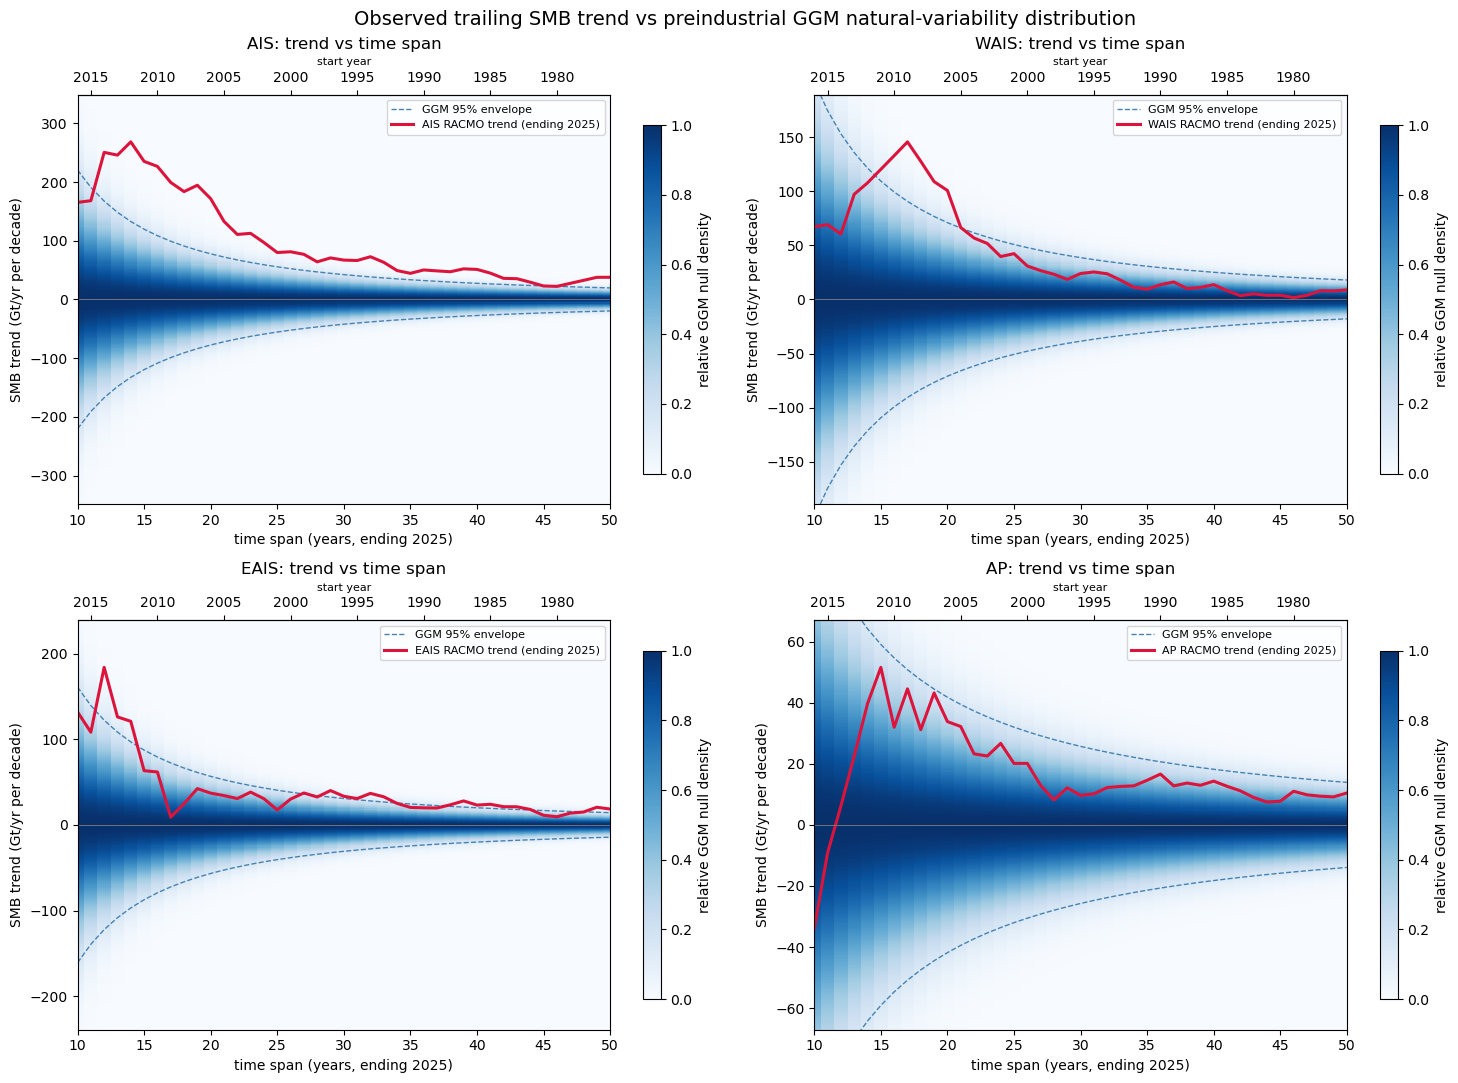

In [169]:
# --- Trend magnitude vs time span: GGM null probability density + observed RACMO trend ---
# For span W: window = [2026-W, 2025]. Null = region GGM fit on 1801-1900 (ggm_fits, Cell B).
from scipy.stats import norm

def ggm_trend_sd(fit, W):
    r = _ggm_acf(fit["kappa"], fit["phi"], W) * fit["sigma_w"]**2
    C = _toeplitz(r); t = np.arange(W, dtype=float); t -= t.mean()
    return np.sqrt(t @ C @ t) / (t @ t)

raw_obs = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
regions = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon,
           "EAIS": eais_rac_recon, "AP": ap_rac_recon}
def region_ext(r):                                           # extended series 1901-2025
    return np.concatenate([np.asarray(regions[r])[100:178],  # 1901-1978 recon
                           raw_obs[r].loc[1979:2025].values])# 1979-2025 raw

spans = np.arange(10, 51)                                     # 5 .. 50 yr

def trail_slope(s, W):                                       # trend of last W yrs, per year
    y = s[-W:]; t = np.arange(W, dtype=float); t -= t.mean()
    return t @ y / (t @ t)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, r in zip(axes.ravel(), regions):
    s = region_ext(r)
    obs   = np.array([trail_slope(s, W) for W in spans]) * 10        # Gt/yr per decade
    sd    = np.array([ggm_trend_sd(ggm_fits[r], W) for W in spans]) * 10

    # y-range: cover the observed line and the null band at longer (>=30 yr) spans
    ymax = 1.3 * max(np.nanmax(np.abs(obs)),
                     np.nanmax(1.96 * sd[spans >= 30]))
    tg = np.linspace(-ymax, ymax, 400)

    # GGM null density P(trend | span), normalised per column so the shape is visible
    Z = norm.pdf(tg[:, None], 0.0, sd[None, :])
    Z /= Z.max(axis=0, keepdims=True)

    pcm = ax.pcolormesh(spans, tg, Z, cmap="Blues", shading="nearest", zorder=0)
    ax.plot(spans, 1.96 * sd, "--", color="steelblue", lw=1, label="GGM 95% envelope")
    ax.plot(spans, -1.96 * sd, "--", color="steelblue", lw=1)
    ax.plot(spans, obs, color="crimson", lw=2.2, label=f"{r} RACMO trend (ending 2025)")
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_xlim(spans[0], spans[-1]); ax.set_ylim(-ymax, ymax)
    ax.set_title(f"{r}: trend vs time span")
    ax.set_xlabel("time span (years, ending 2025)")
    ax.set_ylabel("SMB trend (Gt/yr per decade)")
    ax.legend(fontsize=8, loc="upper right")
    fig.colorbar(pcm, ax=ax, shrink=0.85).set_label("relative GGM null density")

# secondary top axis: span -> start year
for ax in axes.ravel():
    sax = ax.secondary_xaxis("top", functions=(lambda w: 2026 - w, lambda y: 2026 - y))
    sax.set_xlabel("start year", fontsize=8)

fig.suptitle("Observed trailing SMB trend vs preindustrial GGM natural-variability distribution",
             fontsize=14)
fig.tight_layout(); plt.show()


Region  SLM 2025 (mm)   %ile  emergence yr
AIS             24.25  100.0          1998
WAIS             7.63   95.9          None
EAIS            12.63  100.0          2004
AP               3.99   78.7          1903


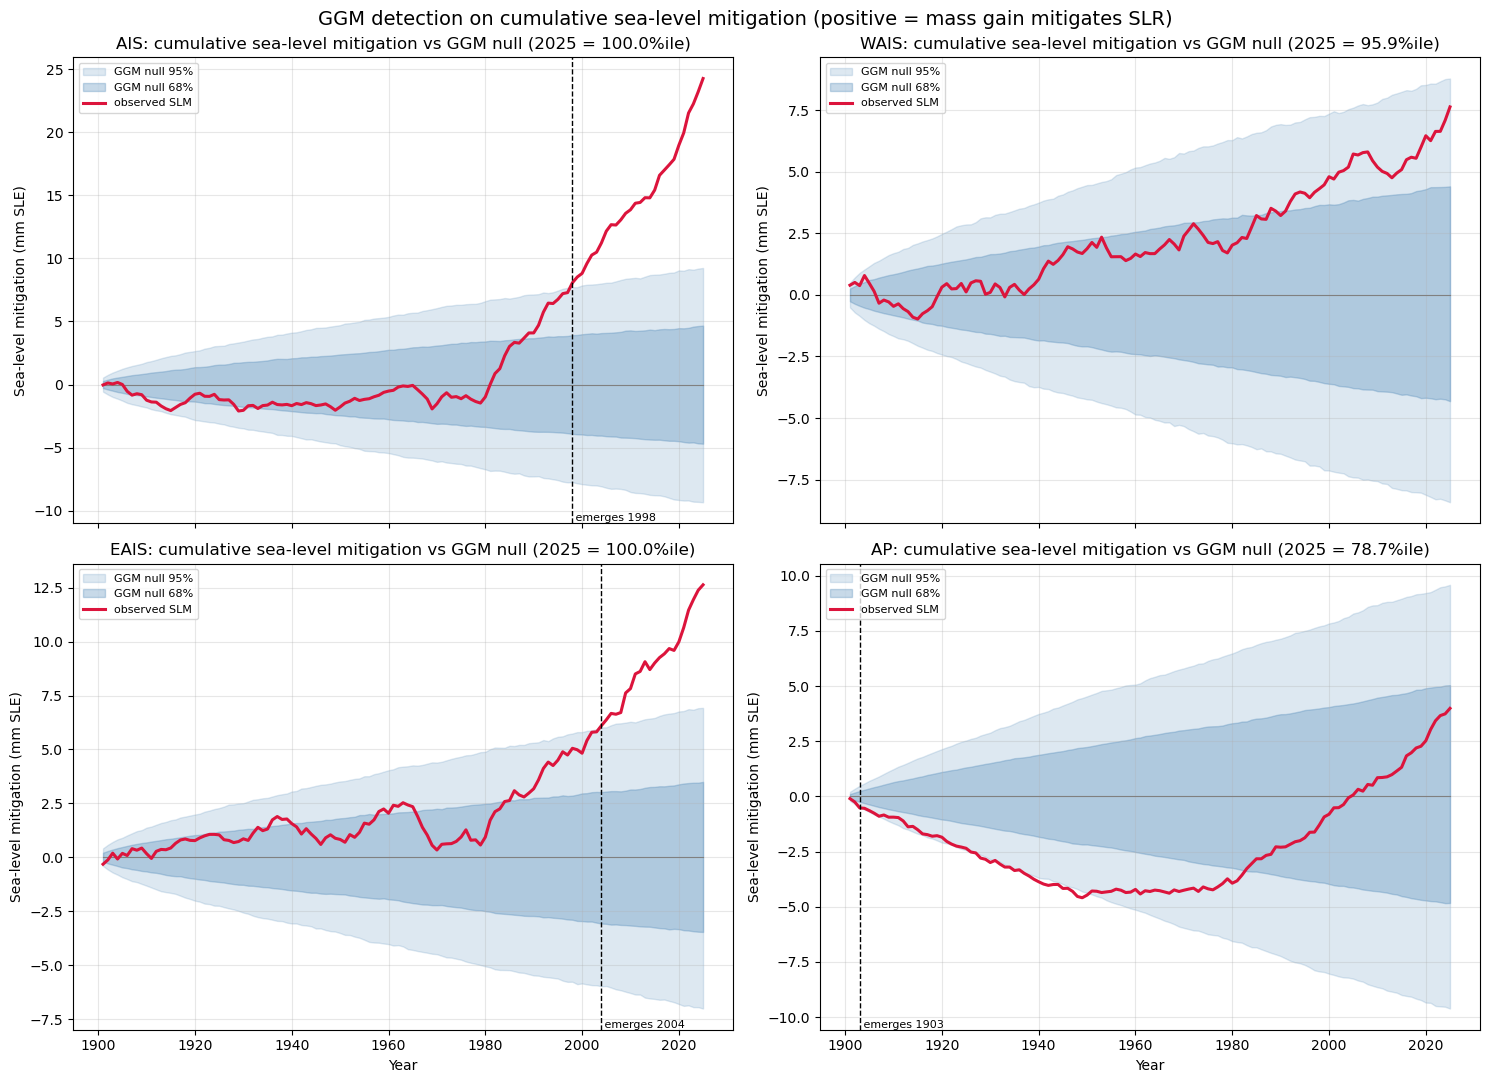

In [170]:
# --- GGM detection applied to cumulative sea-level mitigation (spatially integrated SMB) ---
# Null: annual SMB = GGM noise (fit 1801-1900). SLM = cumsum(SMB - own baseline mean)/361.8.
# Each simulated realisation anomalises vs its OWN 1801-1900 mean (baseline uncertainty in).
GT_PER_MM = 361.8
N, T = 5000, 225                                             # sims, full span 1801-2025
rng = np.random.default_rng(0)

raw_obs = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
regions = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon,
           "EAIS": eais_rac_recon, "AP": ap_rac_recon}
years = np.arange(1901, 2026)                               # accumulation epoch

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
print(f"{'Region':6s} {'SLM 2025 (mm)':>14s} {'%ile':>6s} {'emergence yr':>13s}")
for ax, r in zip(axes.ravel(), regions):
    f = ggm_fits[r]

    # --- null trajectories: simulate 1801-2025, subtract own 1801-1900 mean, accumulate ---
    rac = _ggm_acf(f["kappa"], f["phi"], T) * f["sigma_w"]**2
    L = np.linalg.cholesky(_toeplitz(rac))
    Z = L @ rng.standard_normal((T, N))                     # (225, N) GGM realisations
    Z -= Z[:100].mean(axis=0, keepdims=True)                # own-baseline anomaly
    slm_null = np.cumsum(Z[100:], axis=0) / GT_PER_MM       # (125, N) mm SLE from 1901

    # --- observed SLM trajectory (extended series, own 1801-1900 baseline) ---
    s_ext = np.concatenate([np.asarray(regions[r])[:178],       # 1801-1978 recon
                            raw_obs[r].loc[1979:2025].values])  # 1979-2025 raw
    base = s_ext[:100].mean()
    slm_obs = np.cumsum(s_ext[100:] - base) / GT_PER_MM     # (125,) mm SLE from 1901

    lo95, hi95 = np.percentile(slm_null, [2.5, 97.5], axis=1)
    lo68, hi68 = np.percentile(slm_null, [16, 84], axis=1)
    pct = 100 * (slm_null < slm_obs[:, None]).mean(axis=1)  # per-year percentile
    outside = (slm_obs > hi95) | (slm_obs < lo95)
    toe = int(years[outside.argmax()]) if outside.any() else None

    ax.fill_between(years, lo95, hi95, color="steelblue", alpha=0.18, label="GGM null 95%")
    ax.fill_between(years, lo68, hi68, color="steelblue", alpha=0.30, label="GGM null 68%")
    ax.plot(years, np.zeros_like(years, float), color="gray", lw=0.8)
    ax.plot(years, slm_obs, color="crimson", lw=2.2, label="observed SLM")
    if toe is not None:
        ax.axvline(toe, color="k", ls="--", lw=1)
        ax.text(toe, ax.get_ylim()[0], f" emerges {toe}", fontsize=8, va="bottom")
    ax.set_title(f"{r}: cumulative sea-level mitigation vs GGM null "
                 f"(2025 = {pct[-1]:.1f}%ile)")
    ax.set_ylabel("Sea-level mitigation (mm SLE)"); ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
    print(f"{r:6s} {slm_obs[-1]:14.2f} {pct[-1]:6.1f} {str(toe):>13s}")
for ax in axes[-1, :]:
    ax.set_xlabel("Year")
fig.suptitle("GGM detection on cumulative sea-level mitigation (positive = mass gain mitigates SLR)",
             fontsize=14)
fig.tight_layout(); plt.show()


Region   rho  SLM 2025 (mm)   %ile  emergence yr
AIS     0.18          24.25  100.0          2002
WAIS    0.11           7.63   94.0          None
EAIS    0.26          12.63   99.7          2011
AP      0.43           3.99   91.5          1903


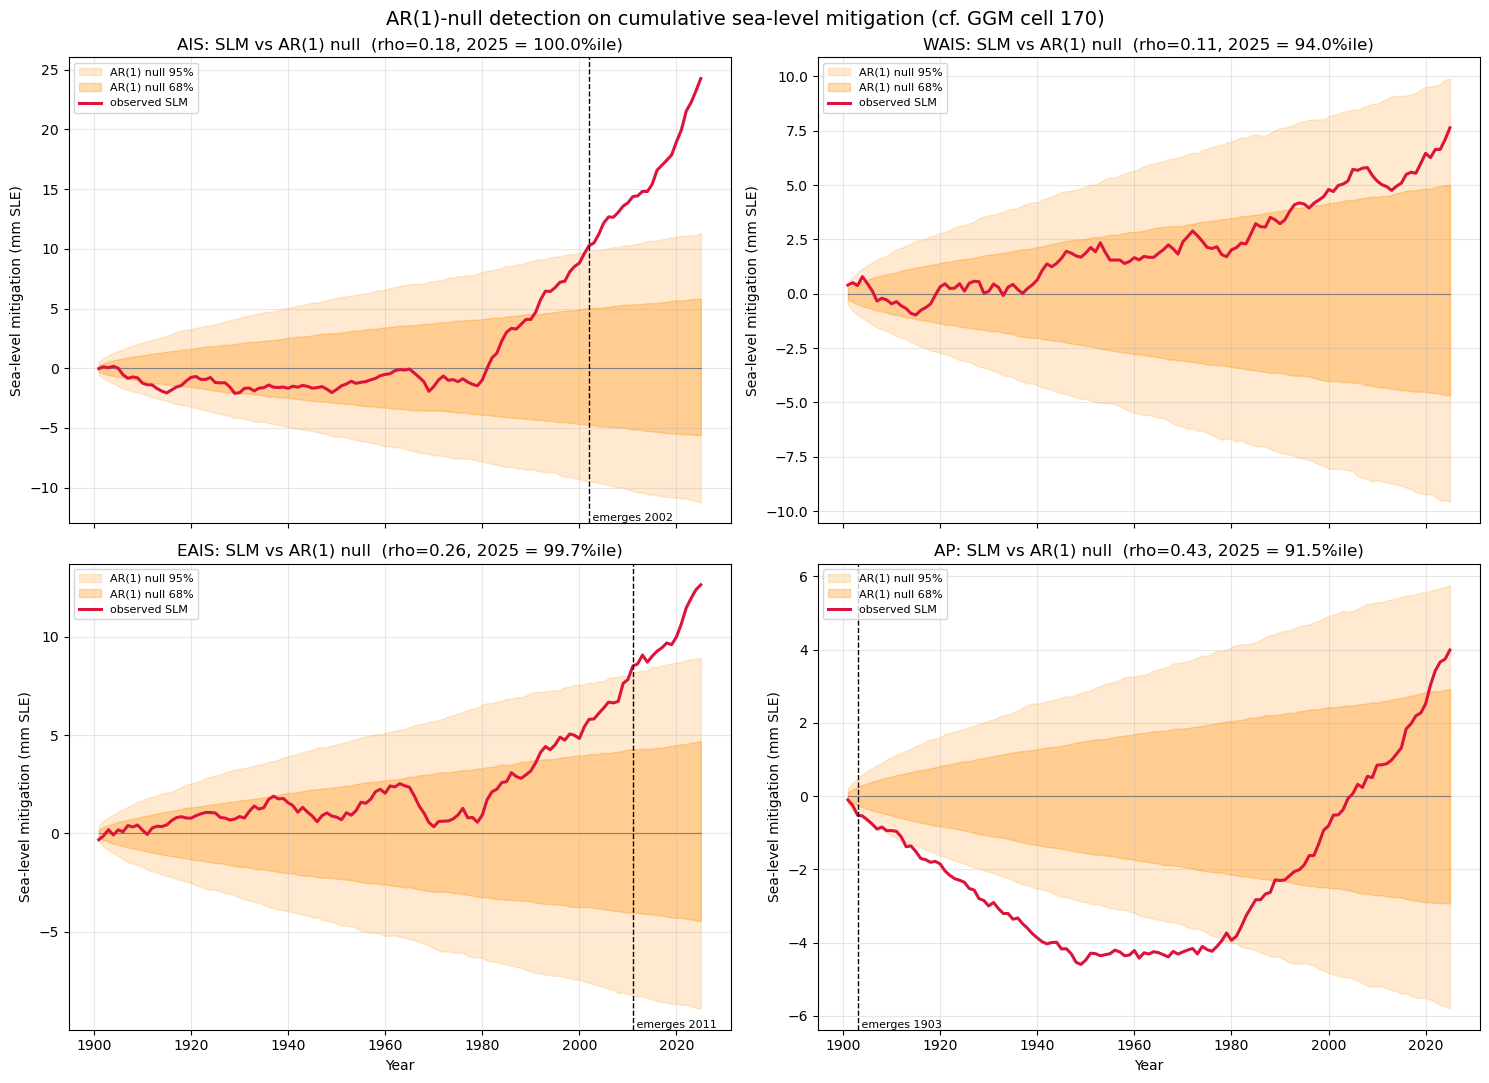

In [179]:
# --- AR(1) version of the SLM detection cell (compare against cell 170's GGM null) ---
GT_PER_MM, NB = 361.8, 100
N, T = 5000, 225
rng = np.random.default_rng(0)

raw_obs = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
regions = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon,
           "EAIS": eais_rac_recon, "AP": ap_rac_recon}
years = np.arange(1901, 2026)

def ar1_paths(fit, T, N, rng, burn=200):
    e = fit["sigma"] * rng.standard_normal((T + burn, N)); y = np.empty_like(e)
    y[0] = e[0]
    for i in range(1, T + burn): y[i] = fit["rho"] * y[i-1] + e[i]
    return y[burn:]                                        # (T, N) stationary AR(1)

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
print(f"{'Region':6s} {'rho':>5s} {'SLM 2025 (mm)':>14s} {'%ile':>6s} {'emergence yr':>13s}")
for ax, r in zip(axes.ravel(), regions):
    f = ar1_fits[r]
    Z = ar1_paths(f, T, N, rng)
    Z -= Z[:NB].mean(axis=0, keepdims=True)               # own-baseline anomaly
    slm_null = np.cumsum(Z[NB:], axis=0) / GT_PER_MM       # (125, N)

    s_ext = np.concatenate([np.asarray(regions[r])[:178],
                            raw_obs[r].loc[1979:2025].values])
    slm_obs = np.cumsum(s_ext[NB:] - s_ext[:NB].mean()) / GT_PER_MM

    lo95, hi95 = np.percentile(slm_null, [2.5, 97.5], axis=1)
    lo68, hi68 = np.percentile(slm_null, [16, 84], axis=1)
    pct = 100 * (slm_null < slm_obs[:, None]).mean(axis=1)
    outside = (slm_obs > hi95) | (slm_obs < lo95)
    toe = int(years[outside.argmax()]) if outside.any() else None

    ax.fill_between(years, lo95, hi95, color="darkorange", alpha=0.18, label="AR(1) null 95%")
    ax.fill_between(years, lo68, hi68, color="darkorange", alpha=0.30, label="AR(1) null 68%")
    ax.plot(years, np.zeros_like(years, float), color="gray", lw=0.8)
    ax.plot(years, slm_obs, color="crimson", lw=2.2, label="observed SLM")
    if toe is not None:
        ax.axvline(toe, color="k", ls="--", lw=1)
        ax.text(toe, ax.get_ylim()[0], f" emerges {toe}", fontsize=8, va="bottom")
    ax.set_title(f"{r}: SLM vs AR(1) null  (rho={f['rho']:.2f}, 2025 = {pct[-1]:.1f}%ile)")
    ax.set_ylabel("Sea-level mitigation (mm SLE)"); ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")
    print(f"{r:6s} {f['rho']:5.2f} {slm_obs[-1]:14.2f} {pct[-1]:6.1f} {str(toe):>13s}")
for ax in axes[-1, :]:
    ax.set_xlabel("Year")
fig.suptitle("AR(1)-null detection on cumulative sea-level mitigation (cf. GGM cell 170)", fontsize=14)
fig.tight_layout(); plt.show()


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


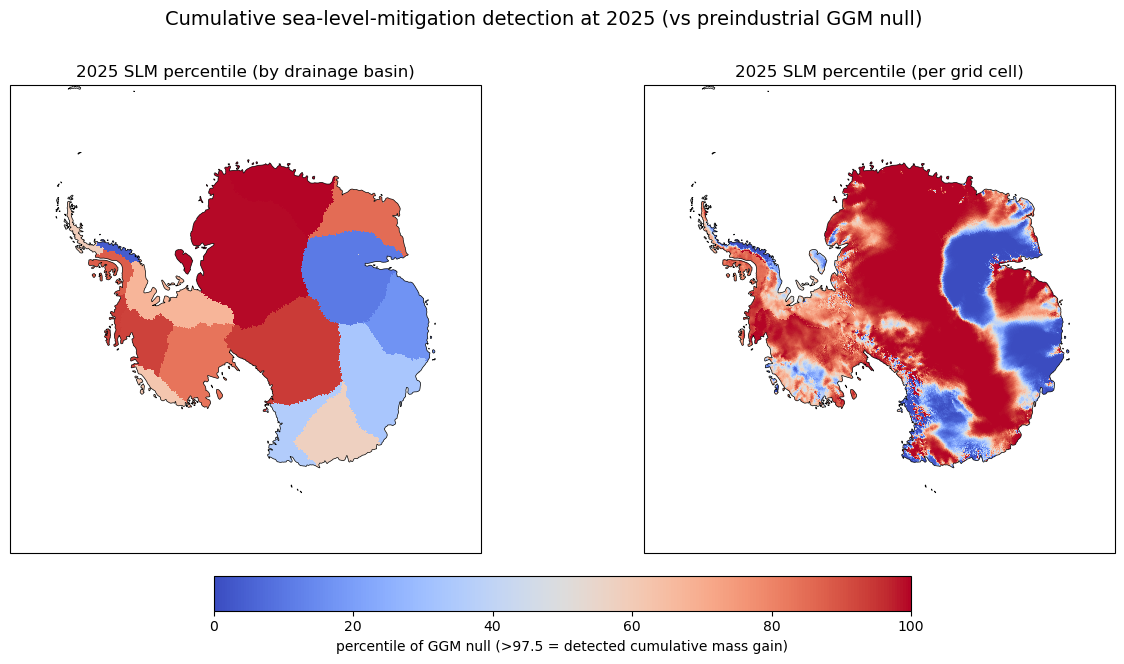

In [175]:
# --- 2025 cumulative SLM detection percentile: per basin (left) and per grid cell (right) ---
# Cumulative anomaly (1901->2025) vs preindustrial mean is Gaussian under the GGM null:
#   percentile = Phi(cumulative_anomaly / sigma_cumulative).   Needs basin_fit (Cell E).
from scipy.stats import norm
NB, NA = 100, 125                                          # baseline yrs (1801-1900), accumulation yrs (1901-2025)

def cum_unit_var(fit):
    """Variance (unit sigma_w) & lag-0 acf of the cumulative-anomaly functional."""
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB + NA))
    a = np.concatenate([np.full(NB, -NA / NB), np.ones(NA)])   # subtract baseline mean, accumulate
    return a @ R @ a, R[0, 0]

# ---------- per-basin percentile (exact) ----------
basin_pct = {}
cum_shape = {}                                            # for the cell map: sigma_cum = cell_std * shape
for bid in basin_ids_unique:
    f = basin_fit[bid]
    vu, r0 = cum_unit_var(f)
    sigma_cum = f["sigma_w"] * np.sqrt(vu)
    cum_shape[bid] = np.sqrt(vu / r0)
    s_ext = np.concatenate([smb_basin_recon[bid].values[:178],
                            smb_basin_obs[bid].loc[1979:2025].values])   # 1801-2025 basin total
    S = s_ext[NB:].sum() - NA * s_ext[:NB].mean()          # cumulative anomaly 1901->2025 (Gt)
    basin_pct[bid] = 100 * norm.cdf(S / sigma_cum)

def paint(d):
    g = np.full(basin_mask.shape, np.nan)
    for bid, v in d.items():
        g[basin_mask == bid] = v
    return g

# ---------- per-cell percentile (basin colour x cell amplitude) ----------
ext_cube = np.concatenate([racmo_smb_recon[:178],
                           smb_ann.sel(year=slice(1979, 2025)).values], axis=0)   # (225,NY,NX)
years_ext = np.concatenate([recon_years[:178], np.arange(1979, 2026)])
acc = years_ext >= 1901                                    # 1901-2025 (125 yr)

base_cell = racmo_smb_recon[:NB].mean(axis=0)              # 1801-1900 cell mean
S_cell    = ext_cube[acc].sum(axis=0) - NA * base_cell     # cumulative anomaly per cell
cell_std  = np.nanstd(racmo_smb_recon[:NB], axis=0, ddof=1)

shape_map = np.full((NY, NX), np.nan)
for bid in basin_ids_unique:
    shape_map[basin_mask == bid] = cum_shape[bid]
sigma_cum_cell = cell_std * shape_map
pct_cell = np.full((NY, NX), np.nan)
ok = ice_sheet & np.isfinite(S_cell) & np.isfinite(sigma_cum_cell) & (sigma_cum_cell > 0)
pct_cell[ok] = 100 * norm.cdf(S_cell[ok] / sigma_cum_cell[ok])

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, fld, title in [(axes[0], paint(basin_pct), "by drainage basin"),
                       (axes[1], pct_cell,          "per grid cell")]:
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, fld, transform=ccrs.PlateCarree(),
                       cmap="coolwarm", vmin=0, vmax=100, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(f"2025 SLM percentile ({title})", fontsize=12)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.6)
cb.set_label("percentile of GGM null (>97.5 = detected cumulative mass gain)")
fig.suptitle("Cumulative sea-level-mitigation detection at 2025 (vs preindustrial GGM null)",
             fontsize=14)
plt.show()


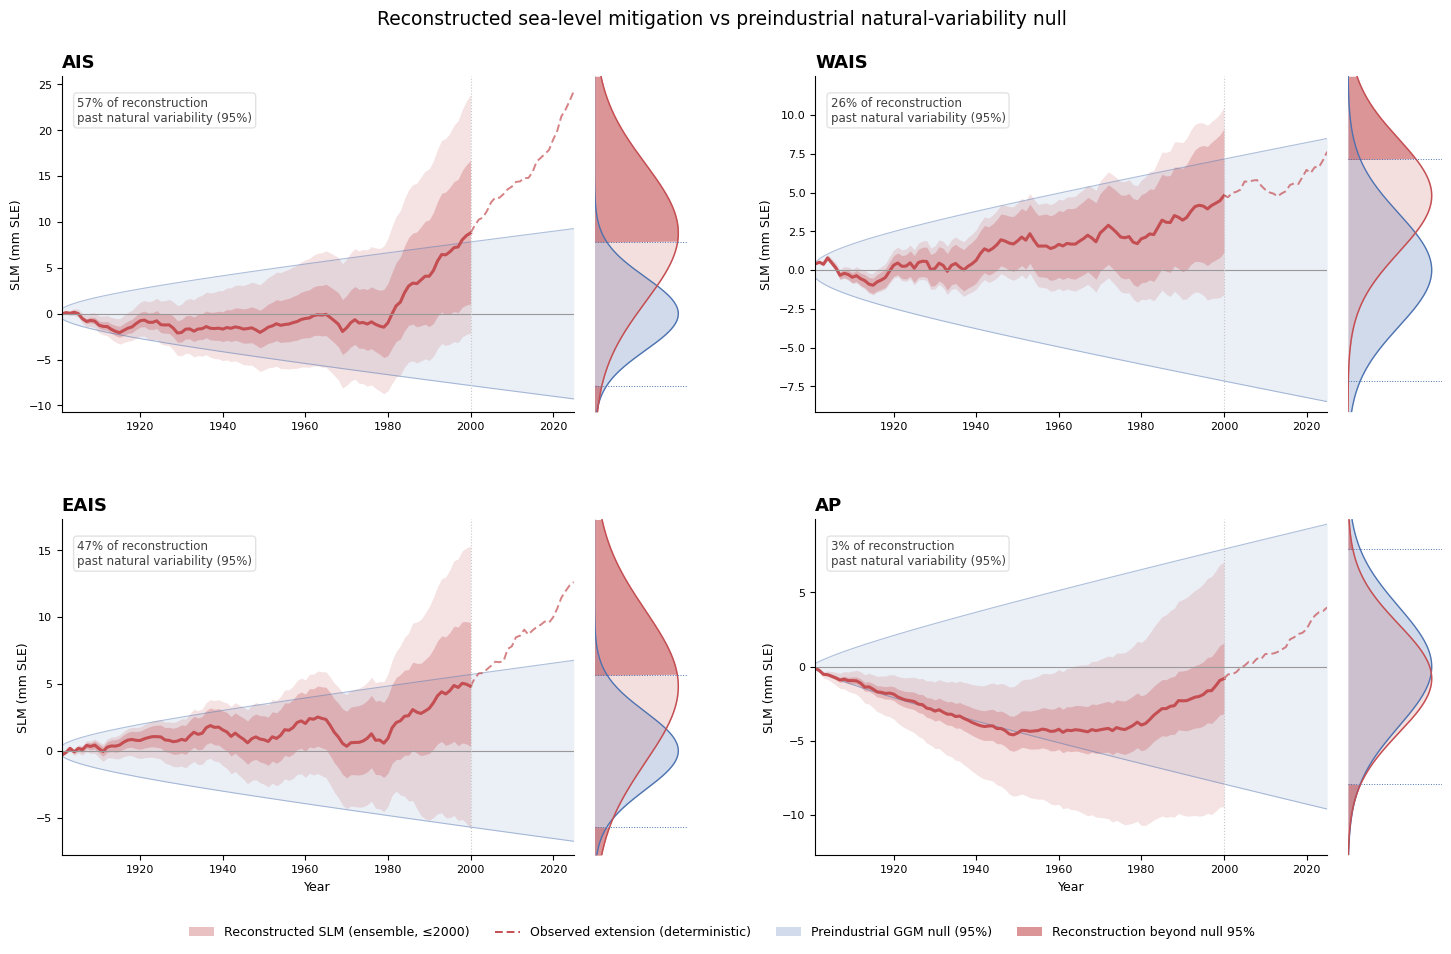

In [197]:
# --- Reconstructed SLM vs GGM null; annotate % of reconstruction beyond natural variability ---
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm

GT, NB, NA = 361.8, 100, 125
years = np.arange(1901, 2026); i2000 = int(np.where(years == 2000)[0][0])
region_names = ["AIS", "WAIS", "EAIS", "AP"]
raw_obs = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
M = smb_reg_ens.shape[1]
NULL_C, REC_C, Z95 = "#4C72B0", "#C44E52", 1.96

def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB + NA) * fit["sigma_w"]**2)
    sig = np.empty(NA)
    for n in range(1, NA + 1):
        a = np.concatenate([np.full(NB, -n / NB), np.ones(n)])
        sig[n - 1] = np.sqrt(a @ R[:NB + n, :NB + n] @ a) / GT
    return sig

fig = plt.figure(figsize=(15, 9.5))
gs = GridSpec(2, 5, width_ratios=[6, 1.1, 1.0, 6, 1.1], wspace=0.08, hspace=0.32, figure=fig)
cells = [(0, 0), (0, 3), (1, 0), (1, 3)]

for (rr, cc), k in zip(cells, range(4)):
    r = region_names[k]
    ax  = fig.add_subplot(gs[rr, cc])
    axm = fig.add_subplot(gs[rr, cc + 1], sharey=ax)

    sig = slm_sigma(ggm_fits[r])
    obs_tail = raw_obs[r].loc[1979:2025].values
    slm_mem = np.empty((M, NA))
    for m in range(M):
        mem = np.concatenate([smb_reg_ens[:178, m, k], obs_tail])
        slm_mem[m] = np.cumsum(mem[NB:] - mem[:NB].mean()) / GT
    mmean = slm_mem.mean(0)
    yr_r = years[:i2000 + 1]
    lo95, hi95 = np.percentile(slm_mem[:, :i2000 + 1], [2.5, 97.5], axis=0)
    lo68, hi68 = np.percentile(slm_mem[:, :i2000 + 1], [16, 84], axis=0)

    ax.fill_between(years, -Z95 * sig, Z95 * sig, color=NULL_C, alpha=0.11, lw=0)
    ax.plot(years,  Z95 * sig, color=NULL_C, lw=0.8, alpha=0.45)
    ax.plot(years, -Z95 * sig, color=NULL_C, lw=0.8, alpha=0.45)
    ax.fill_between(yr_r, lo95, hi95, color=REC_C, alpha=0.16, lw=0)
    ax.fill_between(yr_r, lo68, hi68, color=REC_C, alpha=0.28, lw=0)
    ax.plot(yr_r, mmean[:i2000 + 1], color=REC_C, lw=2.2)
    ax.plot(years[i2000:], mmean[i2000:], color=REC_C, lw=1.4, ls=(0, (4, 2)), alpha=0.7)
    ax.axhline(0, color="0.6", lw=0.8); ax.axvline(2000, color="0.78", lw=0.8, ls=":")

    # marginal at 2000: reconstruction as N(mean,std); shade the part beyond the null's 95% bounds
    v = slm_mem[:, i2000]; s = sig[i2000]; mu, sr = v.mean(), v.std(ddof=1)
    ylo = min(lo95.min(), -Z95 * s) - 2; yhi = max(hi95.max(), Z95 * s) + 2
    yy = np.linspace(ylo, yhi, 400)
    npdf = norm.pdf(yy, 0, s); npdf /= npdf.max()
    rpdf = norm.pdf(yy, mu, sr); rpdf /= rpdf.max()
    axm.fill_betweenx(yy, 0, npdf, color=NULL_C, alpha=0.26, lw=0); axm.plot(npdf, yy, color=NULL_C, lw=1.0)
    outside = np.abs(yy) > Z95 * s
    axm.fill_betweenx(yy, 0, np.where(~outside, rpdf, 0), color=REC_C, alpha=0.18, lw=0)   # within null
    axm.fill_betweenx(yy, 0, np.where(outside,  rpdf, 0), color=REC_C, alpha=0.60, lw=0)   # extends past null
    axm.plot(rpdf, yy, color=REC_C, lw=1.1)
    for yb in (Z95 * s, -Z95 * s):
        axm.axhline(yb, color=NULL_C, lw=0.7, ls=":")

    # metric: probability mass of the reconstruction beyond the null's 95% range (two-sided)
    p_beyond = 100 * (norm.sf((Z95 * s - mu) / sr) + norm.cdf((-Z95 * s - mu) / sr))

    ax.set_title(r, fontsize=13, fontweight="bold", loc="left")
    ax.text(0.03, 0.94, f"{p_beyond:.0f}% of reconstruction\npast natural variability (95%)",
            transform=ax.transAxes, fontsize=8.5, va="top", color="0.25",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.85", alpha=0.75))
    ax.set_xlim(1901, 2025); ax.set_ylim(ylo, yhi)
    ax.set_ylabel("SLM (mm SLE)", fontsize=9)
    if rr == 1: ax.set_xlabel("Year", fontsize=9)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=8); axm.set_xlim(0, 1.12); axm.axis("off")

handles = [Patch(facecolor=REC_C, alpha=0.35, label="Reconstructed SLM (ensemble, ≤2000)"),
           Line2D([0], [0], color=REC_C, lw=1.4, ls=(0, (4, 2)), label="Observed extension (deterministic)"),
           Patch(facecolor=NULL_C, alpha=0.25, label="Preindustrial GGM null (95%)"),
           Patch(facecolor=REC_C, alpha=0.60, label="Reconstruction beyond null 95%")]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Reconstructed sea-level mitigation vs preindustrial natural-variability null", fontsize=13.5, y=0.98)
fig.subplots_adjust(top=0.91, bottom=0.09, left=0.06, right=0.98)
plt.show()


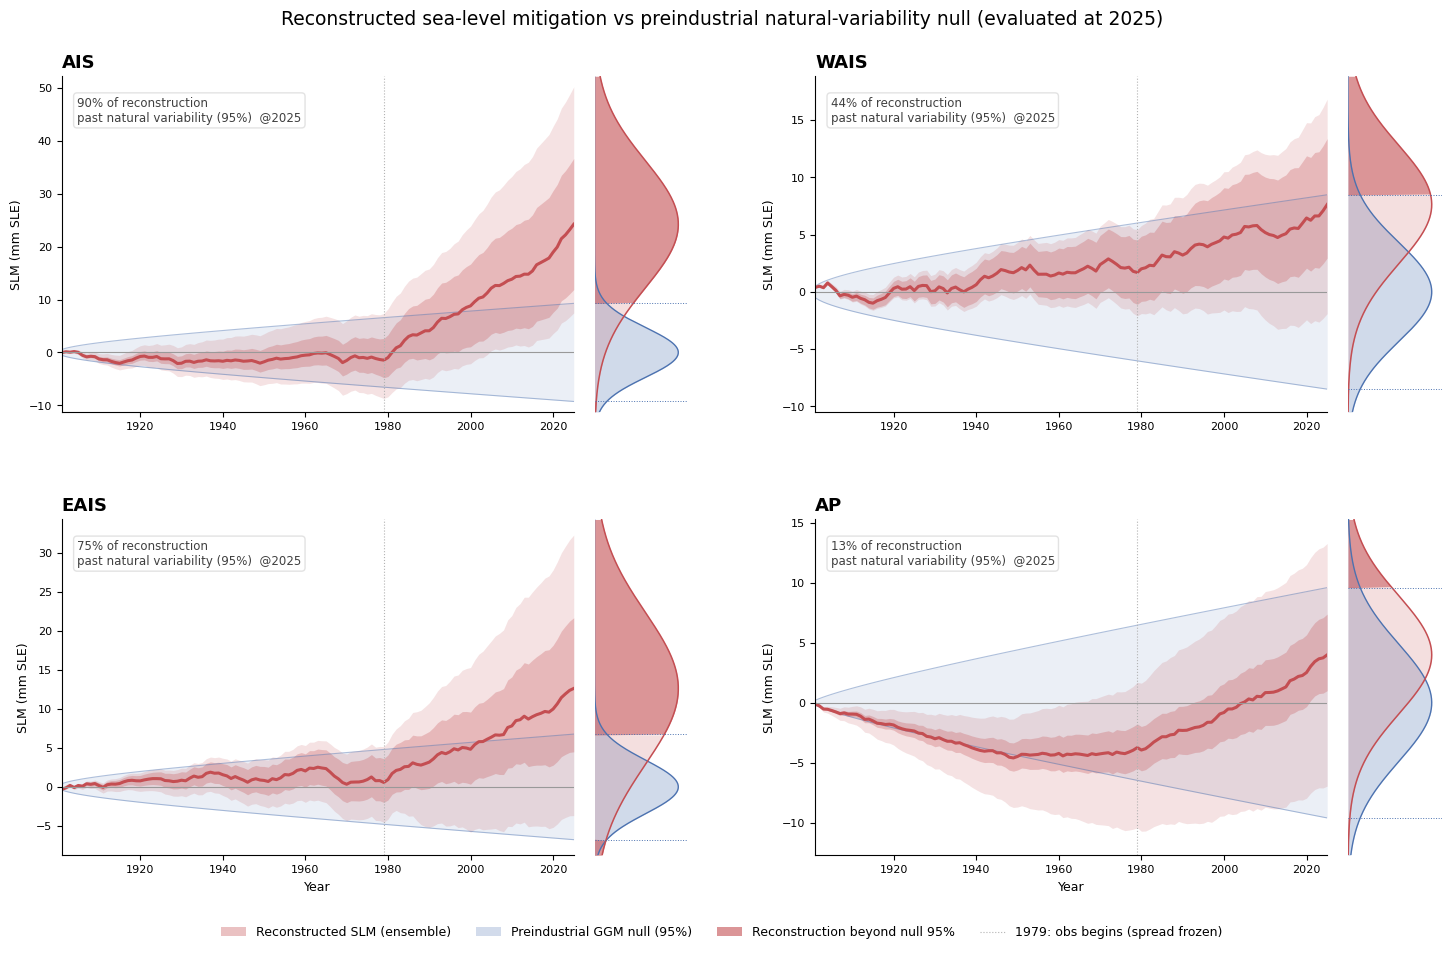

In [198]:
# --- Reconstructed SLM vs GGM null; distribution comparison at 2025 ---
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm

GT, NB, NA = 361.8, 100, 125
years = np.arange(1901, 2026); iEval = NA - 1          # <-- 2025 (was i2000)
region_names = ["AIS", "WAIS", "EAIS", "AP"]
raw_obs = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
M = smb_reg_ens.shape[1]
NULL_C, REC_C, Z95 = "#4C72B0", "#C44E52", 1.96

def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB + NA) * fit["sigma_w"]**2)
    sig = np.empty(NA)
    for n in range(1, NA + 1):
        a = np.concatenate([np.full(NB, -n / NB), np.ones(n)])
        sig[n - 1] = np.sqrt(a @ R[:NB + n, :NB + n] @ a) / GT
    return sig

fig = plt.figure(figsize=(15, 9.5))
gs = GridSpec(2, 5, width_ratios=[6, 1.1, 1.0, 6, 1.1], wspace=0.08, hspace=0.32, figure=fig)
cells = [(0, 0), (0, 3), (1, 0), (1, 3)]

for (rr, cc), k in zip(cells, range(4)):
    r = region_names[k]
    ax  = fig.add_subplot(gs[rr, cc])
    axm = fig.add_subplot(gs[rr, cc + 1], sharey=ax)

    sig = slm_sigma(ggm_fits[r])
    obs_tail = raw_obs[r].loc[1979:2025].values
    slm_mem = np.empty((M, NA))
    for m in range(M):
        mem = np.concatenate([smb_reg_ens[:178, m, k], obs_tail])
        slm_mem[m] = np.cumsum(mem[NB:] - mem[:NB].mean()) / GT
    mmean = slm_mem.mean(0)
    lo95, hi95 = np.percentile(slm_mem, [2.5, 97.5], axis=0)     # full span 1901-2025
    lo68, hi68 = np.percentile(slm_mem, [16, 84], axis=0)

    ax.fill_between(years, -Z95 * sig, Z95 * sig, color=NULL_C, alpha=0.11, lw=0)
    ax.plot(years,  Z95 * sig, color=NULL_C, lw=0.8, alpha=0.45)
    ax.plot(years, -Z95 * sig, color=NULL_C, lw=0.8, alpha=0.45)
    ax.fill_between(years, lo95, hi95, color=REC_C, alpha=0.16, lw=0)
    ax.fill_between(years, lo68, hi68, color=REC_C, alpha=0.28, lw=0)
    ax.plot(years, mmean, color=REC_C, lw=2.2)
    ax.axhline(0, color="0.6", lw=0.8)
    ax.axvline(1979, color="0.7", lw=0.8, ls=":")               # spread frozen after (obs begins)

    # marginal at 2025: reconstruction as N(mean,std); shade mass beyond null's 95% bounds
    v = slm_mem[:, iEval]; s = sig[iEval]; mu, sr = v.mean(), v.std(ddof=1)
    ylo = min(lo95.min(), -Z95 * s) - 2; yhi = max(hi95.max(), Z95 * s) + 2
    yy = np.linspace(ylo, yhi, 400)
    npdf = norm.pdf(yy, 0, s); npdf /= npdf.max()
    rpdf = norm.pdf(yy, mu, sr); rpdf /= rpdf.max()
    axm.fill_betweenx(yy, 0, npdf, color=NULL_C, alpha=0.26, lw=0); axm.plot(npdf, yy, color=NULL_C, lw=1.0)
    outside = np.abs(yy) > Z95 * s
    axm.fill_betweenx(yy, 0, np.where(~outside, rpdf, 0), color=REC_C, alpha=0.18, lw=0)
    axm.fill_betweenx(yy, 0, np.where(outside,  rpdf, 0), color=REC_C, alpha=0.60, lw=0)
    axm.plot(rpdf, yy, color=REC_C, lw=1.1)
    for yb in (Z95 * s, -Z95 * s):
        axm.axhline(yb, color=NULL_C, lw=0.7, ls=":")

    p_beyond = 100 * (norm.sf((Z95 * s - mu) / sr) + norm.cdf((-Z95 * s - mu) / sr))
    ax.set_title(r, fontsize=13, fontweight="bold", loc="left")
    ax.text(0.03, 0.94, f"{p_beyond:.0f}% of reconstruction\npast natural variability (95%)  @2025",
            transform=ax.transAxes, fontsize=8.5, va="top", color="0.25",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.85", alpha=0.75))
    ax.set_xlim(1901, 2025); ax.set_ylim(ylo, yhi)
    ax.set_ylabel("SLM (mm SLE)", fontsize=9)
    if rr == 1: ax.set_xlabel("Year", fontsize=9)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=8); axm.set_xlim(0, 1.12); axm.axis("off")

handles = [Patch(facecolor=REC_C, alpha=0.35, label="Reconstructed SLM (ensemble)"),
           Patch(facecolor=NULL_C, alpha=0.25, label="Preindustrial GGM null (95%)"),
           Patch(facecolor=REC_C, alpha=0.60, label="Reconstruction beyond null 95%"),
           Line2D([0], [0], color="0.7", lw=0.8, ls=":", label="1979: obs begins (spread frozen)")]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Reconstructed sea-level mitigation vs preindustrial natural-variability null (evaluated at 2025)",
             fontsize=13.5, y=0.98)
fig.subplots_adjust(top=0.91, bottom=0.09, left=0.06, right=0.98)
plt.show()


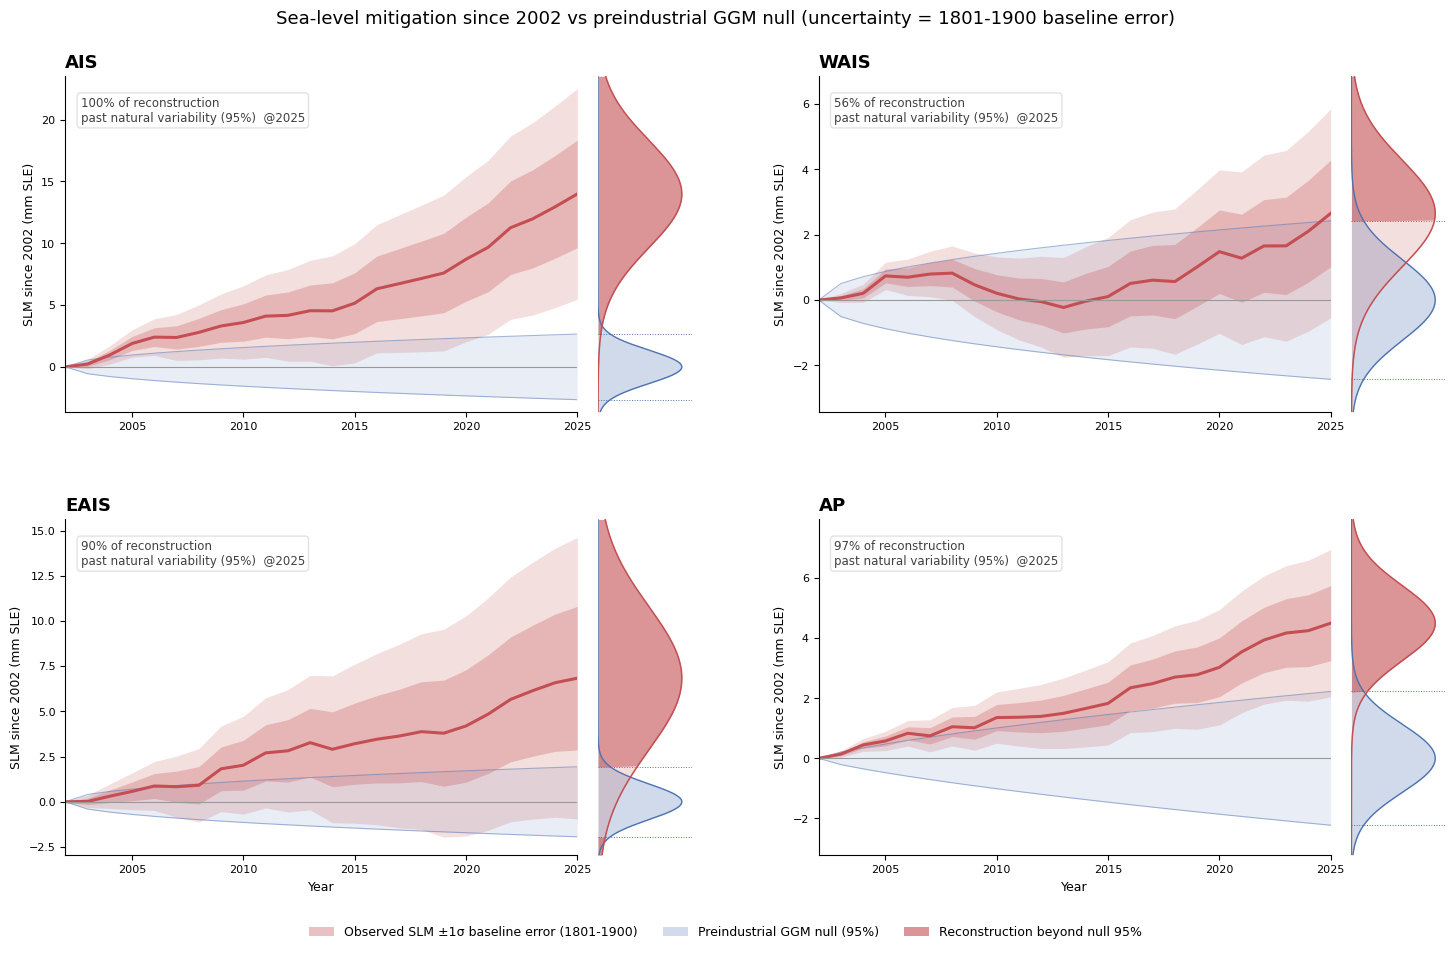

In [199]:
# --- SLM 2002-2025 vs GGM null; reconstruction uncertainty = 1801-1900 baseline error (cf. cell 70) ---
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.stats import norm

GT = 361.8
yrs = np.arange(2002, 2026); n_acc = (yrs - 2002).astype(float)          # 0..23
region_names = ["AIS", "WAIS", "EAIS", "AP"]
recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
raw_series   = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
NULL_C, REC_C, Z95 = "#4C72B0", "#C44E52", 1.96

def combined_smb(r):
    rec = pd.Series(recon_series[r], index=recon_years)
    return pd.concat([rec.loc[:1978], raw_series[r].loc[1979:]])
def baseline_sigma(k):                             # 1σ of reconstructed 1801-1900 mean (Gt/yr)
    idx = [y - 1801 for y in range(1801, 1901)]
    return smb_reg_ens[idx, :, k].mean(axis=0).std(ddof=1)
def cumsum_sigma(fit, W):                          # GGM natural-variability σ of a W-year cumulative sum (mm)
    if W == 0: return 0.0
    C = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], W) * fit["sigma_w"]**2)
    o = np.ones(W); return np.sqrt(o @ C @ o) / GT

fig = plt.figure(figsize=(15, 9.5))
gs = GridSpec(2, 5, width_ratios=[6, 1.1, 1.0, 6, 1.1], wspace=0.08, hspace=0.32, figure=fig)
cells = [(0, 0), (0, 3), (1, 0), (1, 3)]

for (rr, cc), k in zip(cells, range(4)):
    r = region_names[k]
    ax  = fig.add_subplot(gs[rr, cc]); axm = fig.add_subplot(gs[rr, cc + 1], sharey=ax)

    comb = combined_smb(r); base = comb.loc[1801:1900].mean()
    cum = (comb - base).reindex(yrs).cumsum(); c = (cum - cum.loc[2002]).values       # Gt, zeroed 2002
    slm_rec = c / GT                                                                   # mm mitigation
    sig_base = baseline_sigma(k)
    sig_rec  = n_acc * sig_base / GT                                                   # baseline error 1σ (linear)
    sig_null = np.array([cumsum_sigma(ggm_fits[r], int(W)) for W in n_acc])            # GGM null 1σ

    ax.fill_between(yrs, -Z95 * sig_null, Z95 * sig_null, color=NULL_C, alpha=0.12, lw=0)
    ax.plot(yrs,  Z95 * sig_null, color=NULL_C, lw=0.8, alpha=0.5)
    ax.plot(yrs, -Z95 * sig_null, color=NULL_C, lw=0.8, alpha=0.5)
    ax.fill_between(yrs, slm_rec - Z95 * sig_rec, slm_rec + Z95 * sig_rec, color=REC_C, alpha=0.18, lw=0)
    ax.fill_between(yrs, slm_rec - sig_rec, slm_rec + sig_rec, color=REC_C, alpha=0.28, lw=0)
    ax.plot(yrs, slm_rec, color=REC_C, lw=2.2); ax.axhline(0, color="0.6", lw=0.8)

    mu, sr, s = slm_rec[-1], sig_rec[-1], sig_null[-1]
    ylo = min((slm_rec - Z95*sig_rec).min(), -Z95*s) - 1; yhi = max((slm_rec + Z95*sig_rec).max(), Z95*s) + 1
    yy = np.linspace(ylo, yhi, 400)
    npdf = norm.pdf(yy, 0, s); npdf /= npdf.max()
    rpdf = norm.pdf(yy, mu, max(sr, 1e-9)); rpdf /= rpdf.max()
    axm.fill_betweenx(yy, 0, npdf, color=NULL_C, alpha=0.26, lw=0); axm.plot(npdf, yy, color=NULL_C, lw=1.0)
    outside = np.abs(yy) > Z95 * s
    axm.fill_betweenx(yy, 0, np.where(~outside, rpdf, 0), color=REC_C, alpha=0.18, lw=0)
    axm.fill_betweenx(yy, 0, np.where(outside,  rpdf, 0), color=REC_C, alpha=0.60, lw=0)
    axm.plot(rpdf, yy, color=REC_C, lw=1.1)
    for yb in (Z95*s, -Z95*s): axm.axhline(yb, color=NULL_C, lw=0.7, ls=":")

    p_beyond = 100 * (norm.sf((Z95*s - mu)/max(sr,1e-9)) + norm.cdf((-Z95*s - mu)/max(sr,1e-9)))
    ax.set_title(r, fontsize=13, fontweight="bold", loc="left")
    ax.text(0.03, 0.94, f"{p_beyond:.0f}% of reconstruction\npast natural variability (95%)  @2025",
            transform=ax.transAxes, fontsize=8.5, va="top", color="0.25",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.85", alpha=0.75))
    ax.set_xlim(2002, 2025); ax.set_ylim(ylo, yhi)
    ax.set_ylabel("SLM since 2002 (mm SLE)", fontsize=9)
    if rr == 1: ax.set_xlabel("Year", fontsize=9)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=8); axm.set_xlim(0, 1.12); axm.axis("off")

handles = [Patch(facecolor=REC_C, alpha=0.35, label="Observed SLM ±1σ baseline error (1801-1900)"),
           Patch(facecolor=NULL_C, alpha=0.25, label="Preindustrial GGM null (95%)"),
           Patch(facecolor=REC_C, alpha=0.60, label="Reconstruction beyond null 95%")]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Sea-level mitigation since 2002 vs preindustrial GGM null (uncertainty = 1801-1900 baseline error)",
             fontsize=13, y=0.98)
fig.subplots_adjust(top=0.91, bottom=0.09, left=0.06, right=0.98)
plt.show()
